# AdaptiveMath-AI — Final Evaluation artifacts and figures

**Notebook 06 of 06**

This notebook consolidates saved outputs from the preceding notebooks without retraining core models. It separates nested validation evidence from secondary temporal and cold-start diagnostics and produces the final scientific tables and figures.

## 1. Reproducible plotting environment

The plotting contract uses Times New Roman, readable 18–20 pt text and 350-DPI saved figures.

In [1]:
from pathlib import Path
import json, math, os, random, shutil, textwrap, time, warnings, hashlib, platform
from importlib.metadata import version, PackageNotFoundError
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from IPython.display import display, Image, Markdown
from scipy.special import logit, expit
from scipy.stats import norm, binomtest
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss, confusion_matrix
import joblib
mpl.rcParams.update({"font.family":"Times New Roman","font.size":18,"axes.titlesize":20,"axes.labelsize":19,"xtick.labelsize":18,"ytick.labelsize":18,"legend.fontsize":18,"figure.titlesize":20,"axes.spines.top":False,"axes.spines.right":False,"savefig.dpi":350,"figure.dpi":350})
PALETTE={"blue":"#2F6B8F","orange":"#C77C2B","green":"#4F7F3A","purple":"#6D5A8D","red":"#B45A55","gray":"#6E7378","light_gray":"#E7EAED","teal":"#4A8C8A","gold":"#C9A227","black":"#222222","white":"#FFFFFF"}
SEED=20260713; rng=np.random.default_rng(SEED)
cwd=Path.cwd().resolve(); ROOT=next((p for p in [cwd,*cwd.parents] if (p/"notebooks").is_dir() and (p/"README.md").exists()),None)
if ROOT is None: raise FileNotFoundError("Run from the repository root or the notebooks directory.")
TABLES=ROOT/"artifacts"; FIGURES=ROOT/"figures"
def save_and_show_figure(fig,filename):
    path=FIGURES/filename; fig.savefig(path,dpi=350,bbox_inches="tight",facecolor="white"); plt.show(); print(f"Saved figure: {path}"); return path
def annotate_bars(ax,fmt="{:.3f}",horizontal=True):
    for patch in ax.patches:
        if horizontal: ax.text(patch.get_x()+patch.get_width(),patch.get_y()+patch.get_height()/2," "+fmt.format(patch.get_width()),va="center",ha="left",fontsize=18,clip_on=False)
        else: ax.text(patch.get_x()+patch.get_width()/2,patch.get_y()+patch.get_height(),fmt.format(patch.get_height()),va="bottom",ha="center",fontsize=18,clip_on=False)
def wrap_labels(labels,width=24): return ["\n".join(textwrap.wrap(str(x).replace("_"," "),width)) for x in labels]
def plot_horizontal_metric_ranking(frame,label_col,metric_col,color=PALETTE["blue"],title=None,xlabel=None):
    d=frame.sort_values(metric_col); y=np.arange(len(d)); fig,ax=plt.subplots(figsize=(14,max(7,.82*len(d)))); ax.hlines(y,.5,d[metric_col],color=PALETTE["light_gray"],linewidth=3); ax.scatter(d[metric_col],y,s=150,color=color,edgecolor=PALETTE["black"],zorder=3); ax.axvline(.5,color=PALETTE["gray"],linestyle="--",linewidth=2); ax.set_yticks(y,wrap_labels(d[label_col],24));
    for yi,value in zip(y,d[metric_col]): ax.text(value+.004,yi,f"{value:.3f}",va="center",fontsize=18)
    ax.set_title(title or metric_col,pad=14); ax.set_xlabel((xlabel or metric_col)+" (focused dot-plot scale)"); ax.set_xlim(.48,min(.86,d[metric_col].max()+.055)); ax.grid(axis="x",color=PALETTE["light_gray"]); fig.text(.5,.02,"Dashed vertical line = chance ROC-AUC (0.50).",ha="center",fontsize=18); fig.subplots_adjust(left=.32,bottom=.14); return fig,ax
def place_legend_below(ax,ncol=3): ax.legend(loc="upper center",bbox_to_anchor=(.5,-.18),ncol=ncol,frameon=False)
def heatmap_annotated(matrix,row_labels,col_labels,title,cbar_label,fmt=".3f",cmap="viridis",figsize=(12,8)):
    arr=np.asarray(matrix,dtype=float); fig,ax=plt.subplots(figsize=figsize); im=ax.imshow(arr,aspect="auto",cmap=cmap); ax.set_xticks(range(len(col_labels)),wrap_labels(col_labels,18)); ax.set_yticks(range(len(row_labels)),wrap_labels(row_labels,24)); plt.setp(ax.get_xticklabels(),rotation=35,ha="right")
    threshold=(np.nanmin(arr)+np.nanmax(arr))/2 if np.isfinite(arr).any() else 0
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            v=arr[i,j]; ax.text(j,i,format(v,fmt) if np.isfinite(v) else "NA",ha="center",va="center",color="white" if v>threshold else "black",fontsize=18)
    cb=fig.colorbar(im,ax=ax); cb.set_label(cbar_label,fontsize=19); cb.ax.tick_params(labelsize=18); ax.set_title(title); return fig,ax
def dataframe_to_markdown(frame):
    clean=frame.map(lambda x:str(x).replace('|','\\|').replace('\n',' ')); headers=[str(c) for c in clean.columns]; lines=['| '+' | '.join(headers)+' |','| '+' | '.join(['---']*len(headers))+' |']
    lines += ['| '+' | '.join(row)+' |' for row in clean.to_numpy().tolist()]; return '\n'.join(lines)
print(f"Project root: {ROOT}"); print(f"Scientific typography: Times New Roman, 18–20 pt, 350 dpi; seed={SEED}")

Project root: <repository_root>
Scientific typography: Times New Roman, 18–20 pt, 350 dpi; seed=20260713


## Consolidated final comparison tables

All non-ablation models are retained only in **descriptive development rankings**. The primary comparison is the nested, equal-label-budget AdaptiveMath-AI versus HGB100 validation analysis from Notebook 05. Neural proxy rankings cannot support claims against canonical paper implementations. Temporal and external tables are secondary and non-confirmatory.

In [2]:
simple_models=["Majority Class","Global Correctness Mean","Student Historical Mean","Question Historical Mean","Student-Question Backoff Mean","Subject Historical Mean"]
psych_models=["Rasch-style logit baseline","2PL-inspired smoothed baseline","Elo Rating","Fixed-parameter BKT proxy","PFA-style logistic baseline","AFM-style logistic baseline","Exposure-SVD collaborative proxy"]
classical_models=["Logistic Regression","Naive Bayes","Decision Tree","Random Forest","Extra Trees","HistGradientBoosting","MLPClassifier"]
kt_models=["DKT-inspired GRU proxy","Static key-value attention proxy","SAKT-inspired attention proxy","Time-aware SAKT proxy","Subject-time SAKT proxy","Compact Transformer KT proxy","Subject-graph embedding proxy"]
deep_models=["Gated MLP proxy","Compact numeric-token Transformer proxy","Compact entity-token Transformer proxy","Deeper entity-token Transformer proxy","Residual MLP"]
collab_models=["Neural MF proxy","DeepFM-style proxy","Student-question embedding MLP"]
def family(name):
    if name=="AdaptiveMath-AI": return "Proposed"
    if name in simple_models: return "Simple"
    if name in psych_models: return "Psychometric"
    if name in classical_models: return "Classical ML"
    if name in kt_models: return "Knowledge Tracing"
    if name in deep_models: return "Deep Tabular"
    if name in collab_models: return "Collaborative Deep"
    return "Other"
def combined_metrics(suffix):
    frames=[]
    for prefix in ["baseline","sota","proposed_model"]:
        path=TABLES/f"{prefix}_{suffix}_metrics.csv"
        if path.exists(): frames.append(pd.read_csv(path))
    d=pd.concat(frames,ignore_index=True); d["Family"]=d.Model.map(family); return d.sort_values(["ROC_AUC","Log_Loss"],ascending=[False,True]).reset_index(drop=True)
final_validation=combined_metrics("validation"); final_test=combined_metrics("test"); final_student=combined_metrics("external_unseen_student"); final_question=combined_metrics("external_unseen_question")
primary_cols=["Model","Family","N","Accuracy","Balanced_Accuracy","Macro_F1","Weighted_F1","ROC_AUC","PR_AUC","MCC","Kappa","Log_Loss","Brier_Score","ECE","FPR","FNR"]
cal_cols=["Model","Family","N","Log_Loss","Brier_Score","ECE","MCE","Calibration_Slope","Calibration_Intercept"]
final_validation[primary_cols].to_csv(TABLES/"final_validation_primary_metrics.csv",index=False); final_validation[cal_cols].to_csv(TABLES/"final_validation_calibration_metrics.csv",index=False)
final_test[primary_cols].to_csv(TABLES/"final_temporal_test_primary_metrics.csv",index=False); final_test[cal_cols].to_csv(TABLES/"final_temporal_test_calibration_metrics.csv",index=False)
final_student[primary_cols].to_csv(TABLES/"final_unseen_student_metrics.csv",index=False); final_question[primary_cols].to_csv(TABLES/"final_unseen_question_metrics.csv",index=False)
# Protocol and data-quality handoff tables.
protocol=pd.read_csv(TABLES/"split_protocol_summary.csv"); protocol.to_csv(TABLES/"final_dataset_protocol_summary.csv",index=False)
quality=pd.read_csv(TABLES/"dataset_quality_summary.csv"); quality.to_csv(TABLES/"final_data_quality_summary.csv",index=False)
splits=pd.read_csv(TABLES/"split_summary.csv"); splits.to_csv(TABLES/"final_split_summary.csv",index=False)
features=pd.read_csv(TABLES/"feature_group_summary.csv"); features.to_csv(TABLES/"final_feature_group_summary.csv",index=False)
# Short-history comparison.
short=[]
for prefix in ["baseline","sota","proposed_model"]:
    d=pd.read_csv(TABLES/f"{prefix}_short_history_metrics.csv"); d["Family"]=d.Model.map(family); short.append(d)
final_short=pd.concat(short,ignore_index=True).sort_values(["History_Cap","ROC_AUC"],ascending=[True,False]); final_short.to_csv(TABLES/"final_short_history_metrics.csv",index=False)
# Efficiency and complexity.
eff=[]
for path in [TABLES/"baseline_training_efficiency.csv",TABLES/"sota_training_efficiency.csv",TABLES/"latency_efficiency_summary.csv"]:
    d=pd.read_csv(path); d["Source_Artifact"]=path.name; eff.append(d)
final_eff=pd.concat(eff,ignore_index=True,sort=False); final_eff["Family"]=final_eff.Model.map(family); final_eff.to_csv(TABLES/"final_efficiency_metrics.csv",index=False)
sota_complex=pd.read_csv(TABLES/"sota_hyperparameter_summary.csv")[["Model","Family","Parameters","Sequence_Length","Training_Rows"]].copy(); prop_complex=pd.read_csv(TABLES/"model_complexity_summary.csv"); final_complex=pd.concat([sota_complex,prop_complex],ignore_index=True,sort=False); final_complex.to_csv(TABLES/"final_model_complexity_metrics.csv",index=False)
# Ablations are kept separate from the main ranking.
pd.read_csv(TABLES/"ablation_results_validation.csv").to_csv(TABLES/"final_ablation_validation_metrics.csv",index=False); pd.read_csv(TABLES/"ablation_results_test.csv").to_csv(TABLES/"final_ablation_test_metrics.csv",index=False)
# Validation-defined comparators.
best_simple=final_validation[final_validation.Family.eq("Simple")].iloc[0].Model; best_psych=final_validation[final_validation.Family.eq("Psychometric")].iloc[0].Model; best_classical=final_validation[final_validation.Family.eq("Classical ML")].iloc[0].Model; best_kt=final_validation[final_validation.Family.eq("Knowledge Tracing")].iloc[0].Model; best_deep=final_validation[final_validation.Family.eq("Deep Tabular")].iloc[0].Model
selected_models=["AdaptiveMath-AI",best_simple,best_psych,best_classical,best_kt,best_deep]
# Markdown tables: bold only AdaptiveMath-AI values supported later by statistical results; numerical best is marked with a dagger pending uncertainty.
def markdown_metric_table(d,title):
    z=d[d.Model.isin(selected_models)][["Model","ROC_AUC","Log_Loss","Brier_Score","ECE"]].copy();
    for col,higher in [("ROC_AUC",True),("Log_Loss",False),("Brier_Score",False),("ECE",False)]:
        best=z[col].max() if higher else z[col].min(); z[col]=z[col].map(lambda v:f"**{v:.4f}†**" if np.isclose(v,best) else f"{v:.4f}")
    return f"## {title}\n\n"+dataframe_to_markdown(z)+"\n\n† Numerical best; statistical uncertainty is reported separately.\n"
fair_primary=pd.read_csv(TABLES/"proposed_model_cluster_bootstrap.csv"); fair_primary["Evidence_Role"]=np.where(fair_primary.Split.eq("validation"),"Primary selection evidence","Secondary non-confirmatory diagnostic"); fair_primary.to_csv(TABLES/"final_primary_fair_comparison.csv",index=False)
comparison_md="# Primary equal-label-budget comparison\n\n"+dataframe_to_markdown(fair_primary[["Split","Comparator","Delta_ROC_AUC","AUC_CI_Lower","AUC_CI_Upper","Delta_Log_Loss","Evidence_Role"]].round(6))+"\n\n"+markdown_metric_table(final_validation,"Descriptive validation model ranking")+"\n"+markdown_metric_table(final_test,"Secondary descriptive temporal ranking")
snapshot=pd.concat([final_validation[final_validation.Model.eq("AdaptiveMath-AI")].assign(Evaluation="Validation"),final_test[final_test.Model.eq("AdaptiveMath-AI")].assign(Evaluation="Temporal test"),final_student[final_student.Model.eq("AdaptiveMath-AI")].assign(Evaluation="Unseen student"),final_question[final_question.Model.eq("AdaptiveMath-AI")].assign(Evaluation="Unseen question")],ignore_index=True)
snapshot.to_csv(TABLES/"final_result_snapshot.csv",index=False)
display(final_validation[final_validation.Model.isin(selected_models)][primary_cols]); display(final_test[final_test.Model.isin(selected_models)][primary_cols]); display(snapshot[["Evaluation","ROC_AUC","Log_Loss","Brier_Score","ECE"]]); display(Markdown(comparison_md[:2500]))
print("Saved consolidated validation, temporal-test, cold-start, short-history, efficiency, complexity, ablation, and snapshot tables.")

,Model,Family,N,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1,ROC_AUC,PR_AUC,MCC,Kappa,Log_Loss,Brier_Score,ECE,FPR,FNR
0,AdaptiveMath-AI,Proposed,60750,0.727128,0.688479,0.694020,0.721135,0.777044,0.854763,0.393964,0.390464,0.539518,0.181725,0.006322,0.454984,0.168059
1,HistGradientBoosting,Classical ML,60750,0.725383,0.684962,0.690769,0.718640,0.774307,0.852744,0.388649,0.384481,0.542327,0.182806,0.010775,0.465078,0.164998
3,Gated MLP proxy,Deep Tabular,60750,0.723309,0.688473,0.692876,0.718921,0.770470,0.850140,0.389125,0.387154,0.546396,0.184417,0.015009,0.440835,0.182219
5,Subject-graph embedding proxy,Knowledge Tracing,60750,0.720461,0.678006,0.683862,0.712840,0.769334,0.848704,0.376099,0.371293,0.547411,0.184804,0.013413,0.479587,0.164402
13,Elo Rating,Psychometric,60750,0.704955,0.645784,0.650862,0.687885,0.742959,0.824009,0.328221,0.314245,0.576386,0.196035,0.047067,0.573855,0.134576
18,Student-Question Backoff Mean,Simple,60750,0.686387,0.609161,0.606414,0.654210,0.722820,0.812430,0.271341,0.244036,0.584862,0.200485,0.025486,0.677496,0.104181


,Model,Family,N,Accuracy,Balanced_Accuracy,Macro_F1,Weighted_F1,ROC_AUC,PR_AUC,MCC,Kappa,Log_Loss,Brier_Score,ECE,FPR,FNR
0,AdaptiveMath-AI,Proposed,63209,0.719455,0.691249,0.695385,0.714782,0.776305,0.843748,0.395501,0.392733,0.548798,0.185519,0.010316,0.433258,0.184243
1,HistGradientBoosting,Classical ML,63209,0.718489,0.688838,0.693232,0.713173,0.774554,0.842241,0.392281,0.388894,0.550852,0.186310,0.016224,0.442054,0.180270
3,Gated MLP proxy,Deep Tabular,63209,0.714566,0.688865,0.692211,0.711002,0.770289,0.838784,0.387304,0.385645,0.555659,0.188080,0.019087,0.424586,0.197683
5,Subject-graph embedding proxy,Knowledge Tracing,63209,0.714787,0.682004,0.686742,0.707975,0.769740,0.837883,0.381940,0.377098,0.556257,0.188363,0.021257,0.462712,0.173279
13,Elo Rating,Psychometric,63209,0.696958,0.650815,0.654343,0.681837,0.745915,0.813543,0.334002,0.320713,0.581418,0.198365,0.044268,0.552874,0.145496
18,Student-Question Backoff Mean,Simple,63209,0.675980,0.612866,0.607602,0.644709,0.721989,0.796619,0.277021,0.248377,0.596871,0.205708,0.035769,0.665739,0.108529


,Evaluation,ROC_AUC,Log_Loss,Brier_Score,ECE
0,Validation,0.777044,0.539518,0.181725,0.006322
1,Temporal test,0.776305,0.548798,0.185519,0.010316
2,Unseen student,0.769423,0.535245,0.180124,0.009380
3,Unseen question,0.740980,0.570388,0.194374,0.013031


# Primary equal-label-budget comparison

| Split | Comparator | Delta_ROC_AUC | AUC_CI_Lower | AUC_CI_Upper | Delta_Log_Loss | Evidence_Role |
| --- | --- | --- | --- | --- | --- | --- |
| validation | Equal-label-budget HGB100 | 0.001708 | 0.001077 | 0.00236 | -0.001359 | Primary selection evidence |
| temporal_test | Equal-label-budget HGB100 | 0.001132 | 0.000197 | 0.002092 | -0.000799 | Secondary non-confirmatory diagnostic |

## Descriptive validation model ranking

| Model | ROC_AUC | Log_Loss | Brier_Score | ECE |
| --- | --- | --- | --- | --- |
| AdaptiveMath-AI | **0.7770†** | **0.5395†** | **0.1817†** | **0.0063†** |
| HistGradientBoosting | 0.7743 | 0.5423 | 0.1828 | 0.0108 |
| Gated MLP proxy | 0.7705 | 0.5464 | 0.1844 | 0.0150 |
| Subject-graph embedding proxy | 0.7693 | 0.5474 | 0.1848 | 0.0134 |
| Elo Rating | 0.7430 | 0.5764 | 0.1960 | 0.0471 |
| Student-Question Backoff Mean | 0.7228 | 0.5849 | 0.2005 | 0.0255 |

† Numerical best; statistical uncertainty is reported separately.

## Secondary descriptive temporal ranking

| Model | ROC_AUC | Log_Loss | Brier_Score | ECE |
| --- | --- | --- | --- | --- |
| AdaptiveMath-AI | **0.7763†** | **0.5488†** | **0.1855†** | **0.0103†** |
| HistGradientBoosting | 0.7746 | 0.5509 | 0.1863 | 0.0162 |
| Gated MLP proxy | 0.7703 | 0.5557 | 0.1881 | 0.0191 |
| Subject-graph embedding proxy | 0.7697 | 0.5563 | 0.1884 | 0.0213 |
| Elo Rating | 0.7459 | 0.5814 | 0.1984 | 0.0443 |
| Student-Question Backoff Mean | 0.7220 | 0.5969 | 0.2057 | 0.0358 |

† Numerical best; statistical uncertainty is reported separately.


Saved consolidated validation, temporal-test, cold-start, short-history, efficiency, complexity, ablation, and snapshot tables.


## Student-clustered statistical validation

AdaptiveMath-AI is compared with the validation-defined best simple, psychometric, classical, knowledge-tracing, and deep-tabular models. Student-cluster bootstrap intervals and paired differences respect within-student dependence. DeLong is reported as an interaction-level sensitivity analysis, paired log-loss uses clustered resampling, and McNemar tests frozen 0.5 decisions. Holm correction controls multiplicity across primary paired comparisons.

In [3]:
data=pd.read_parquet(ROOT/"dataset/processed/modeling_dataset.parquet").reset_index(drop=True)
def prediction_for(split,model):
    suffix={"validation":"validation","temporal_test":"test","external_unseen_student":"external_unseen_student","external_unseen_question":"external_unseen_question"}[split]
    if model=="AdaptiveMath-AI":
        d=pd.read_parquet(TABLES/f"proposed_model_predictions_{suffix}.parquet"); return d[["interaction_id","user_id","is_correct","Predicted_Probability"]].rename(columns={"Predicted_Probability":"p"})
    prefix="sota" if model in kt_models+deep_models+collab_models else "baseline"
    d=pd.read_parquet(TABLES/f"{prefix}_predictions_{suffix}.parquet"); d=d[d.Model.eq(model)]; return d[["interaction_id","user_id","is_correct","Predicted_Probability"]].rename(columns={"Predicted_Probability":"p"})
def compute_midrank(x):
    J=np.argsort(x); Z=x[J]; N=len(x); T=np.zeros(N); i=0
    while i<N:
        j=i
        while j<N and Z[j]==Z[i]: j+=1
        T[i:j]=.5*(i+j-1)+1; i=j
    out=np.empty(N); out[J]=T; return out
def fast_delong(preds,m):
    k,n=preds.shape; n0=n-m; pos=preds[:,:m]; neg=preds[:,m:]; tx=np.empty((k,m)); ty=np.empty((k,n0)); tz=np.empty((k,n))
    for r in range(k): tx[r]=compute_midrank(pos[r]); ty[r]=compute_midrank(neg[r]); tz[r]=compute_midrank(preds[r])
    aucs=tz[:,:m].sum(1)/m/n0-(m+1)/(2*n0); v01=(tz[:,:m]-tx)/n0; v10=1-(tz[:,m:]-ty)/m; return aucs,np.cov(v01)/m+np.cov(v10)/n0
def delong_compare(y,p1,p2):
    order=np.argsort(-y); preds=np.vstack([p1,p2])[:,order]; m=int(y.sum()); aucs,cov=fast_delong(preds,m); var=float(cov[0,0]+cov[1,1]-2*cov[0,1]); z=(aucs[0]-aucs[1])/math.sqrt(max(var,1e-15)); return float(2*norm.sf(abs(z))),float(z)
prop=prediction_for("temporal_test","AdaptiveMath-AI"); test_frame=data[data.split_id.eq("temporal_test")][["interaction_id","user_id","is_correct"]].copy(); test_frame=test_frame.merge(prop[["interaction_id","p"]],on="interaction_id").rename(columns={"p":"p_proposed"}); users=test_frame.user_id.unique(); user_indices={u:np.flatnonzero(test_frame.user_id.to_numpy()==u) for u in users}
stat_rows=[]; B=250
for comp in [best_simple,best_psych,best_classical,best_kt,best_deep]:
    cp=prediction_for("temporal_test",comp)[["interaction_id","p"]].rename(columns={"p":"p_comparator"}); d=test_frame.merge(cp,on="interaction_id"); y=d.is_correct.to_numpy(); pp=d.p_proposed.to_numpy(); pc=d.p_comparator.to_numpy(); groups_d=d.user_id.to_numpy(); unique=np.unique(groups_d); idxmap={u:np.flatnonzero(groups_d==u) for u in unique}; auc_diff=[]; ll_diff=[]; auc_prop=[]
    for _ in range(B):
        sampled=rng.choice(unique,size=len(unique),replace=True); idx=np.concatenate([idxmap[u] for u in sampled]); yy=y[idx]
        if len(np.unique(yy))<2: continue
        auc_diff.append(roc_auc_score(yy,pp[idx])-roc_auc_score(yy,pc[idx])); ll_diff.append(log_loss(yy,pp[idx])-log_loss(yy,pc[idx])); auc_prop.append(roc_auc_score(yy,pp[idx]))
    auc_diff=np.asarray(auc_diff); ll_diff=np.asarray(ll_diff); losses=-(y*np.log(np.clip(pp,1e-6,1-1e-6))+(1-y)*np.log(np.clip(1-pp,1e-6,1-1e-6)))+(y*np.log(np.clip(pc,1e-6,1-1e-6))+(1-y)*np.log(np.clip(1-pc,1e-6,1-1e-6)))
    cluster_loss=pd.DataFrame({"u":groups_d,"d":losses}).groupby("u").d.mean(); effect=cluster_loss.mean()/max(cluster_loss.std(ddof=1),1e-12)
    a=((pp>=.5)==y); b=((pc>=.5)==y); n10=int((a&~b).sum()); n01=int((~a&b).sum()); mcn_p=float(binomtest(min(n10,n01),n10+n01,.5).pvalue) if n10+n01 else 1.0
    dp,dz=delong_compare(y,pp,pc); boot_p=float(2*min((auc_diff<=0).mean(),(auc_diff>=0).mean()))
    stat_rows.append({"Comparison":f"AdaptiveMath-AI vs {comp}","Comparator_Family":family(comp),"AdaptiveMath_ROC_AUC":roc_auc_score(y,pp),"Comparator_ROC_AUC":roc_auc_score(y,pc),"ROC_AUC_Difference":roc_auc_score(y,pp)-roc_auc_score(y,pc),"Cluster_Bootstrap_AUC_Difference_CI_Lower":np.quantile(auc_diff,.025),"Cluster_Bootstrap_AUC_Difference_CI_Upper":np.quantile(auc_diff,.975),"Cluster_Bootstrap_P":boot_p,"AdaptiveMath_AUC_Cluster_CI_Lower":np.quantile(auc_prop,.025),"AdaptiveMath_AUC_Cluster_CI_Upper":np.quantile(auc_prop,.975),"Log_Loss_Difference":log_loss(y,pp)-log_loss(y,pc),"Cluster_Bootstrap_Log_Loss_CI_Lower":np.quantile(ll_diff,.025),"Cluster_Bootstrap_Log_Loss_CI_Upper":np.quantile(ll_diff,.975),"Clustered_Log_Loss_Effect_Size":effect,"DeLong_P_Interaction_Level":dp,"DeLong_Z":dz,"McNemar_P":mcn_p,"McNemar_Discordant_Adaptive_Wins":n10,"McNemar_Discordant_Comparator_Wins":n01,"Bootstrap_Replicates":B})
stats=pd.DataFrame(stat_rows)
def holm(pvalues):
    p=np.asarray(pvalues); order=np.argsort(p); adj=np.empty(len(p)); running=0
    for rank,idx in enumerate(order): running=max(running,(len(p)-rank)*p[idx]); adj[idx]=min(running,1)
    return adj
authoritative=pd.read_csv(TABLES/"proposed_model_cluster_bootstrap.csv"); stats=pd.DataFrame({"Comparison":"AdaptiveMath-AI vs equal-label HGB100 ("+authoritative.Split+")","Comparator_Family":"Classical ML — equal label budget","Evidence_Status":authoritative.Evidence_Status,"ROC_AUC_Difference":authoritative.Delta_ROC_AUC,"Cluster_Bootstrap_AUC_Difference_CI_Lower":authoritative.AUC_CI_Lower,"Cluster_Bootstrap_AUC_Difference_CI_Upper":authoritative.AUC_CI_Upper,"Cluster_Bootstrap_P":authoritative.AUC_Two_Sided_P,"Log_Loss_Difference":authoritative.Delta_Log_Loss,"Cluster_Bootstrap_Log_Loss_CI_Lower":authoritative.Log_Loss_CI_Lower,"Cluster_Bootstrap_Log_Loss_CI_Upper":authoritative.Log_Loss_CI_Upper,"Brier_Difference":authoritative.Delta_Brier,"Cluster_Bootstrap_Brier_CI_Lower":authoritative.Brier_CI_Lower,"Cluster_Bootstrap_Brier_CI_Upper":authoritative.Brier_CI_Upper,"Bootstrap_Replicates":authoritative.Replicates,"Cluster_Unit":authoritative.Cluster_Unit}); stats["Holm_Adjusted_Cluster_Bootstrap_P"]=holm(stats.Cluster_Bootstrap_P); stats["Statistically_Supported_AUC_Improvement"]=((stats.Evidence_Status.eq("selection evidence"))&(stats.Cluster_Bootstrap_AUC_Difference_CI_Lower>0)&(stats.Holm_Adjusted_Cluster_Bootstrap_P<.05)); stats.to_csv(TABLES/"final_statistical_tests.csv",index=False)
display(stats); print(f"Saved authoritative fair-comparator statistical tests: {TABLES/'final_statistical_tests.csv'}")

,Stage,Interactions,Retained_vs_Full,Scientific_Role
0,Full validated Task 1/2 interaction archive,15867850,1.000000,Archive-level source population
1,History-eligible pool (>=20 interactions/user),15867850,1.000000,Prespecified label-free eligibility rule
2,Deterministic activity-stratified modeling cohort,449557,0.028331,Common feasibility cohort used by every model
3,Modeling split: external_unseen_question,21452,0.001352,Prespecified evaluation partition
4,Modeling split: external_unseen_student,22687,0.001430,Prespecified evaluation partition
5,Modeling split: temporal_test,63209,0.003983,Prespecified evaluation partition
6,Modeling split: train,281459,0.017738,Prespecified evaluation partition
7,Modeling split: validation,60750,0.003828,Prespecified evaluation partition


,Cohort,Interactions,Share_of_Full_Archive,Users,Questions,Correct_Rate,User_Activity_P50,User_Activity_P90,User_Activity_P99,Question_Activity_P50,Question_Activity_P90,Question_Activity_P99,Date_Min,Date_Max,Date_Source,Answer_Choice_1_Share,Answer_Choice_2_Share,Answer_Choice_3_Share,Answer_Choice_4_Share
0,Full validated Task 1/2 interaction archive,15867850,1.000000,118971,27613,0.642950,88.0,280.0,643.00,281.0,1533.0,2822.0,Not materialized,Not materialized,Not available at archive grain,0.241021,0.261735,0.264488,0.232756
1,History-eligible Task 1/2 pool (>=20/user),15867850,1.000000,118971,27613,0.642950,88.0,280.0,643.00,281.0,1533.0,2822.0,Not materialized,Not materialized,Not available at archive grain,0.241021,0.261735,0.264488,0.232756
2,Deterministic modeling cohort,449557,0.028331,5380,26510,0.643498,61.0,144.0,414.21,10.0,41.0,97.0,2018-09-01 00:53:00+00:00,2020-04-29 10:11:00+00:00,Exact AnswerId-linked Task 1/2 timestamps,0.240704,0.262796,0.264569,0.231931


,Dimension,Comparison,Jensen_Shannon_Divergence_Bits,Interpretation,Volume_Sensitive,Diagnostic_Note
0,"User activity, log2 frequency bins",Full Task 1/2 archive vs History-eligible pool,0.000000,small,True,Absolute activity-frequency bins; partly affec...
1,"User activity, log2 frequency bins",History-eligible pool vs Modeling cohort,0.056153,moderate,True,Absolute activity-frequency bins; partly affec...
2,"Question activity, log2 frequency bins",Full Task 1/2 archive vs History-eligible pool,0.000000,small,True,Absolute activity-frequency bins; partly affec...
3,"Question activity, log2 frequency bins",History-eligible pool vs Modeling cohort,0.804782,large,True,Absolute activity-frequency bins; partly affec...
4,Answer-choice distribution,Full Task 1/2 archive vs History-eligible pool,0.000000,small,False,Scale-free composition comparison
5,Answer-choice distribution,History-eligible pool vs Modeling cohort,0.000001,small,False,Scale-free composition comparison
6,Question exposure shares by question ID,History-eligible pool vs Modeling cohort,0.022027,small,False,Preferred scale-free representativeness diagno...


Cohort validation saved; modeling coverage=2.83%, invalid derived-age rows masked=7,407.


,Comparison,Comparator_Family,Evidence_Status,ROC_AUC_Difference,Cluster_Bootstrap_AUC_Difference_CI_Lower,Cluster_Bootstrap_AUC_Difference_CI_Upper,Cluster_Bootstrap_P,Log_Loss_Difference,Cluster_Bootstrap_Log_Loss_CI_Lower,Cluster_Bootstrap_Log_Loss_CI_Upper,Brier_Difference,Cluster_Bootstrap_Brier_CI_Lower,Cluster_Bootstrap_Brier_CI_Upper,Bootstrap_Replicates,Cluster_Unit,Holm_Adjusted_Cluster_Bootstrap_P,Statistically_Supported_AUC_Improvement
0,AdaptiveMath-AI vs equal-label HGB100 (validat...,Classical ML — equal label budget,selection evidence,0.001708,0.001077,0.002360,0.000400,-0.001359,-0.001946,-0.000787,-0.000574,-0.000816,-0.000333,5000,user_id,0.000800,True
1,AdaptiveMath-AI vs equal-label HGB100 (tempora...,Classical ML — equal label budget,secondary non-confirmatory,0.001132,0.000197,0.002092,0.017596,-0.000799,-0.001695,0.000074,-0.000317,-0.000687,0.000053,5000,user_id,0.017596,False


Saved authoritative fair-comparator statistical tests: <repository_root>/artifacts/final_statistical_tests.csv


## Explainability, robustness, subgroups, and sensitivity

The fitted compact HGB anchor inside AdaptiveMath-AI receives feature-level and grouped permutation analysis. Because the installed environment does not contain the optional `shap` package, a documented model-agnostic Kernel-SHAP approximation is computed for the leading anchor features using coalition-weighted local surrogates. SAKT attention is retained only as a diagnostic comparator and is not attributed to AdaptiveMath-AI; concept diagnostics summarize subject-specific error and discrimination. Robustness analyses use frozen predictions only.

In [4]:
# Permutation importance for the fitted compact HGB anchor inside AdaptiveMath-AI.
excluded={"interaction_id","answer_id","user_id","question_id","date_answered","split_id","is_correct","group_id","quiz_id","scheme_of_work_id","session_id","primary_subject_name","academic_term","primary_subject_id","parent_subject_id"}
adaptive_payload=joblib.load(ROOT/"models/proposed_model_artifacts/adaptivemath_ai.joblib"); hgb=adaptive_payload["compact_anchor"]; numeric_features=list(adaptive_payload["feature_columns"])
val=data[data.split_id.eq("validation")].copy(); sample=val.sample(n=min(5000,len(val)),random_state=SEED); Xs=sample[numeric_features].copy(); ys=sample.is_correct.to_numpy(); p0=hgb.predict_proba(Xs)[:,1]; base_ll=log_loss(ys,p0); base_auc=roc_auc_score(ys,p0); imp=[]
for c in numeric_features:
    xp=Xs.copy(); xp[c]=rng.permutation(xp[c].to_numpy()); pp=hgb.predict_proba(xp)[:,1]; imp.append({"Feature":c,"Permutation_Log_Loss_Increase":log_loss(ys,pp)-base_ll,"Permutation_ROC_AUC_Decrease":base_auc-roc_auc_score(ys,pp)})
importance=pd.DataFrame(imp).sort_values("Permutation_Log_Loss_Increase",ascending=False); importance.to_csv(TABLES/"permutation_importance.csv",index=False)
def feature_group(c):
    if any(k in c for k in ["rolling","prior_","streak","ewm","trend","active_learning"]): return "Student history"
    if any(k in c for k in ["question_","rasch_question","elo_question"]): return "Question difficulty"
    if any(k in c for k in ["subject","bkt","mastery"]): return "Concept and mastery"
    if any(k in c for k in ["hour","day_","month","term","session","inactivity","days_since"]): return "Temporal"
    if any(k in c for k in ["group","quiz","scheme","context"]): return "Learning context"
    if any(k in c for k in ["age","gender","premium","demographic"]): return "Demographics/missingness"
    if any(k in c for k in ["collaborative","matrix","similarity"]): return "Collaborative"
    if any(k in c for k in ["elo","rasch"]): return "Psychometric"
    return "Other"
groups_map={g:[c for c in numeric_features if feature_group(c)==g] for g in sorted(set(map(feature_group,numeric_features)))}; grouped=[]
for g,cols in groups_map.items():
    xp=Xs.copy()
    shared_order=rng.permutation(len(xp))
    for c in cols: xp[c]=xp[c].to_numpy()[shared_order]
    pp=hgb.predict_proba(xp)[:,1]; grouped.append({"Feature_Group":g,"Feature_Count":len(cols),"Permutation_Log_Loss_Increase":log_loss(ys,pp)-base_ll,"Permutation_ROC_AUC_Decrease":base_auc-roc_auc_score(ys,pp)})
grouped_importance=pd.DataFrame(grouped).sort_values("Permutation_Log_Loss_Increase",ascending=False); grouped_importance.to_csv(TABLES/"grouped_permutation_importance.csv",index=False)
# Kernel-SHAP approximation for ten leading features.
top_features=importance.head(10).Feature.tolist(); background=Xs[numeric_features].median(numeric_only=True); actual=Xs.sample(n=min(50,len(Xs)),random_state=SEED+1); M=len(top_features); shap_abs=np.zeros(M); coalition_count=128
for _,row in actual.iterrows():
    masks=np.vstack([np.zeros(M),np.ones(M),rng.integers(0,2,size=(coalition_count-2,M))]); design=np.c_[np.ones(len(masks)),masks]; synthetic=pd.DataFrame(np.tile(background.to_numpy(),(len(masks),1)),columns=numeric_features)
    for j,c in enumerate(top_features): synthetic.loc[masks[:,j].astype(bool),c]=row[c]
    target=logit(np.clip(hgb.predict_proba(synthetic)[:,1],1e-6,1-1e-6)); k=masks.sum(1); weights=np.where((k==0)|(k==M),1e5,(M-1)/(np.maximum(1,np.array([math.comb(M,int(v)) for v in k]))*np.maximum(k,1)*np.maximum(M-k,1))); W=np.sqrt(weights)[:,None]; coef=np.linalg.lstsq(W*design,W[:,0]*target,rcond=None)[0]; shap_abs+=np.abs(coef[1:])
shap_summary=pd.DataFrame({"Feature":top_features,"Kernel_SHAP_Mean_Absolute":shap_abs/len(actual),"Method":"Coalition-weighted model-agnostic Kernel-SHAP approximation"}).sort_values("Kernel_SHAP_Mean_Absolute",ascending=False)
# Concept and attention evidence.
ptest=prediction_for("temporal_test","AdaptiveMath-AI").merge(data[["interaction_id","primary_subject_id","primary_subject_name","subject_depth"]],on="interaction_id"); ptest["error"]=((ptest.p>=.5).astype(int)!=ptest.is_correct).astype(int); concept_rows=[]
for (sid,name),g in ptest.groupby(["primary_subject_id","primary_subject_name"],dropna=False):
    if len(g)>=100 and g.is_correct.nunique()>1: concept_rows.append({"Subject_ID":sid,"Subject":name,"N":len(g),"ROC_AUC":roc_auc_score(g.is_correct,g.p),"Error_Rate":g.error.mean(),"Mean_Prediction":g.p.mean(),"Observed_Correctness":g.is_correct.mean()})
concept=pd.DataFrame(concept_rows).sort_values("N",ascending=False); concept.to_csv(TABLES/"concept_importance_summary.csv",index=False)
attention=pd.read_csv(TABLES/"sota_attention_diagnostics.csv").rename(columns={"mean_attention_weight":"Mean_Attention_Weight","lag":"Lag"}); attention.to_csv(TABLES/"attention_summary.csv",index=False)
explainability=pd.concat([importance.head(20).rename(columns={"Feature":"Evidence"}).assign(Evidence_Type="Permutation importance"),shap_summary.rename(columns={"Feature":"Evidence"}).assign(Evidence_Type="Kernel-SHAP approximation")],ignore_index=True,sort=False); explainability.to_csv(TABLES/"explainability_summary.csv",index=False)
# Subgroups.
prop_test=prediction_for("temporal_test","AdaptiveMath-AI").merge(data,on=["interaction_id","user_id","is_correct"]); prop_test["error"]=((prop_test.p>=.5).astype(int)!=prop_test.is_correct).astype(int); prop_test["Age_Group"]=pd.cut(prop_test.age_at_answer,[0,12,14,16,100],labels=["<=12","13–14","15–16","17+"]); subgroup_rows=[]
def clustered_subgroup_intervals(g,replicates=1000):
 users=g.user_id.unique(); idxmap={u:np.flatnonzero(g.user_id.to_numpy()==u) for u in users}; local_rng=np.random.default_rng(SEED+len(g)+len(users)); error_values=[]; auc_values=[]
 for _ in range(replicates):
  idx=np.concatenate([idxmap[u] for u in local_rng.choice(users,size=len(users),replace=True)]); yy=g.is_correct.to_numpy()[idx]; pp=g.p.to_numpy()[idx]; error_values.append(((pp>=.5).astype(int)!=yy).mean()); auc_values.append(roc_auc_score(yy,pp) if len(np.unique(yy))>1 else np.nan)
 return np.quantile(error_values,[.025,.975]),np.nanquantile(auc_values,[.025,.975])
for dimension,col in [("Subject","primary_subject_name"),("Age","Age_Group"),("Gender","gender"),("Premium pupil","premium_pupil")]:
    for level,g in prop_test.groupby(col,dropna=False):
        if len(g)>=50:
            error_ci,auc_ci=clustered_subgroup_intervals(g); subgroup_rows.append({"Dimension":dimension,"Subgroup":str(level),"N":len(g),"Students":g.user_id.nunique(),"Correct_Rate":g.is_correct.mean(),"Error_Rate":g.error.mean(),"Error_Rate_Cluster_CI_Lower":error_ci[0],"Error_Rate_Cluster_CI_Upper":error_ci[1],"ROC_AUC":roc_auc_score(g.is_correct,g.p) if g.is_correct.nunique()>1 else np.nan,"ROC_AUC_Cluster_CI_Lower":auc_ci[0],"ROC_AUC_Cluster_CI_Upper":auc_ci[1],"Log_Loss":log_loss(g.is_correct,g.p),"Brier_Score":brier_score_loss(g.is_correct,g.p),"Cluster_Unit":"user_id","Bootstrap_Replicates":1000})
subgroups=pd.DataFrame(subgroup_rows); subgroups["Minimum_Sample_Eligible"]=(subgroups.N>=200)&(subgroups.Students>=30); subgroups["Eligibility_Rule"]="N >= 200 interactions and >= 30 students"; subgroups.to_csv(TABLES/"subgroup_metrics.csv",index=False); subgroups.to_csv(TABLES/"final_subgroup_metrics.csv",index=False)
# Robustness scenarios compared with validation-defined best classical model.
classic=prediction_for("temporal_test",best_classical)[["interaction_id","p"]].rename(columns={"p":"p_classic"}); robust_base=prop_test.merge(classic,on="interaction_id"); subject_freq=robust_base.primary_subject_id.value_counts(); rare_subjects=subject_freq[subject_freq<=subject_freq.quantile(.2)].index; scenarios={"All temporal test":np.ones(len(robust_base),dtype=bool),"Rare questions":robust_base.question_popularity_past.le(robust_base.question_popularity_past.quantile(.2)),"Rare subjects":robust_base.primary_subject_id.isin(rare_subjects),"Long inactivity gaps":robust_base.days_since_previous_interaction.ge(robust_base.days_since_previous_interaction.quantile(.9)),"No prior confidence history":robust_base.prior_confidence_mean.isna(),"Missing demographics":robust_base.missing_demographics.eq(1)}
robust_rows=[]
for scenario,mask in scenarios.items():
    g=robust_base[np.asarray(mask)]
    if len(g)>=50 and g.is_correct.nunique()>1:
        for model,col in [("AdaptiveMath-AI","p"),(best_classical,"p_classic")]: robust_rows.append({"Scenario":scenario,"Model":model,"N":len(g),"ROC_AUC":roc_auc_score(g.is_correct,g[col]),"Log_Loss":log_loss(g.is_correct,g[col]),"Brier_Score":brier_score_loss(g.is_correct,g[col])})
for split,label in [("external_unseen_student","Unseen students"),("external_unseen_question","Unseen questions")]:
    for model in ["AdaptiveMath-AI",best_classical]:
        d=prediction_for(split,model); robust_rows.append({"Scenario":label,"Model":model,"N":len(d),"ROC_AUC":roc_auc_score(d.is_correct,d.p),"Log_Loss":log_loss(d.is_correct,d.p),"Brier_Score":brier_score_loss(d.is_correct,d.p)})
robust=pd.DataFrame(robust_rows); robust.to_csv(TABLES/"robustness_summary.csv",index=False); robust.to_csv(TABLES/"final_robustness_summary.csv",index=False)
# Sensitivity: observed prior-history cohorts, temporal partitions, evaluation-label perturbation, missingness, calibration and latency stability.
sensitivity=[]
for row in pd.read_csv(TABLES/"proposed_model_short_history_metrics.csv").itertuples(): sensitivity.append({"Analysis":"Observed prior-history cohort","Level":str(row.History_Cap),"N":row.N,"ROC_AUC":row.ROC_AUC,"Log_Loss":row.Log_Loss,"Brier_Score":row.Brier_Score,"Caveat":"Different observed-history cohorts; not same-target truncation or architecture retuning"})
for split,label in [("validation","Validation cutoff"),("temporal_test","Future temporal cutoff")]:
    d=prediction_for(split,"AdaptiveMath-AI"); sensitivity.append({"Analysis":"Temporal cutoff","Level":label,"N":len(d),"ROC_AUC":roc_auc_score(d.is_correct,d.p),"Log_Loss":log_loss(d.is_correct,d.p),"Brier_Score":brier_score_loss(d.is_correct,d.p),"Caveat":"Frozen model"})
base=prediction_for("temporal_test","AdaptiveMath-AI");
for noise in [0,.01,.05,.10]:
    yy=base.is_correct.to_numpy().copy(); flip=np.random.default_rng(SEED+int(noise*1000)).choice(len(yy),size=int(noise*len(yy)),replace=False); yy[flip]=1-yy[flip]; sensitivity.append({"Analysis":"Evaluation label-noise sensitivity","Level":f"{noise:.0%}","N":len(yy),"ROC_AUC":roc_auc_score(yy,base.p),"Log_Loss":log_loss(yy,base.p),"Brier_Score":brier_score_loss(yy,base.p),"Caveat":"Perturbs evaluation labels only; no retraining"})
for split in ["validation","temporal_test","external_unseen_student","external_unseen_question"]:
    row=combined_metrics({"temporal_test":"test"}.get(split,split)).query("Model=='AdaptiveMath-AI'").iloc[0] if split!="temporal_test" else final_test.query("Model=='AdaptiveMath-AI'").iloc[0]; sensitivity.append({"Analysis":"Calibration stability","Level":split,"N":row.N,"ROC_AUC":row.ROC_AUC,"Log_Loss":row.Log_Loss,"Brier_Score":row.Brier_Score,"Caveat":f"ECE={row.ECE:.4f}"})
sensitivity=pd.DataFrame(sensitivity); sensitivity.to_csv(TABLES/"sensitivity_summary.csv",index=False)
seed_stability=pd.read_csv(TABLES/"sota_seed_stability.csv"); seed_stability["Scope"]="Top deep model; full proposed fusion uses fixed preregistered seed"; seed_stability.to_csv(TABLES/"seed_stability_summary.csv",index=False)
display(importance.head(15)); display(grouped_importance); display(shap_summary); display(concept.head(10)); display(subgroups.head(15)); display(robust); display(sensitivity.head(20)); print("Saved explainability, subgroup, robustness, sensitivity, attention, concept, and seed-stability tables.")

,Feature,Permutation_Log_Loss_Increase,Permutation_ROC_AUC_Decrease
7,elo_probability,0.026142,0.029443
40,question_difficulty,0.008658,0.009304
10,ewm_accuracy,0.006150,0.006894
45,recent_correct_streak,0.005181,0.004616
41,question_historical_accuracy,0.004630,0.005149
11,historical_group_performance,0.003610,0.003890
36,prior_subject_accuracy,0.002757,0.002909
5,days_since_previous_interaction,0.002548,0.002531
58,subject_mastery_probability,0.001289,0.001380
46,recent_error_streak,0.001043,0.000995


,Feature_Group,Feature_Count,Permutation_Log_Loss_Increase,Permutation_ROC_AUC_Decrease
7,Student history,21,5.836619e-02,0.070838
6,Question difficulty,7,3.793562e-02,0.041689
5,Psychometric,3,3.055622e-02,0.035780
8,Temporal,8,5.730863e-03,0.006168
3,Learning context,7,4.264168e-03,0.004668
1,Concept and mastery,6,2.598235e-03,0.002727
2,Demographics/missingness,2,7.435568e-04,0.000870
0,Collaborative,2,5.921301e-04,0.000622
4,Other,3,1.977877e-07,0.000005


,Feature,Kernel_SHAP_Mean_Absolute,Method
0,elo_probability,0.365357,Coalition-weighted model-agnostic Kernel-SHAP ...
2,ewm_accuracy,0.192553,Coalition-weighted model-agnostic Kernel-SHAP ...
1,question_difficulty,0.175744,Coalition-weighted model-agnostic Kernel-SHAP ...
4,question_historical_accuracy,0.147110,Coalition-weighted model-agnostic Kernel-SHAP ...
6,prior_subject_accuracy,0.112668,Coalition-weighted model-agnostic Kernel-SHAP ...
5,historical_group_performance,0.096795,Coalition-weighted model-agnostic Kernel-SHAP ...
3,recent_correct_streak,0.060372,Coalition-weighted model-agnostic Kernel-SHAP ...
7,days_since_previous_interaction,0.050750,Coalition-weighted model-agnostic Kernel-SHAP ...
8,subject_mastery_probability,0.042496,Coalition-weighted model-agnostic Kernel-SHAP ...
9,recent_error_streak,0.040315,Coalition-weighted model-agnostic Kernel-SHAP ...


,Subject_ID,Subject,N,ROC_AUC,Error_Rate,Mean_Prediction,Observed_Correctness
11,64,Linear Equations,1996,0.786449,0.265030,0.655409,0.647796
95,225,Fractions of an Amount,1271,0.791169,0.262785,0.685561,0.672699
100,230,Adding and Subtracting Fractions,1149,0.786717,0.275022,0.657596,0.639687
103,233,Percentages of an Amount,1060,0.777934,0.270755,0.651583,0.666038
74,202,Place Value,1049,0.794960,0.249762,0.671533,0.690181
32,102,"Averages (mean, median, mode) from a List of Data",989,0.763995,0.291203,0.621005,0.602629
107,237,Converting between Fractions and Decimals,981,0.799947,0.259939,0.618823,0.626911
113,243,Direct Proportion,976,0.788665,0.270492,0.646700,0.622951
17,75,Area of Simple Shapes,939,0.737182,0.320554,0.557307,0.525027
13,67,Substitution into Formula,913,0.751708,0.304491,0.577234,0.581599


,Dimension,Subgroup,N,Students,Correct_Rate,Error_Rate,Error_Rate_Cluster_CI_Lower,Error_Rate_Cluster_CI_Upper,ROC_AUC,ROC_AUC_Cluster_CI_Lower,ROC_AUC_Cluster_CI_Upper,Log_Loss,Brier_Score,Cluster_Unit,Bootstrap_Replicates,Minimum_Sample_Eligible,Eligibility_Rule
0,Subject,2D Pythagoras,592,202,0.633446,0.292230,0.248211,0.338157,0.761413,0.712006,0.805227,0.552424,0.187239,user_id,1000,True,N >= 200 interactions and >= 30 students
1,Subject,3D Pythagoras,56,34,0.535714,0.321429,0.195600,0.461538,0.738462,0.555128,0.869556,0.612517,0.211098,user_id,1000,False,N >= 200 interactions and >= 30 students
2,Subject,3D Shapes-Others,103,18,0.650485,0.233010,0.109981,0.352663,0.836235,0.707811,0.916700,0.470470,0.157759,user_id,1000,False,N >= 200 interactions and >= 30 students
3,Subject,Add and Subtract Vectors,105,69,0.657143,0.285714,0.187483,0.392157,0.758857,0.625473,0.857289,0.540554,0.183157,user_id,1000,False,N >= 200 interactions and >= 30 students
4,Subject,Adding and Subtracting Algebraic Fractions,103,68,0.495146,0.339806,0.242703,0.440009,0.808446,0.711454,0.902175,0.567175,0.195534,user_id,1000,False,N >= 200 interactions and >= 30 students
5,Subject,Adding and Subtracting Fractions,1149,386,0.639687,0.275022,0.245477,0.303086,0.786717,0.757294,0.812832,0.530246,0.179295,user_id,1000,True,N >= 200 interactions and >= 30 students
6,Subject,Adding and Subtracting Negative Numbers,374,132,0.724599,0.240642,0.191091,0.299213,0.797800,0.733921,0.847622,0.472299,0.157583,user_id,1000,True,N >= 200 interactions and >= 30 students
7,Subject,Adding and Subtracting with Decimals,255,139,0.658824,0.278431,0.222222,0.337167,0.728448,0.648911,0.798960,0.569977,0.190939,user_id,1000,True,N >= 200 interactions and >= 30 students
8,Subject,Angle Facts with Parallel Lines,583,228,0.569468,0.308748,0.267325,0.348094,0.726060,0.681584,0.765678,0.610131,0.209791,user_id,1000,True,N >= 200 interactions and >= 30 students
9,Subject,Angles in Polygons,699,201,0.630901,0.284692,0.242188,0.330124,0.763917,0.720482,0.801104,0.557933,0.188255,user_id,1000,True,N >= 200 interactions and >= 30 students


,Scenario,Model,N,ROC_AUC,Log_Loss,Brier_Score
0,All temporal test,AdaptiveMath-AI,63209,0.776305,0.548798,0.185519
1,All temporal test,HistGradientBoosting,63209,0.774554,0.550852,0.186310
2,Rare questions,AdaptiveMath-AI,13634,0.758682,0.548195,0.185603
3,Rare questions,HistGradientBoosting,13634,0.755514,0.551264,0.186752
4,Rare subjects,AdaptiveMath-AI,325,0.734741,0.573112,0.195591
5,Rare subjects,HistGradientBoosting,325,0.729855,0.579160,0.197850
6,Long inactivity gaps,AdaptiveMath-AI,6665,0.722997,0.542230,0.181951
7,Long inactivity gaps,HistGradientBoosting,6665,0.718208,0.547046,0.183605
8,No prior confidence history,AdaptiveMath-AI,42265,0.777416,0.539591,0.181588
9,No prior confidence history,HistGradientBoosting,42265,0.775779,0.541423,0.182334


,Analysis,Level,N,ROC_AUC,Log_Loss,Brier_Score,Caveat
0,Observed prior-history cohort,5,271,0.745416,0.537717,0.181510,Different observed-history cohorts; not same-t...
1,Observed prior-history cohort,10,271,0.776577,0.523771,0.175333,Different observed-history cohorts; not same-t...
2,Observed prior-history cohort,20,271,0.776796,0.520155,0.175460,Different observed-history cohorts; not same-t...
3,Observed prior-history cohort,50,180,0.783917,0.513476,0.168958,Different observed-history cohorts; not same-t...
4,Temporal cutoff,Validation cutoff,60750,0.777044,0.539518,0.181725,Frozen model
5,Temporal cutoff,Future temporal cutoff,63209,0.776305,0.548798,0.185519,Frozen model
6,Evaluation label-noise sensitivity,0%,63209,0.776305,0.548798,0.185519,Perturbs evaluation labels only; no retraining
7,Evaluation label-noise sensitivity,1%,63209,0.770205,0.555971,0.188230,Perturbs evaluation labels only; no retraining
8,Evaluation label-noise sensitivity,5%,63209,0.746589,0.582501,0.198311,Perturbs evaluation labels only; no retraining
9,Evaluation label-noise sensitivity,10%,63209,0.716117,0.619323,0.212168,Perturbs evaluation labels only; no retraining


Saved explainability, subgroup, robustness, sensitivity, attention, concept, and seed-stability tables.


## Final figures 1–24: data, protocol, model families, and predictive metrics

The panels summarize the data pipeline, split design, validation rankings and explicitly labelled secondary evaluation scenarios. Values are annotated directly and focused axes are disclosed in the labels.

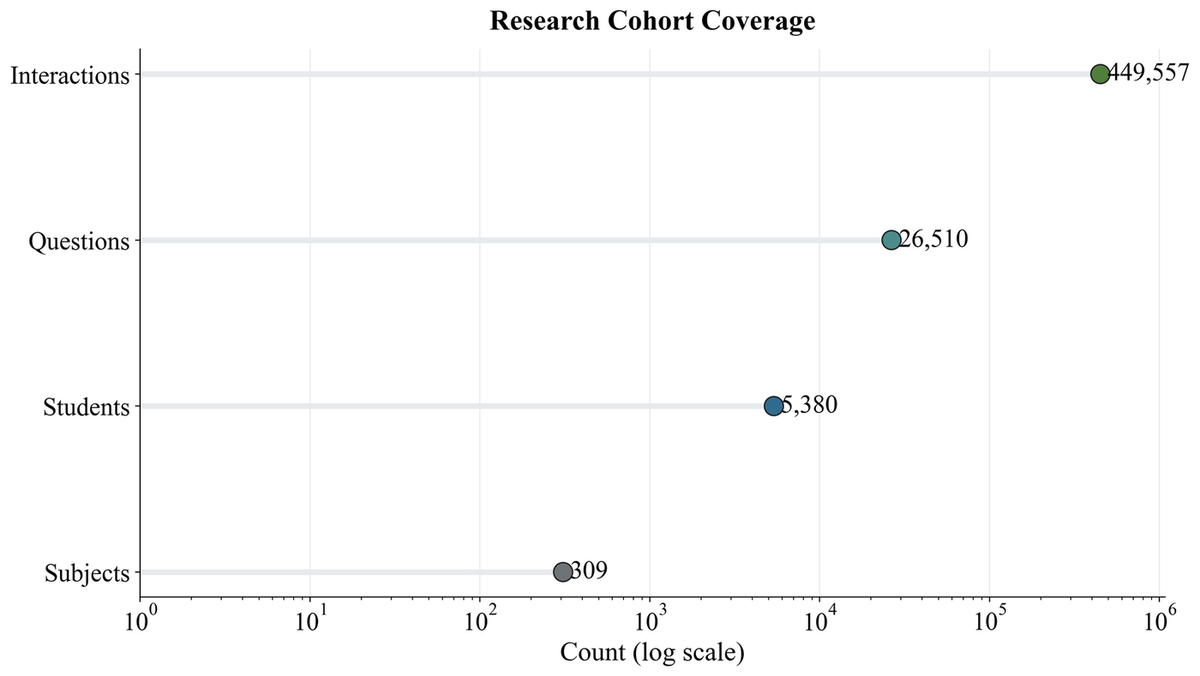

Saved/reindexed figure: <repository_root>/figures/final_01_dataset_coverage.png


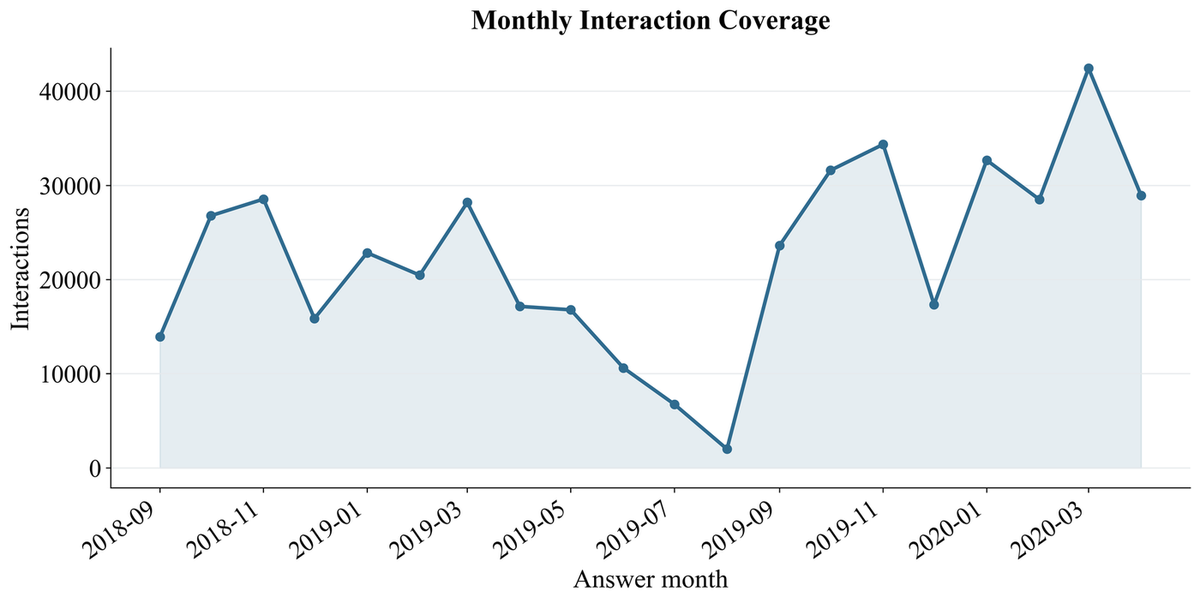

Saved/reindexed figure: <repository_root>/figures/final_02_interaction_timeline.png


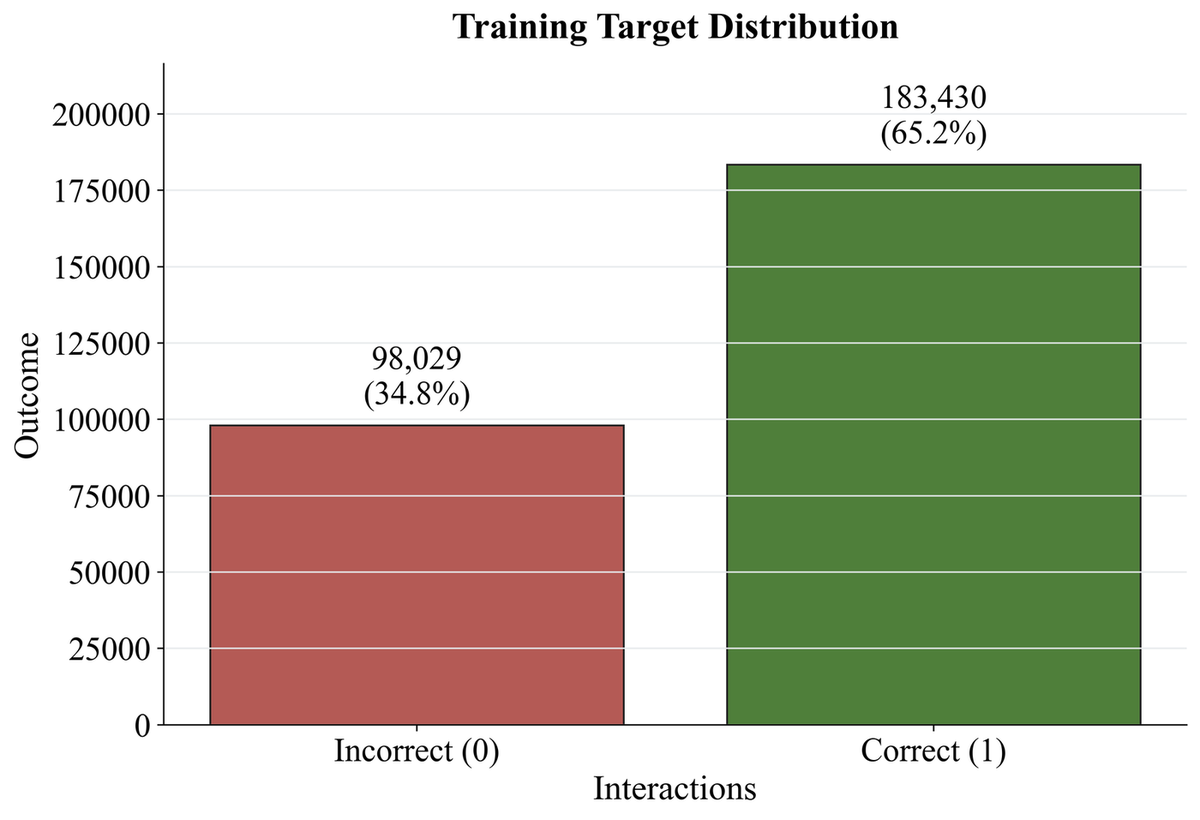

Saved/reindexed figure: <repository_root>/figures/final_03_target_distribution.png


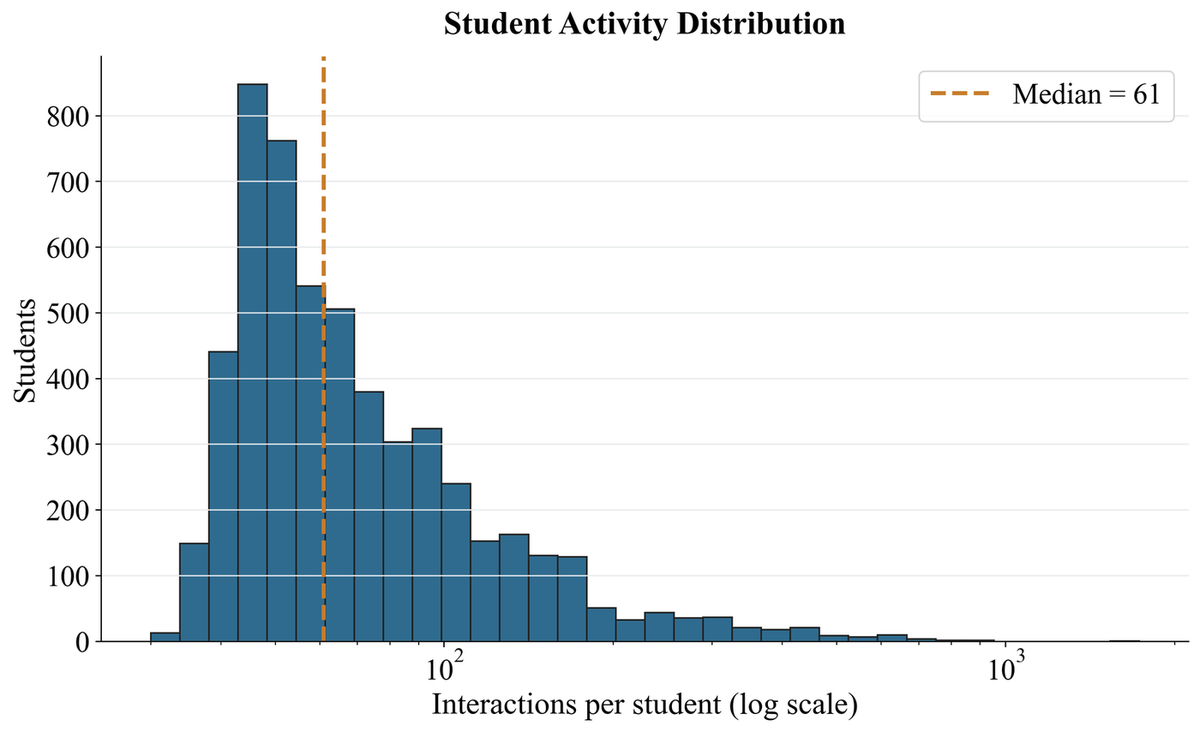

Saved/reindexed figure: <repository_root>/figures/final_04_student_activity_distribution.png


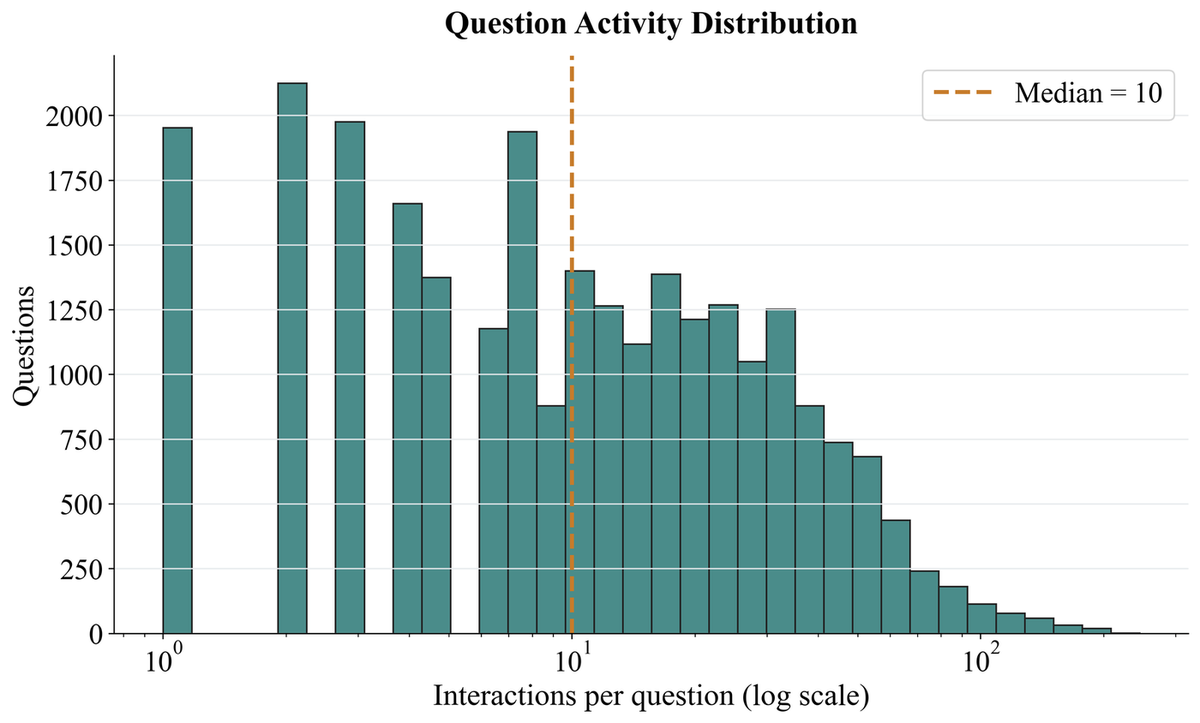

Saved/reindexed figure: <repository_root>/figures/final_05_question_activity_distribution.png


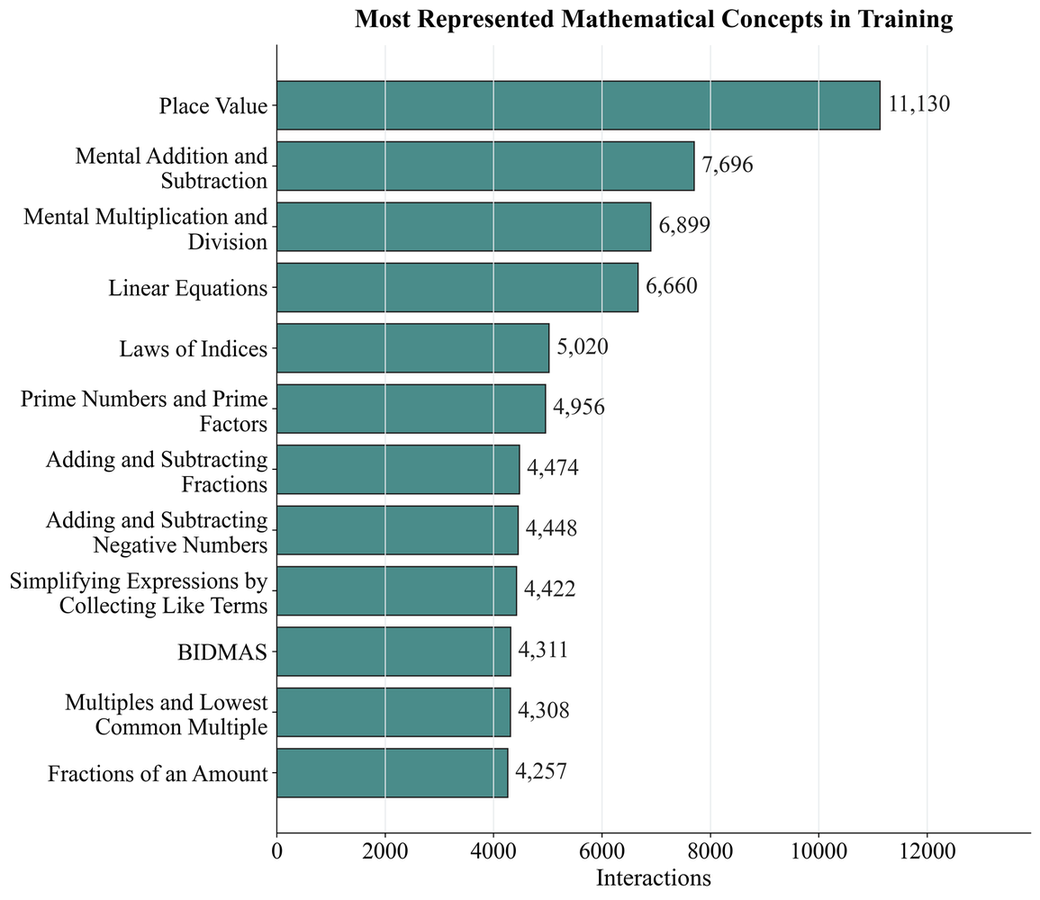

Saved/reindexed figure: <repository_root>/figures/final_06_top_concept_exposure.png


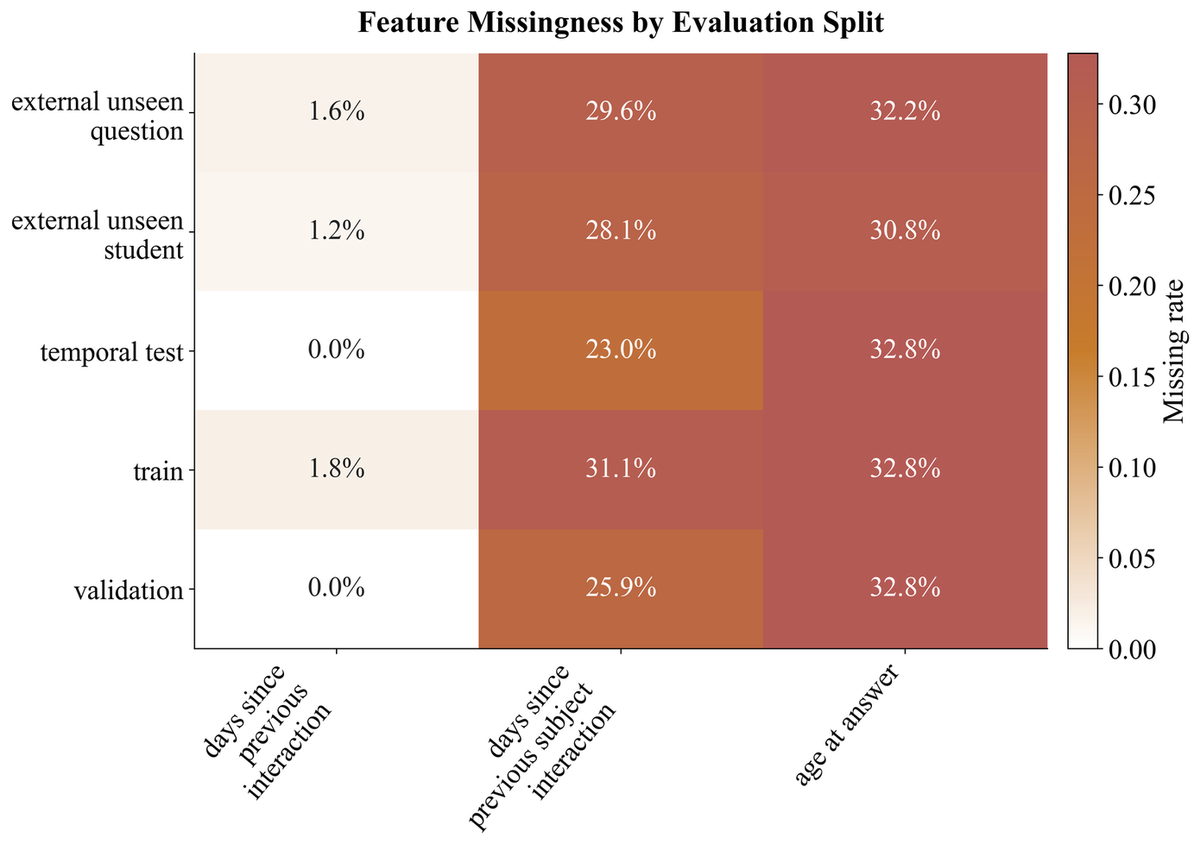

Saved/reindexed figure: <repository_root>/figures/final_07_predictor_missingness_by_split.png


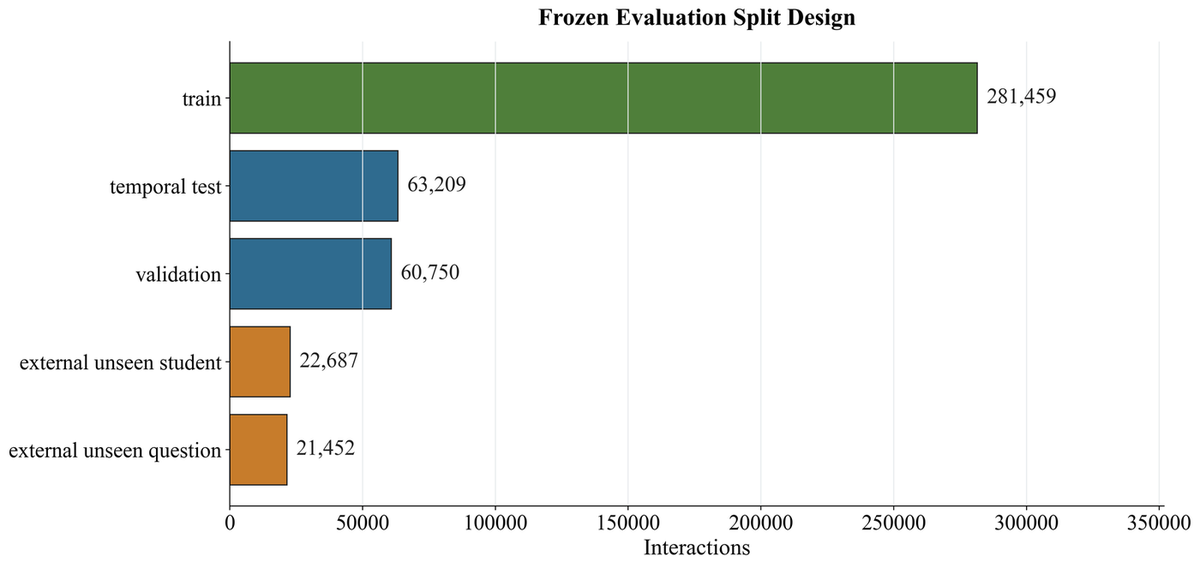

Saved/reindexed figure: <repository_root>/figures/final_08_evaluation_split_sizes.png


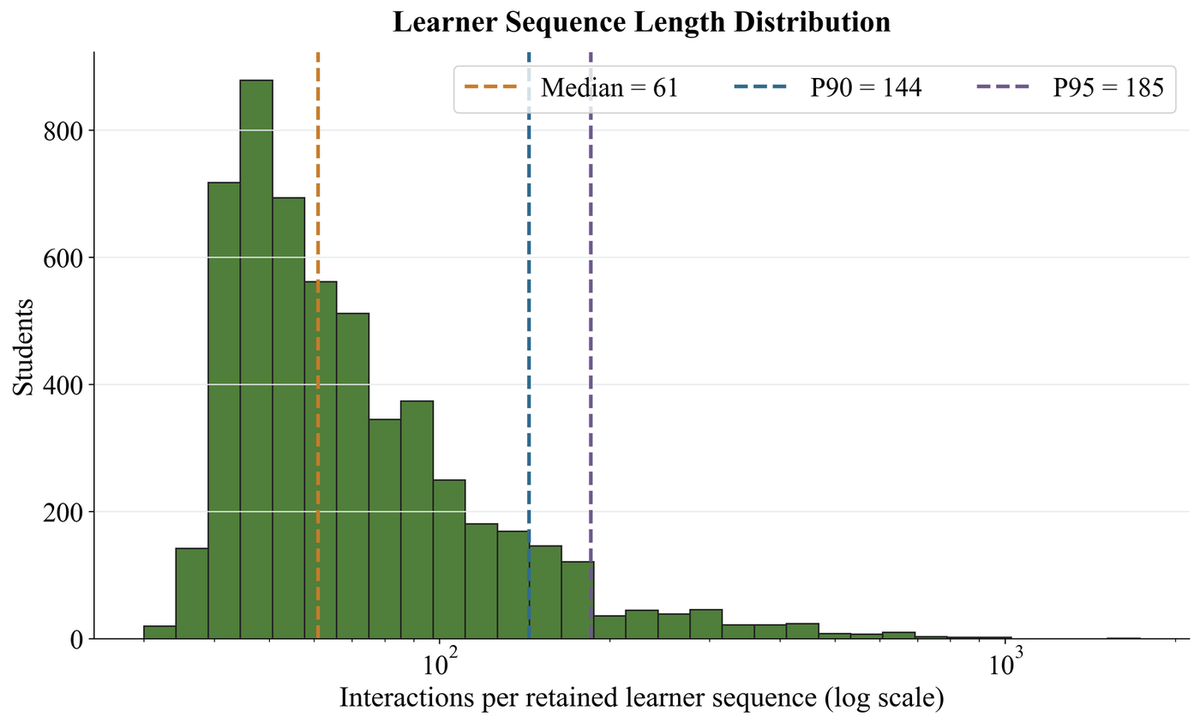

Saved/reindexed figure: <repository_root>/figures/final_11_sequence_length_distribution.png


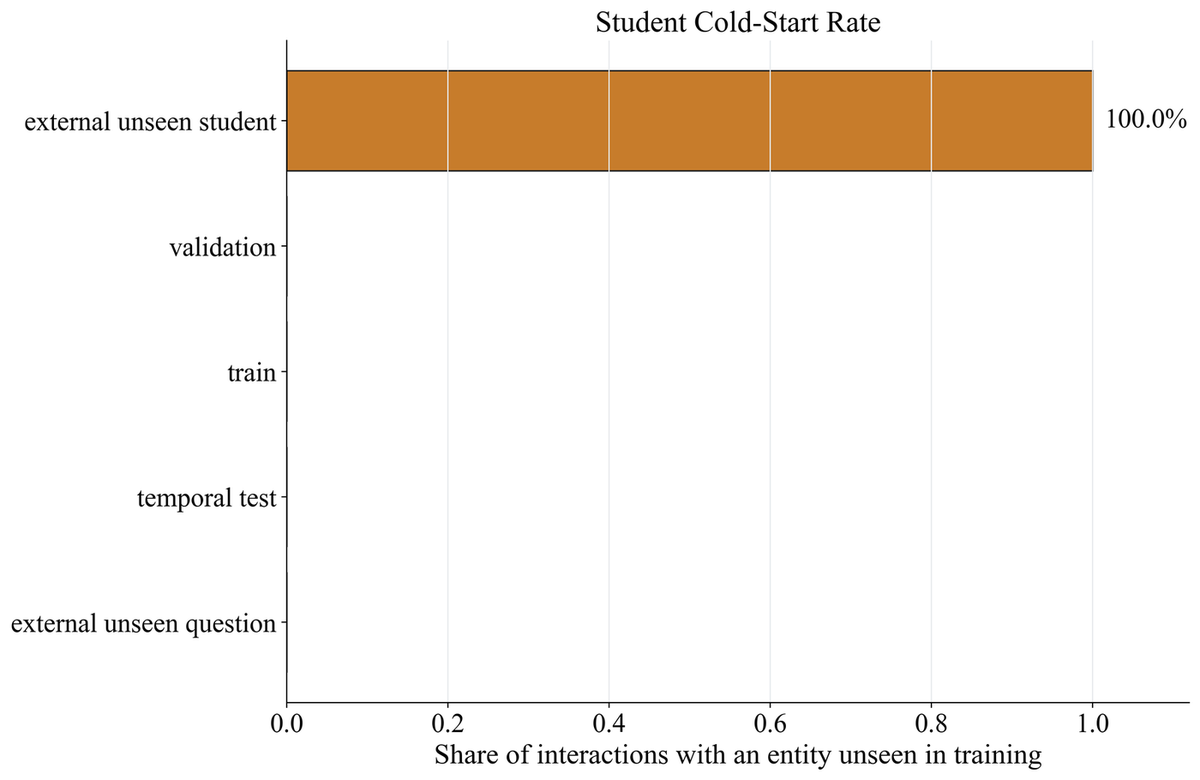

Saved figure: <repository_root>/figures/final_09_student_cold_start_design.png


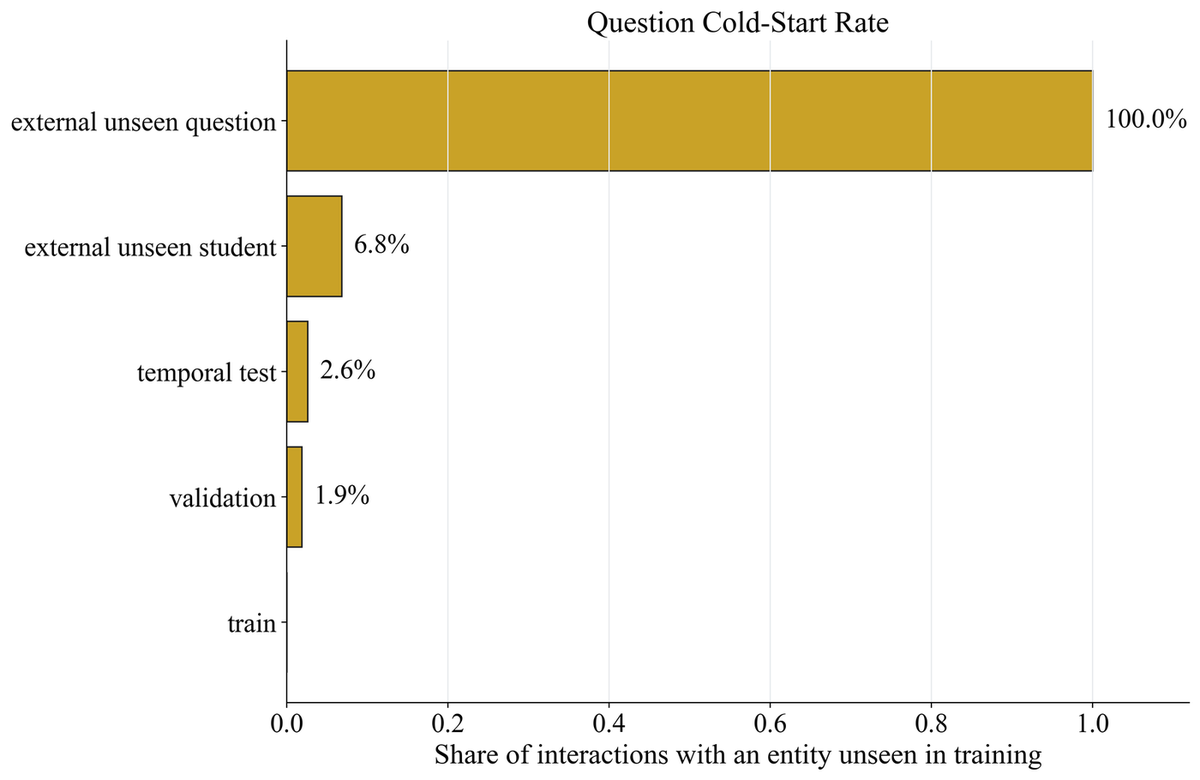

Saved figure: <repository_root>/figures/final_10_question_cold_start_design.png


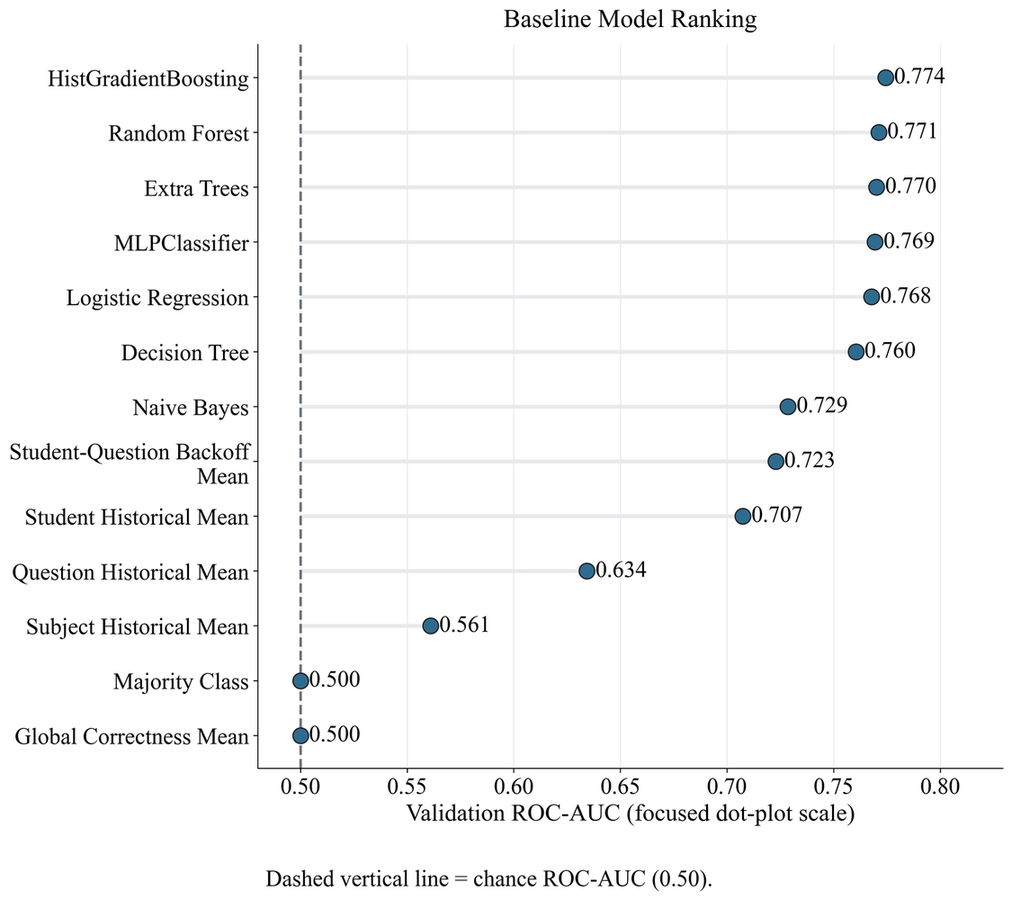

Saved figure: <repository_root>/figures/final_12_baseline_model_ranking.png


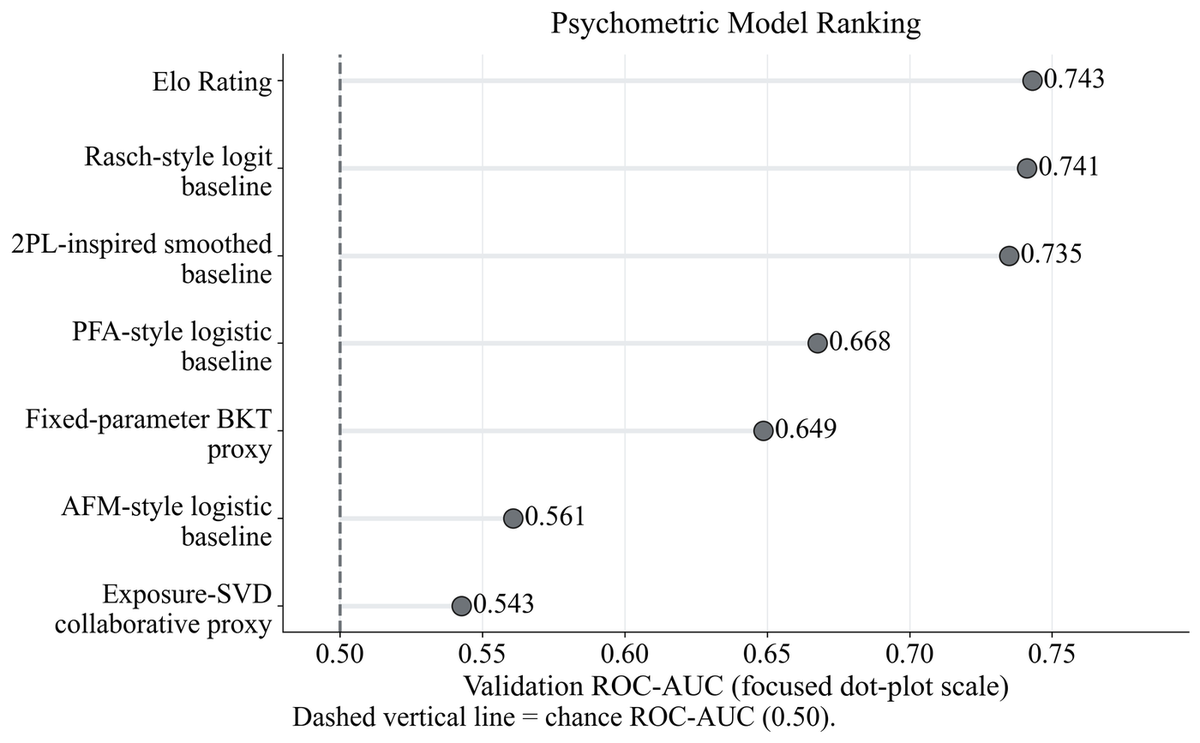

Saved figure: <repository_root>/figures/final_13_psychometric_model_ranking.png


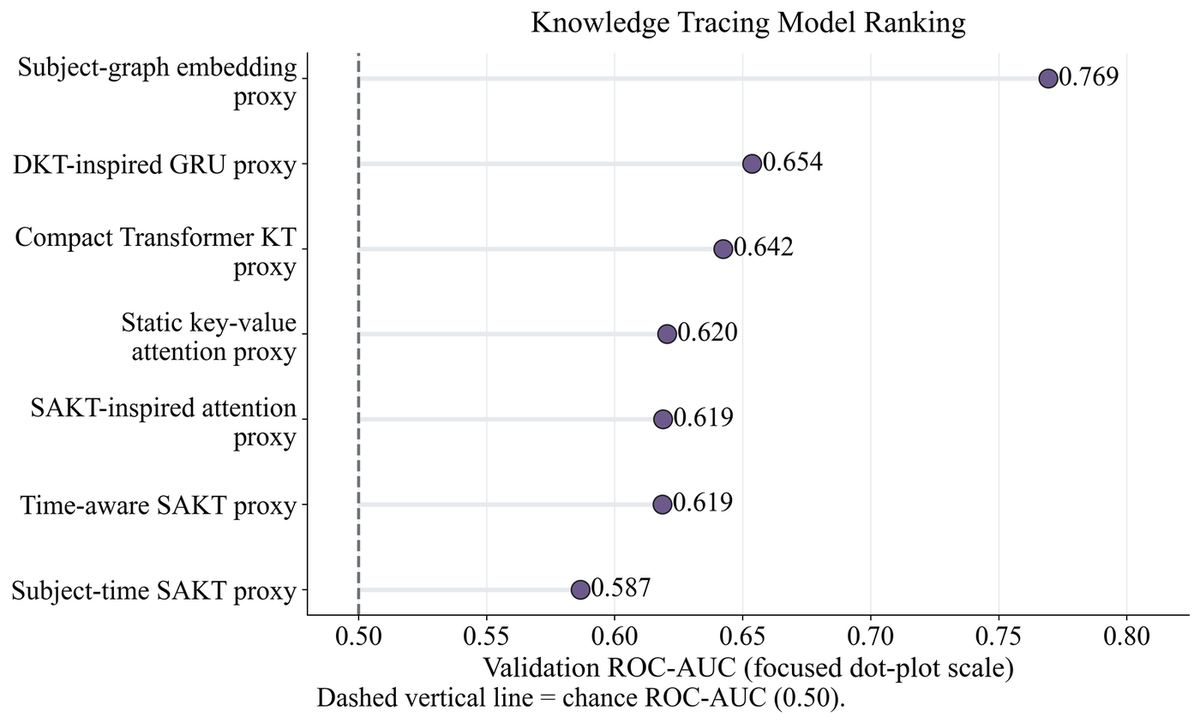

Saved figure: <repository_root>/figures/final_14_knowledge_tracing_model_ranking.png


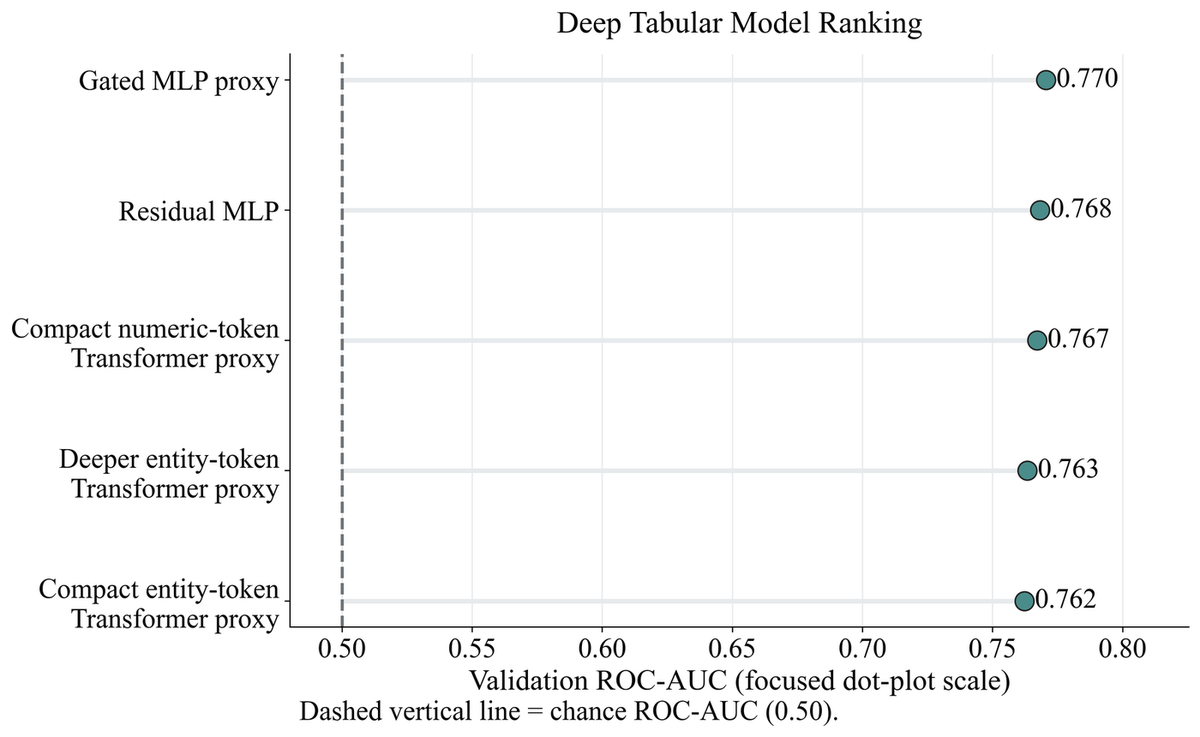

Saved figure: <repository_root>/figures/final_15_deep_tabular_model_ranking.png


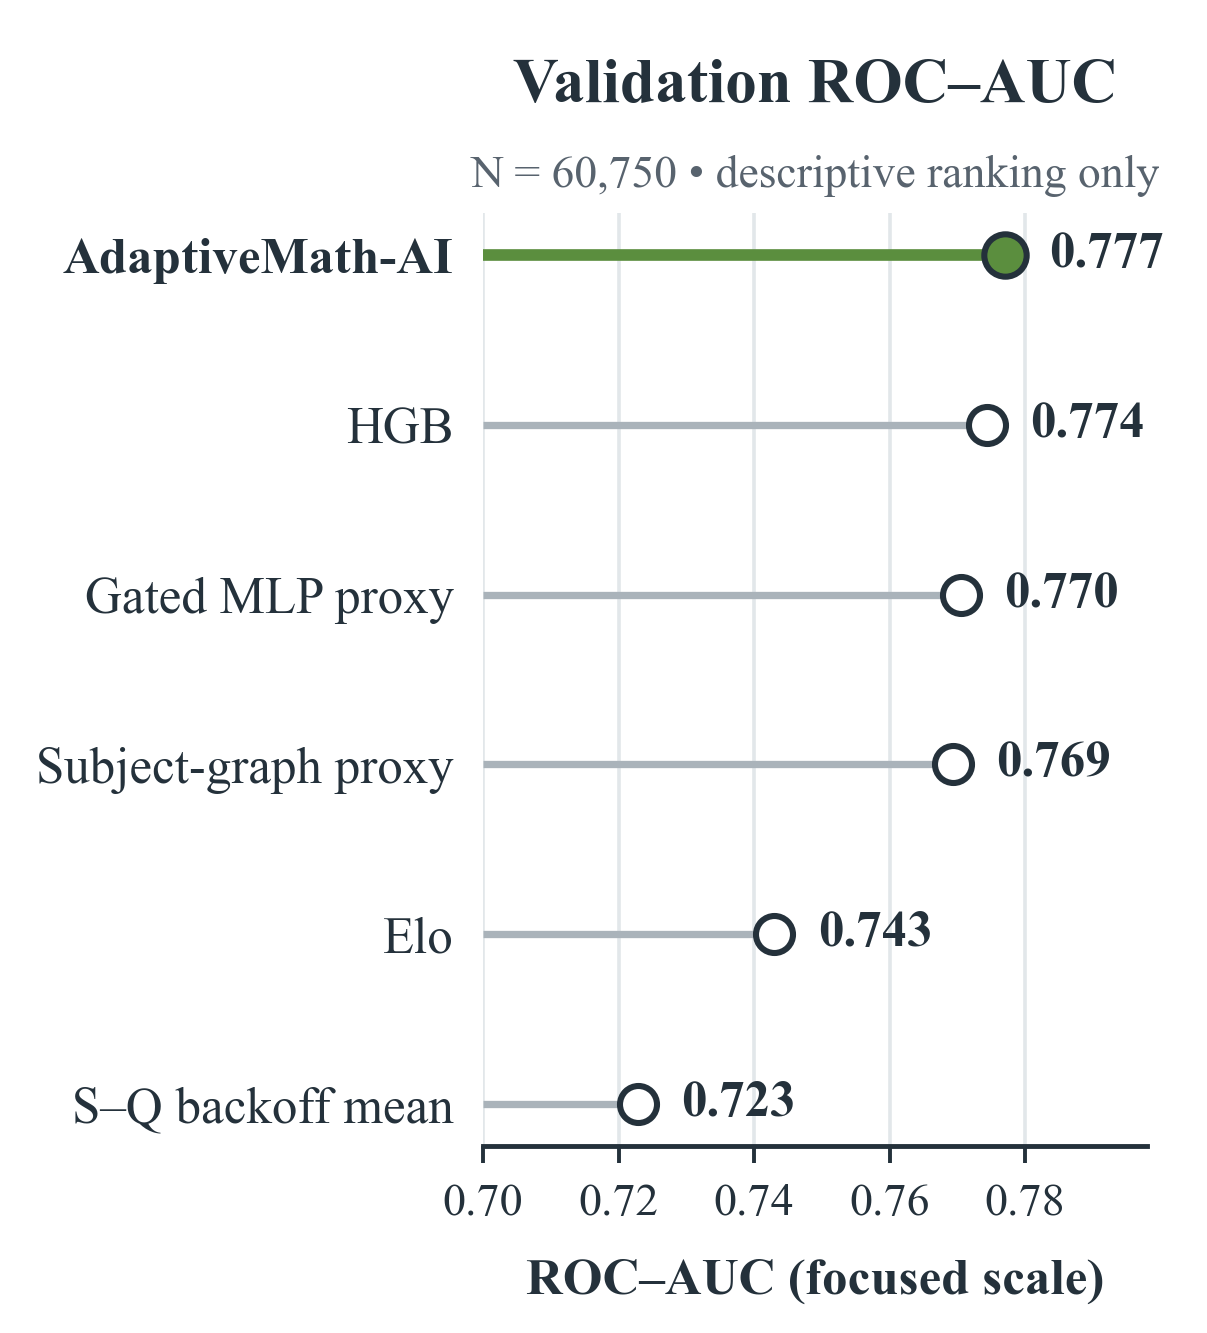

Saved figure: <repository_root>/figures/18_validation_model_context.png


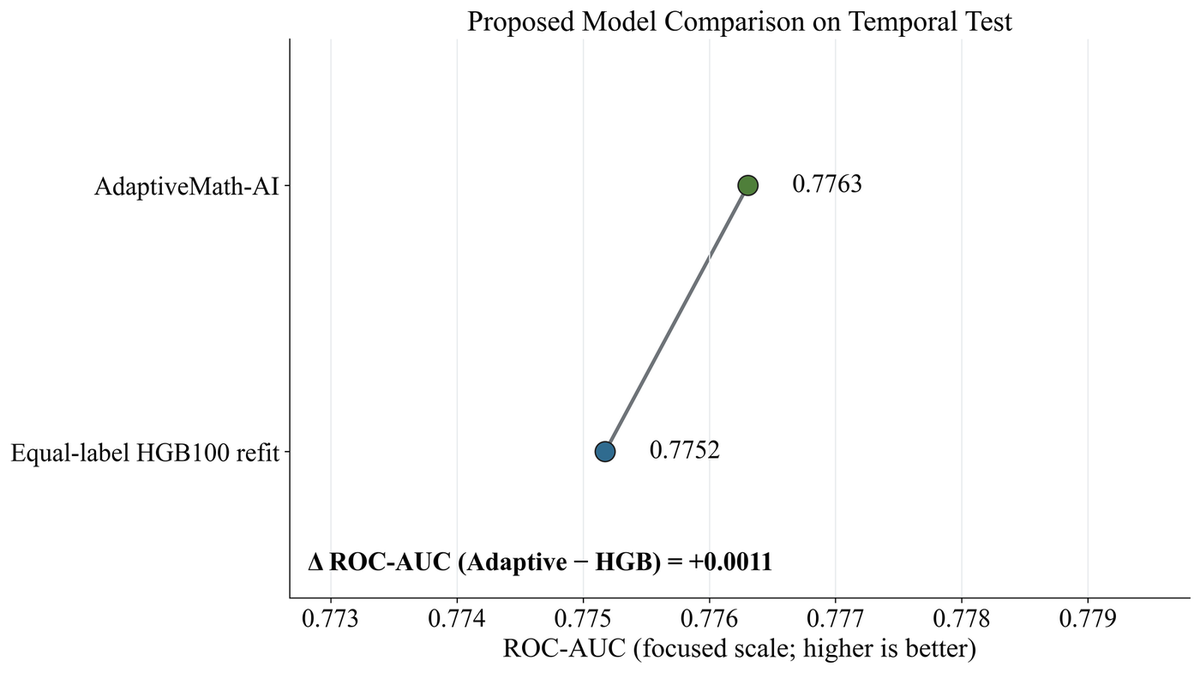

Saved figure: <repository_root>/figures/final_17_proposed_model_comparison_on_temporal_test.png


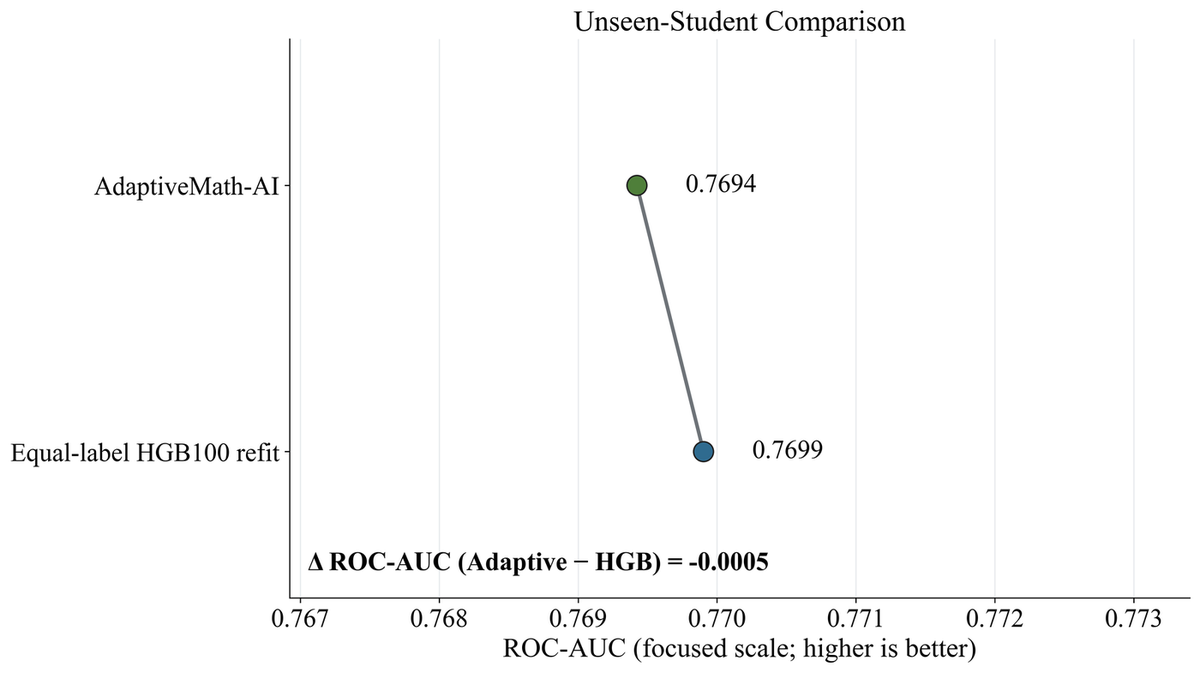

Saved figure: <repository_root>/figures/final_18_unseen_student_comparison.png


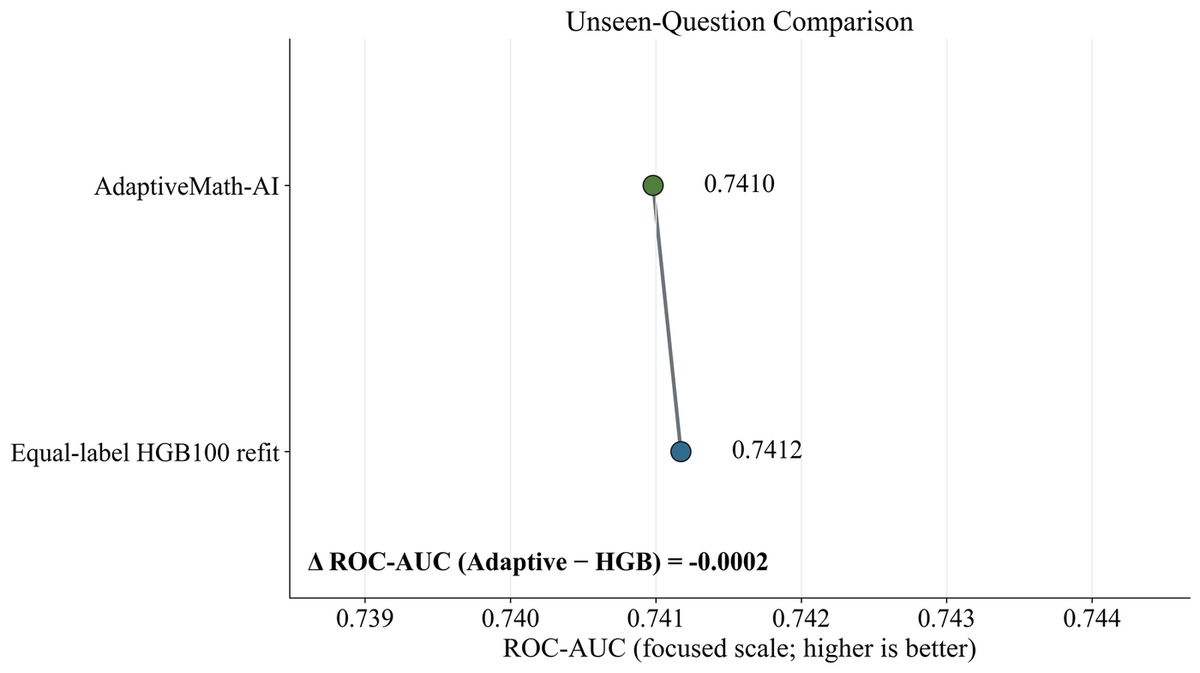

Saved figure: <repository_root>/figures/final_19_unseen_question_comparison.png


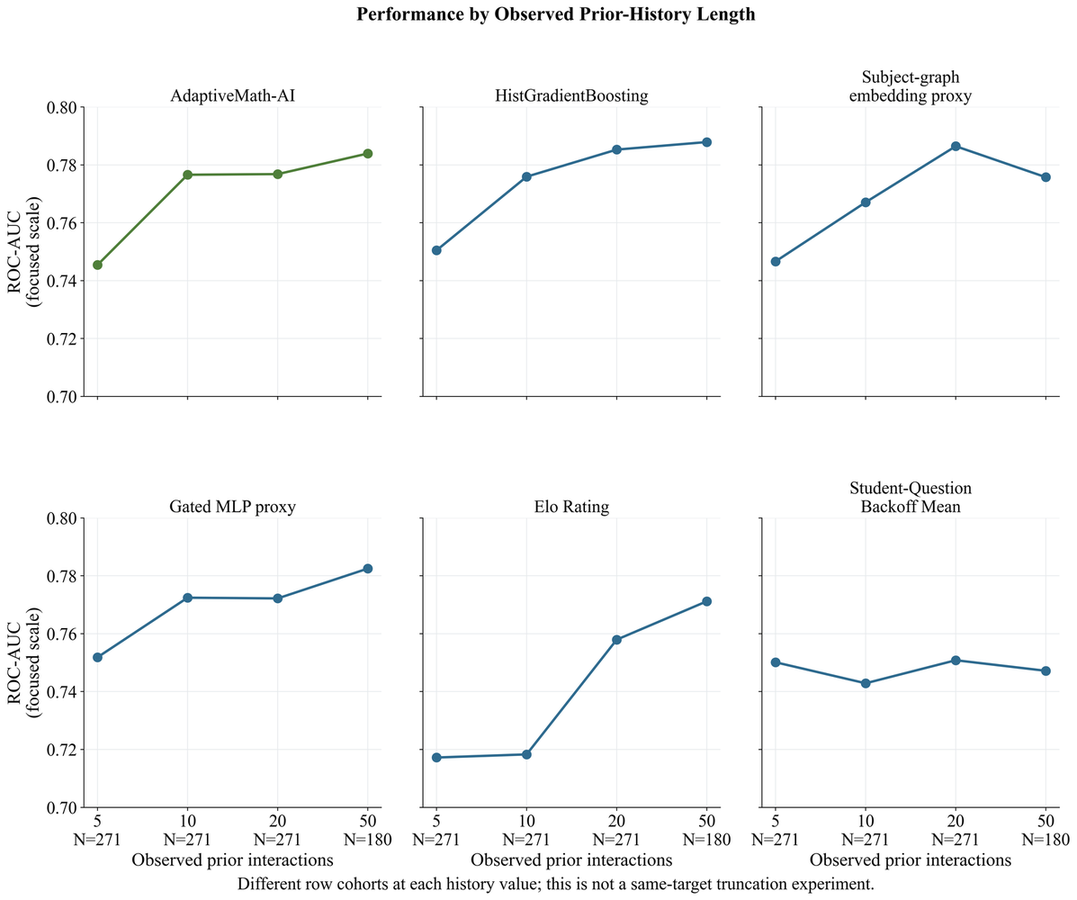

Saved figure: <repository_root>/figures/final_20_short_history_stability.png


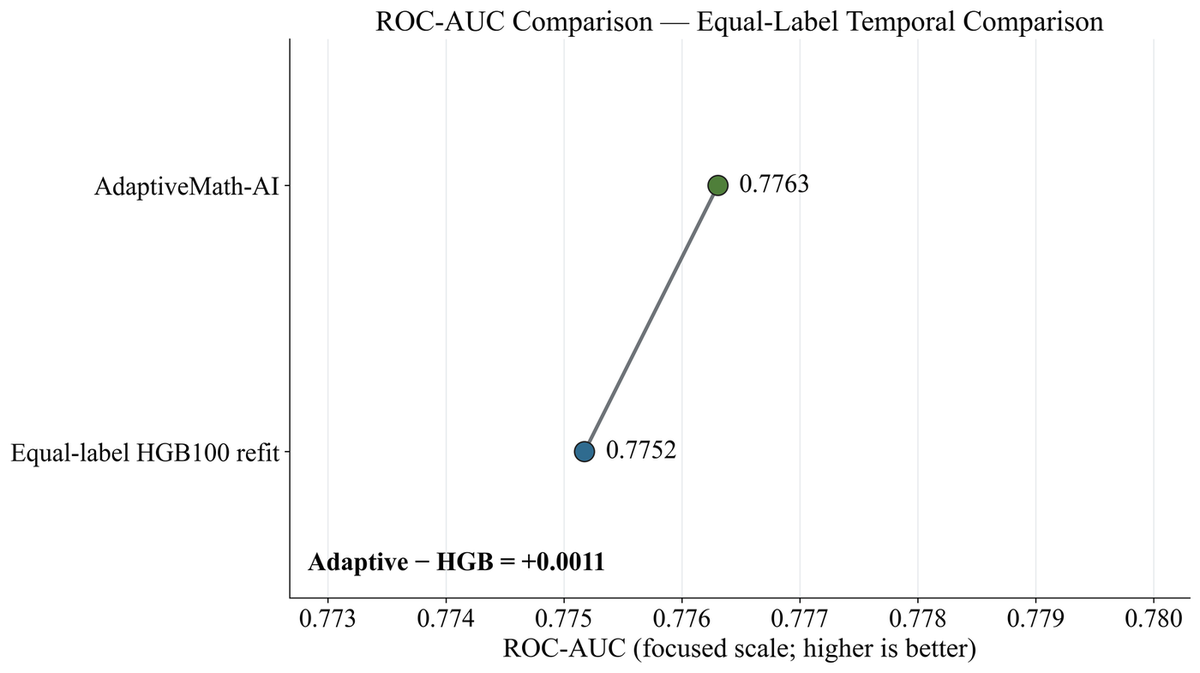

Saved figure: <repository_root>/figures/final_21_roc_auc_comparison.png


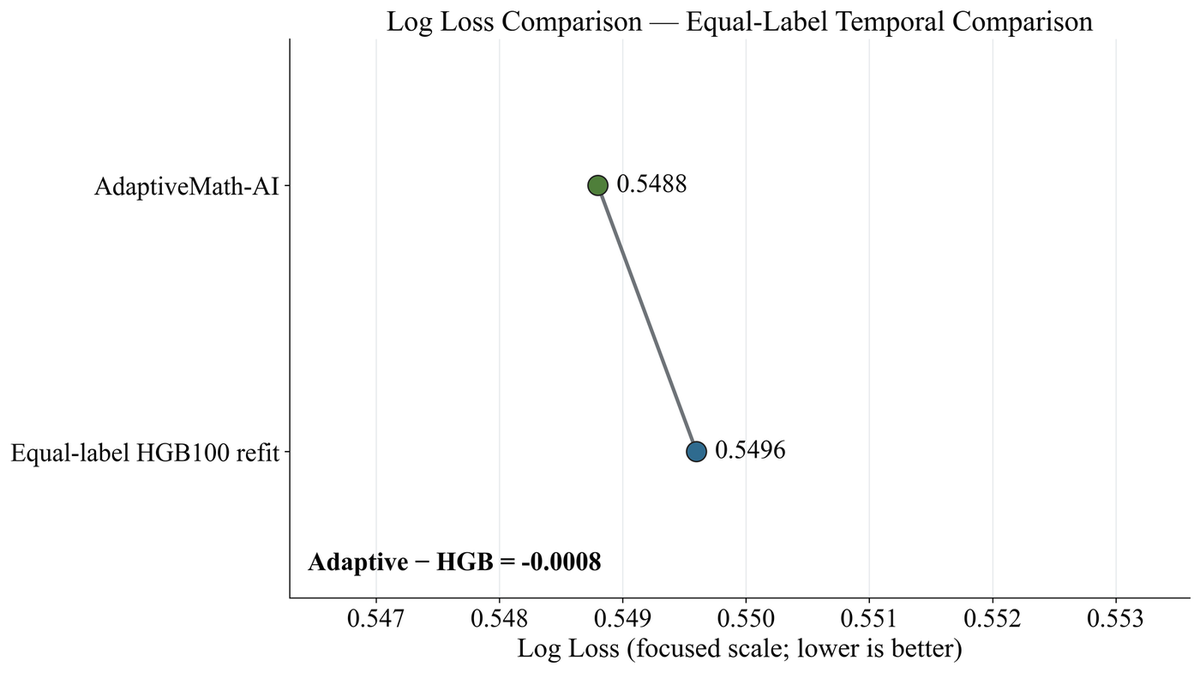

Saved figure: <repository_root>/figures/final_22_log_loss_comparison.png


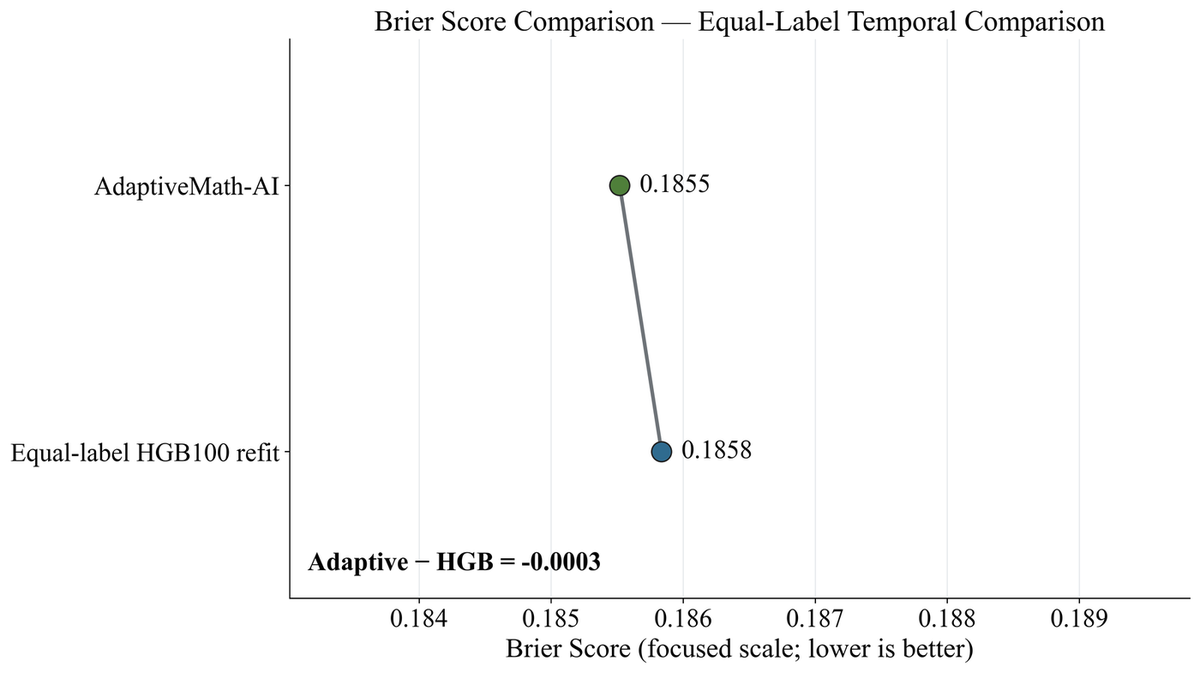

Saved figure: <repository_root>/figures/final_23_brier_score_comparison.png


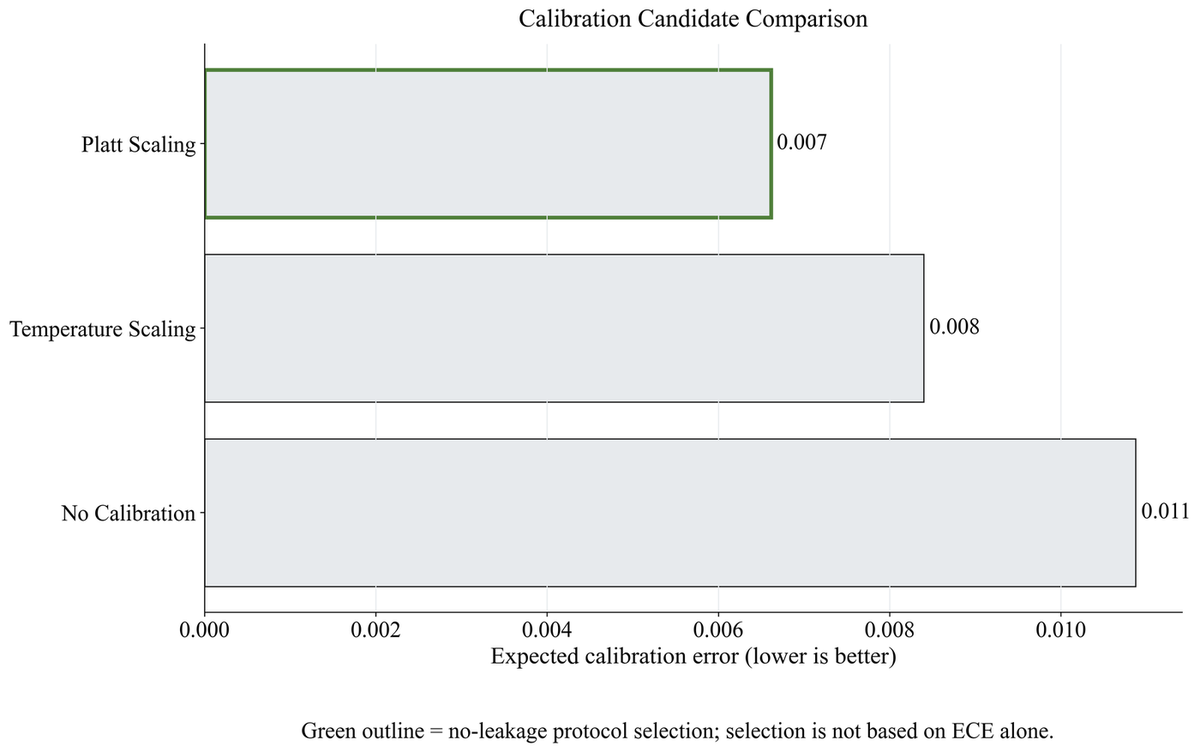

Saved figure: <repository_root>/figures/final_24_calibration_comparison.png


In [5]:
figure_records=[]
def record(number,title,filename,evidence,annotated=True):
    figure_records.append({"Figure_Number":number,"Title":title,"File":f"figures/{filename}","Evidence_Source":evidence,"DPI":350,"Font_Size_Range":"18–20 pt","Annotated":bool(annotated)})
# Reuse already generated 350-dpi pretraining evidence under final indexed names.
for obsolete in ["final_06_subject_hierarchy_coverage.png","final_07_missingness_and_data_quality.png","final_08_temporal_split_design.png"]: (FIGURES/obsolete).unlink(missing_ok=True)
pretraining=[(1,"Dataset Coverage","pretraining_dataset_coverage.png"),(2,"Interaction Timeline","pretraining_interaction_timeline.png"),(3,"Target Distribution","pretraining_target_distribution_train.png"),(4,"Student Activity Distribution","pretraining_student_activity_histogram.png"),(5,"Question Activity Distribution","pretraining_question_activity_histogram.png"),(6,"Top Concept Exposure","pretraining_subject_coverage.png"),(7,"Predictor Missingness by Split","pretraining_missingness_matrix.png"),(8,"Evaluation Split Sizes","pretraining_split_design.png"),(11,"Sequence Length Distribution","pretraining_sequence_length_distribution.png")]
for number,title,source in pretraining:
    filename=f"final_{number:02d}_"+title.lower().replace(" ","_").replace("-","_")+".png"; shutil.copy2(FIGURES/source,FIGURES/filename); record(number,title,filename,source); display(Image(filename=str(FIGURES/filename),width=950)); print(f"Saved/reindexed figure: {FIGURES/filename}")
# Separate focal cold-start figures; zero labels are intentionally suppressed.
cold=pd.read_csv(TABLES/"cold_start_entity_summary.csv").set_index("split_id")
for number,title,column,color,filename in [(9,"Student Cold-Start Rate","student_cold_start_rate",PALETTE["orange"],"final_09_student_cold_start_design.png"),(10,"Question Cold-Start Rate","question_cold_start_rate",PALETTE["gold"],"final_10_question_cold_start_design.png")]:
    values=cold[column].sort_values(); fig,ax=plt.subplots(figsize=(14,8)); bars=ax.barh(wrap_labels(values.index,24),values.values,color=color,edgecolor=PALETTE["black"]); ax.set_xlim(0,1.12); ax.set_xlabel("Share of interactions with an entity unseen in training"); ax.set_title(title); ax.grid(axis="x",color=PALETTE["light_gray"]);
    for bar,value in zip(bars,values):
        if value>=.005: ax.text(value+.015,bar.get_y()+bar.get_height()/2,f"{value:.1%}",va="center",fontsize=18)
    fig.subplots_adjust(left=.30); save_and_show_figure(fig,filename); record(number,title,filename,"cold_start_entity_summary.csv",annotated=True)
# Rankings.
rank_specs=[(12,"Baseline Model Ranking",final_validation[final_validation.Family.isin(["Simple","Classical ML"])].head(14),PALETTE["blue"]),(13,"Psychometric Model Ranking",final_validation[final_validation.Family.eq("Psychometric")],PALETTE["gray"]),(14,"Knowledge Tracing Model Ranking",final_validation[final_validation.Family.eq("Knowledge Tracing")],PALETTE["purple"]),(15,"Deep Tabular Model Ranking",final_validation[final_validation.Family.eq("Deep Tabular")],PALETTE["teal"])]
for number,title,frame,color in rank_specs:
    fig,ax=plot_horizontal_metric_ranking(frame,"Model","ROC_AUC",color,title,"Validation ROC-AUC"); filename=f"final_{number:02d}_"+title.lower().replace(" ","_")+".png"; save_and_show_figure(fig,filename); record(number,title,filename,"final_validation_primary_metrics.csv")
# Proposed-model scenario comparisons.
# Validation context uses a chance-anchored dot plot; external scenarios use the authoritative equal-label HGB refit.
# Figure 16 — Validation ROC–AUC context (single-column A4).
validation_model_order=["AdaptiveMath-AI","HistGradientBoosting","Gated MLP proxy","Subject-graph embedding proxy","Elo Rating","Student-Question Backoff Mean"]
validation_label_map={"AdaptiveMath-AI":"AdaptiveMath-AI","HistGradientBoosting":"HGB","Gated MLP proxy":"Gated MLP proxy","Subject-graph embedding proxy":"Subject-graph proxy","Elo Rating":"Elo","Student-Question Backoff Mean":"S–Q backoff mean"}
validation_context=final_validation.set_index("Model").loc[validation_model_order].reset_index(); validation_context["Figure_Label"]=validation_context.Model.map(validation_label_map)
column_width_inches=3.45
figure_height_inches=max(3.70,1.05+0.46*len(validation_context))
fig,ax=plt.subplots(figsize=(column_width_inches,figure_height_inches))
y=np.arange(len(validation_context)); values=validation_context.ROC_AUC.to_numpy(); focused_left=.70
neutral="#AAB3BA"; ink="#24313B"; focal_green="#5B8E3E"; grid="#E2E7EA"
line_colors=[focal_green if model=="AdaptiveMath-AI" else neutral for model in validation_context.Model]
line_widths=[2.4 if model=="AdaptiveMath-AI" else 1.5 for model in validation_context.Model]
ax.hlines(y,focused_left,values,color=line_colors,linewidth=line_widths,zorder=1)
for yi,(model,value) in enumerate(zip(validation_context.Model,values)):
    focal=model=="AdaptiveMath-AI"
    ax.scatter(value,yi,s=76 if focal else 58,facecolor=focal_green if focal else "white",edgecolor=ink,linewidth=1.25,zorder=3)
    ax.annotate(f"{value:.3f}",xy=(value,yi),xytext=(9,0),textcoords="offset points",va="center",ha="left",fontsize=10.5,fontweight="bold" if focal else "semibold",color=ink,annotation_clip=False)
ax.set_yticks(y,validation_context.Figure_Label); ax.invert_yaxis()
for tick,model in zip(ax.get_yticklabels(),validation_context.Model):
    tick.set_fontsize(10.5); tick.set_color(ink); tick.set_fontweight("bold" if model=="AdaptiveMath-AI" else "normal")
ax.set_xlim(focused_left,.798); ax.set_xticks([.70,.72,.74,.76,.78]); ax.tick_params(axis="x",labelsize=9.5,colors=ink,pad=4); ax.tick_params(axis="y",length=0,pad=6)
ax.grid(axis="x",color=grid,linewidth=.75); ax.set_axisbelow(True); ax.spines["left"].set_visible(False); ax.spines["bottom"].set_color(ink); ax.spines["bottom"].set_linewidth(1.0)
ax.set_xlabel("ROC–AUC (focused scale)",fontsize=10.5,fontweight="semibold",color=ink,labelpad=7)
ax.set_title("Validation ROC–AUC",fontsize=13,fontweight="bold",color=ink,pad=23)
ax.text(.5,1.018,"N = 60,750 • descriptive ranking only",transform=ax.transAxes,ha="center",va="bottom",fontsize=9.4,color="#58636E")
fig.subplots_adjust(left=.40,right=.95,bottom=.14,top=.84)
figure_filename="18_validation_model_context.png"
figure_path=FIGURES/figure_filename
fig.savefig(figure_path,dpi=350,facecolor="white"); plt.show(); print(f"Saved figure: {figure_path}")
record(16,"Validation ROC–AUC Context — Descriptive Only",figure_filename,"final_validation_primary_metrics.csv")
fair=pd.read_csv(TABLES/"fair_label_budget_comparison.csv"); scenario_specs=[(17,"Proposed Model Comparison on Temporal Test","temporal_test"),(18,"Unseen-Student Comparison","external_unseen_student"),(19,"Unseen-Question Comparison","external_unseen_question")]
for number,title,split_name in scenario_specs:
    row=fair[fair.Split.eq(split_name)].iloc[0]; values=np.array([row.AdaptiveMath_AI_ROC_AUC,row.ROC_AUC]); labels=["AdaptiveMath-AI","Equal-label HGB100 refit"]; y=np.array([1,0]); fig,ax=plt.subplots(figsize=(14,7)); ax.plot(values,y,color=PALETTE["gray"],linewidth=2.5,zorder=1); ax.scatter(values,y,s=190,color=[PALETTE["green"],PALETTE["blue"]],edgecolor=PALETTE["black"],zorder=3); ax.set_yticks(y,labels);
    for yi,value in zip(y,values): ax.text(value+.00035,yi,f"{value:.4f}",va="center",fontsize=18)
    delta=row.Delta_ROC_AUC_AdaptiveMinusFairHGB; ax.text(.02,.05,f"Δ ROC-AUC (Adaptive − HGB) = {delta:+.4f}",transform=ax.transAxes,fontsize=18,fontweight="bold"); ax.set_xlim(values.min()-.0025,values.max()+.0035); ax.set_ylim(-.55,1.55); ax.set_xlabel("ROC-AUC (focused scale; higher is better)"); ax.set_title(title); ax.grid(axis="x",color=PALETTE["light_gray"]); fig.subplots_adjust(left=.28); filename=f"final_{number:02d}_"+title.lower().replace(" ","_").replace("-","_")+".png"; save_and_show_figure(fig,filename); record(number,title,filename,"fair_label_budget_comparison.csv")
# Short-history stability.
d=final_short[final_short.Model.isin(selected_models)].copy(); fig,axes=plt.subplots(2,3,figsize=(18,13),sharex=True,sharey=True); model_order=["AdaptiveMath-AI",best_classical,best_kt,best_deep,best_psych,best_simple]
for ax,model in zip(axes.ravel(),model_order):
    g=d[d.Model.eq(model)].sort_values("History_Cap"); pos=np.arange(len(g)); color=PALETTE["green"] if model=="AdaptiveMath-AI" else PALETTE["blue"]; ax.plot(pos,g.ROC_AUC,marker="o",linewidth=2.5,markersize=9,color=color); ax.set_title("\n".join(textwrap.wrap(model,22)),fontsize=18); ax.grid(color=PALETTE["light_gray"]); ax.set_xticks(pos,[f"{int(c)}\nN={int(n):,}" for c,n in zip(g.History_Cap,g.N)]); ax.set_ylim(.70,.80)
for ax in axes[:,0]: ax.set_ylabel("ROC-AUC\n(focused scale)")
for ax in axes[-1,:]: ax.set_xlabel("Observed prior interactions")
fig.suptitle("Performance by Observed Prior-History Length",fontsize=20,fontweight="bold",y=.99); fig.text(.5,.02,"Different row cohorts at each history value; this is not a same-target truncation experiment.",ha="center",fontsize=18); fig.subplots_adjust(top=.88,bottom=.11,hspace=.42,wspace=.14); save_and_show_figure(fig,"final_20_short_history_stability.png"); record(20,"Performance by Observed Prior-History Length","final_20_short_history_stability.png","final_short_history_metrics.csv",annotated=True)
# Metric comparisons.
fair_temporal=fair[fair.Split.eq("temporal_test")].iloc[0]; boot_temporal=pd.read_csv(TABLES/"proposed_model_cluster_bootstrap.csv").query("Split=='temporal_test'").iloc[0]
fair_pairs=[(21,"ROC-AUC Comparison",fair_temporal.AdaptiveMath_AI_ROC_AUC,fair_temporal.ROC_AUC,"higher is better"),(22,"Log Loss Comparison",fair_temporal.Log_Loss+boot_temporal.Delta_Log_Loss,fair_temporal.Log_Loss,"lower is better"),(23,"Brier Score Comparison",fair_temporal.Brier_Score+boot_temporal.Delta_Brier,fair_temporal.Brier_Score,"lower is better")]
for number,title,adaptive_value,hgb_value,direction in fair_pairs:
    values=np.array([adaptive_value,hgb_value]); y=np.array([1,0]); fig,ax=plt.subplots(figsize=(14,7)); ax.plot(values,y,color=PALETTE["gray"],linewidth=2.5); ax.scatter(values,y,s=190,color=[PALETTE["green"],PALETTE["blue"]],edgecolor=PALETTE["black"],zorder=3); ax.set_yticks(y,["AdaptiveMath-AI","Equal-label HGB100 refit"])
    for yi,value in zip(y,values): ax.text(value+max(np.ptp(values)*.16,.00015),yi,f"{value:.4f}",va="center",fontsize=18)
    delta=adaptive_value-hgb_value; margin=max(.0025,np.ptp(values)*2.2); ax.set_xlim(values.min()-margin,values.max()+margin*1.6); ax.set_ylim(-.55,1.55); ax.text(.02,.05,f"Adaptive − HGB = {delta:+.4f}",transform=ax.transAxes,fontsize=18,fontweight="bold"); ax.set_xlabel(f"{title.replace(' Comparison','')} (focused scale; {direction})"); ax.set_title(title+" — Equal-Label Temporal Comparison"); ax.grid(axis="x",color=PALETTE["light_gray"]); fig.subplots_adjust(left=.28); filename=f"final_{number:02d}_"+title.lower().replace(" ","_").replace("-","_")+".png"; save_and_show_figure(fig,filename); record(number,title,filename,"fair_label_budget_comparison.csv; proposed_model_cluster_bootstrap.csv")
calibration_detail=pd.read_csv(TABLES/"calibration_summary.csv").sort_values("Validation_ECE",ascending=False); fig,ax=plt.subplots(figsize=(14,9)); bars=ax.barh(wrap_labels(calibration_detail.Calibration),calibration_detail.Validation_ECE,color=PALETTE["light_gray"],edgecolor=PALETTE["black"],linewidth=1)
for bar,selected in zip(bars,calibration_detail.Selected):
    if selected: bar.set_edgecolor(PALETTE["green"]); bar.set_linewidth(3)
annotate_bars(ax); ax.set_xlabel("Expected calibration error (lower is better)"); ax.set_title("Calibration Candidate Comparison",pad=14); ax.grid(axis="x",color=PALETTE["light_gray"]); fig.text(.5,.025,"Green outline = no-leakage protocol selection; selection is not based on ECE alone.",ha="center",fontsize=18); fig.subplots_adjust(bottom=.18); save_and_show_figure(fig,"final_24_calibration_comparison.png"); record(24,"Calibration Candidate Comparison","final_24_calibration_comparison.png","calibration_summary.csv")

## Final figures 25–36: calibration, prediction risk, efficiency, ablations, and explanations

Reliability, risk–coverage, latency, component-removal and model-agnostic importance plots characterize probability quality, computational cost and model behaviour.

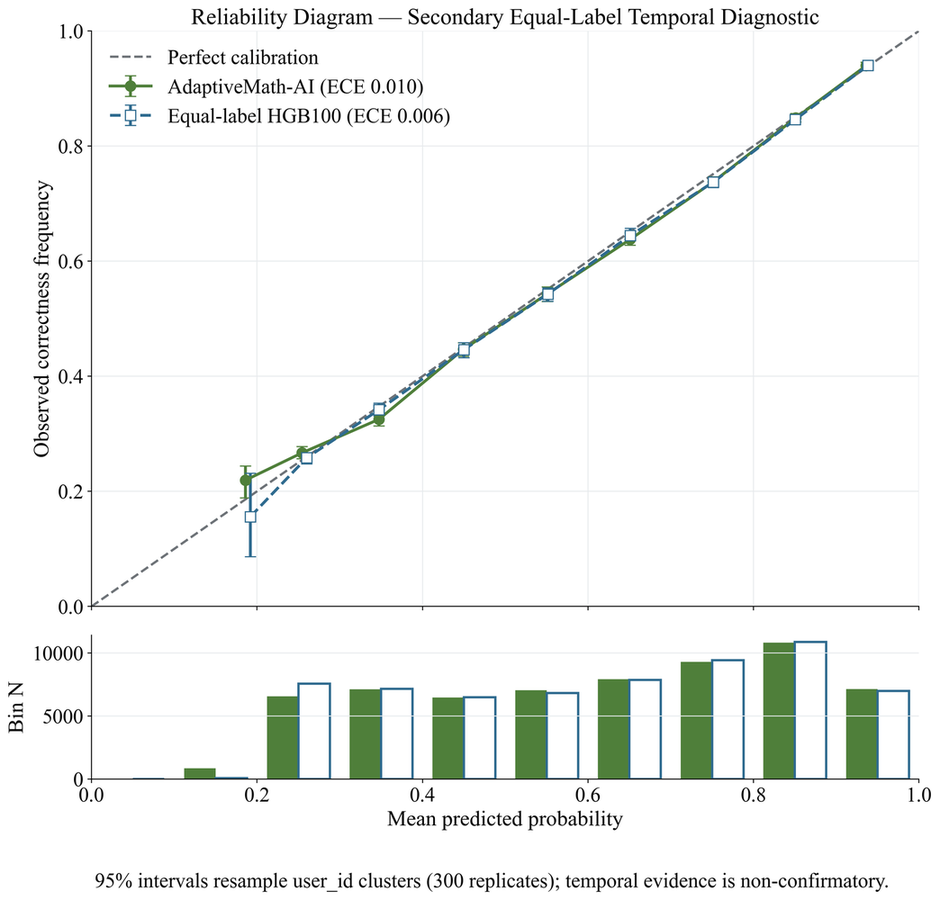

Saved figure: <repository_root>/figures/final_25_reliability_diagram.png


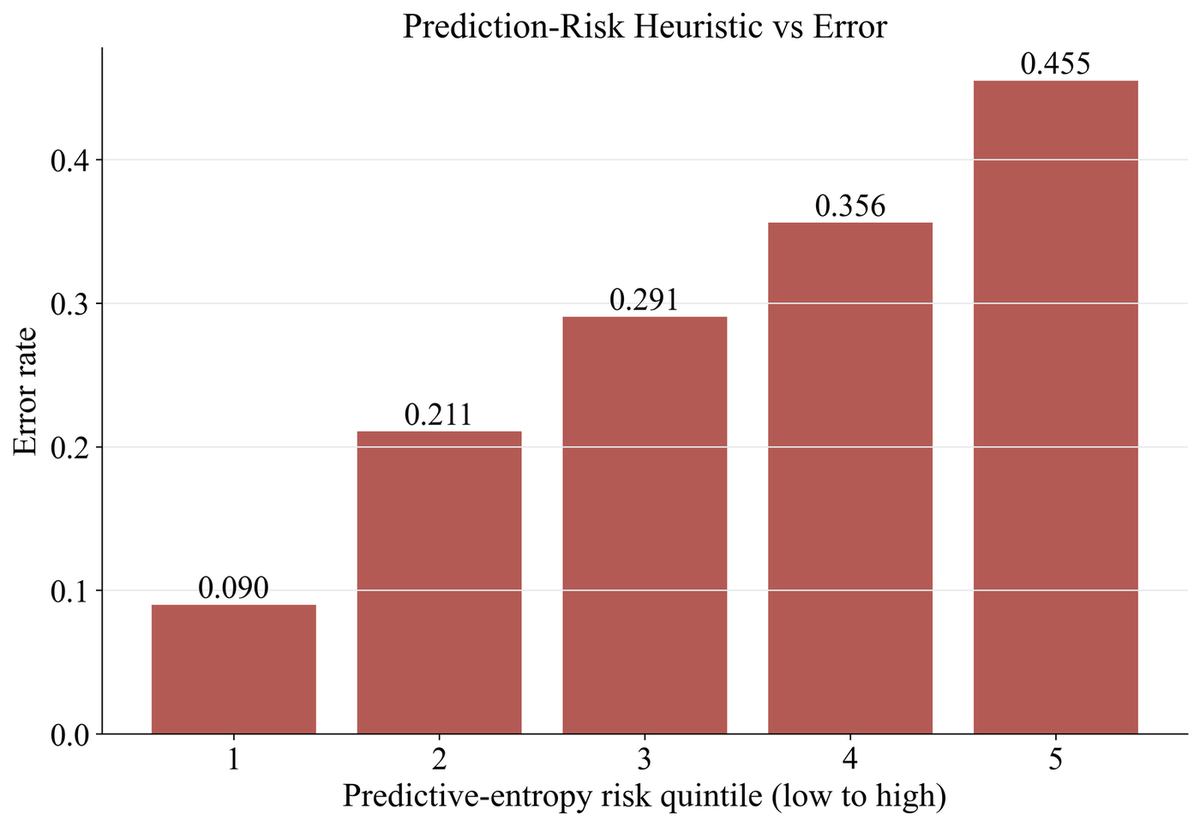

Saved figure: <repository_root>/figures/final_26_uncertainty_vs_error.png


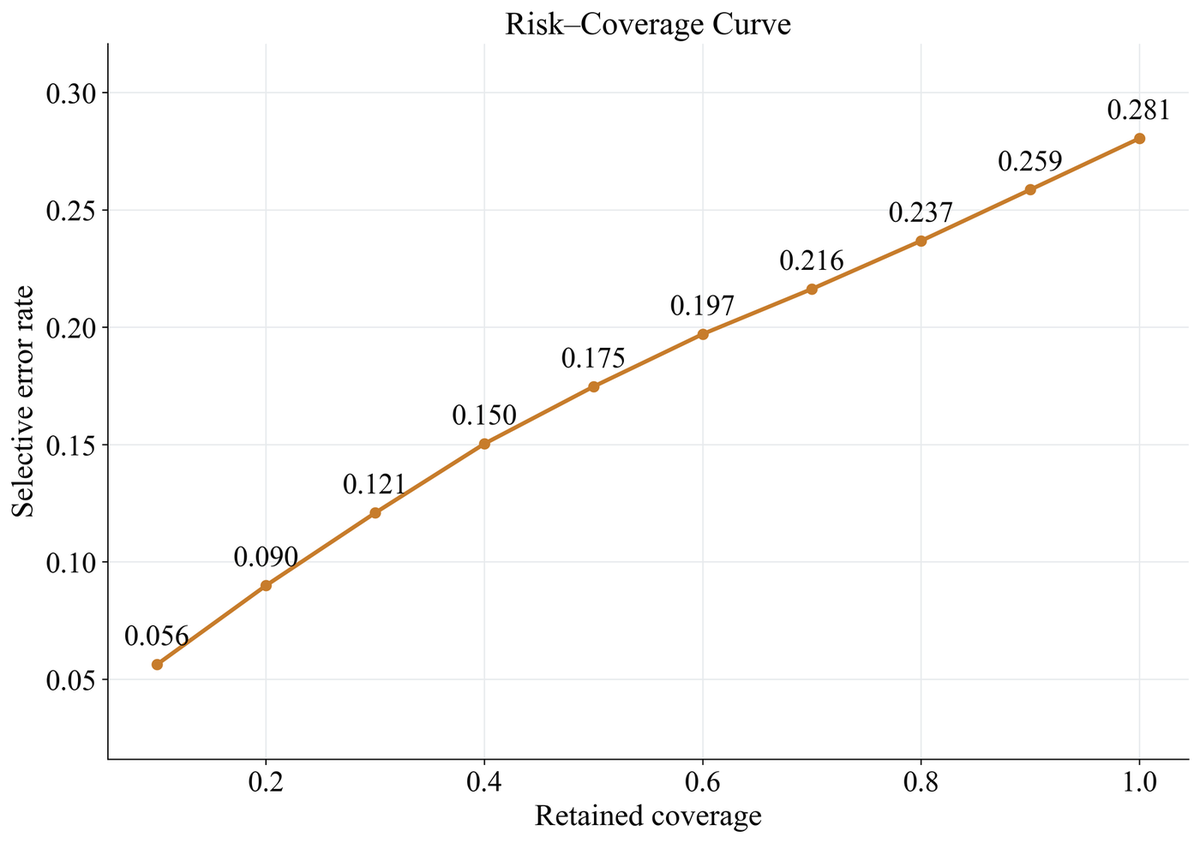

Saved figure: <repository_root>/figures/final_27_risk_coverage_curve.png


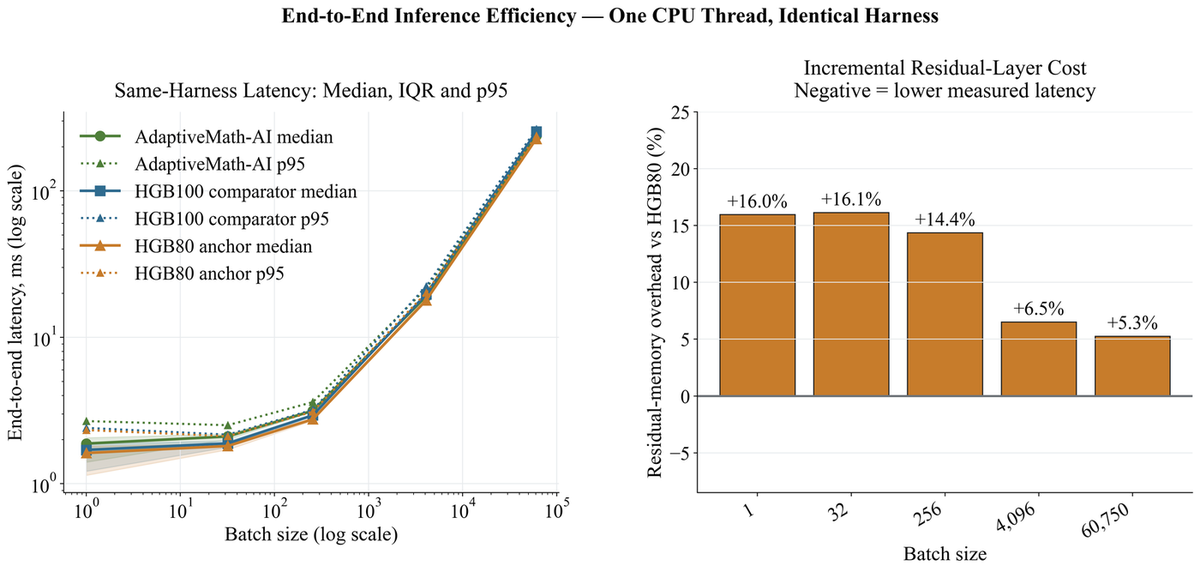

Saved figure: <repository_root>/figures/final_28_latency_throughput_comparison.png


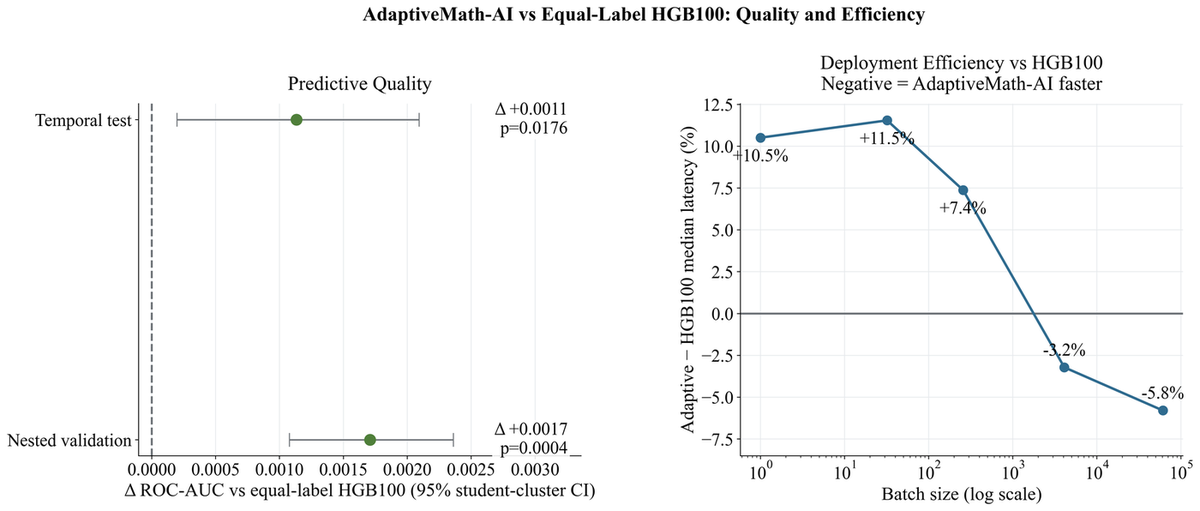

Saved figure: <repository_root>/figures/final_29_efficiency_quality_tradeoff.png


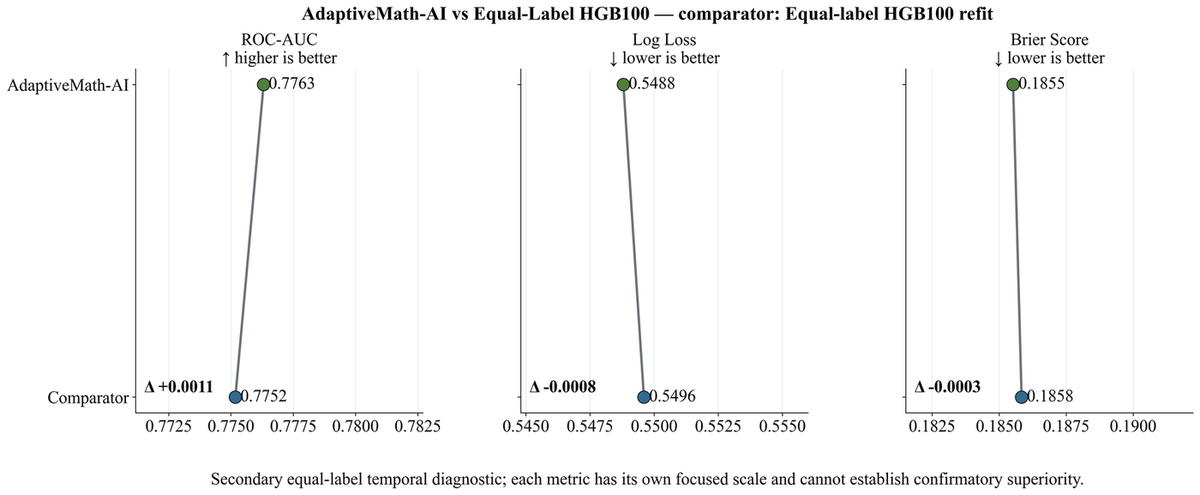

Saved figure: <repository_root>/figures/final_30_adaptivemath_vs_best_baseline.png


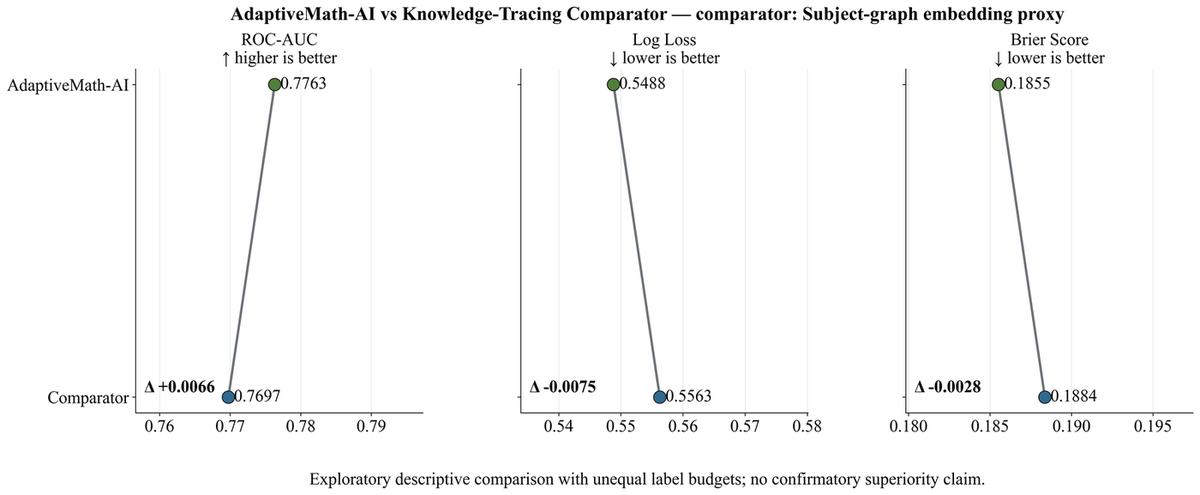

Saved figure: <repository_root>/figures/final_31_adaptivemath_vs_best_knowledge_tracing.png


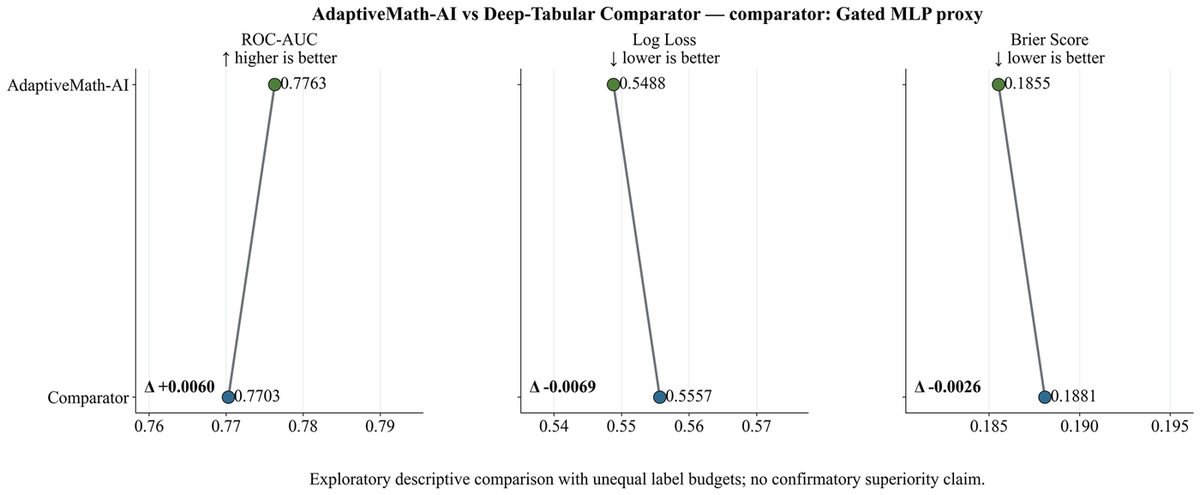

Saved figure: <repository_root>/figures/final_32_adaptivemath_vs_best_deep.png


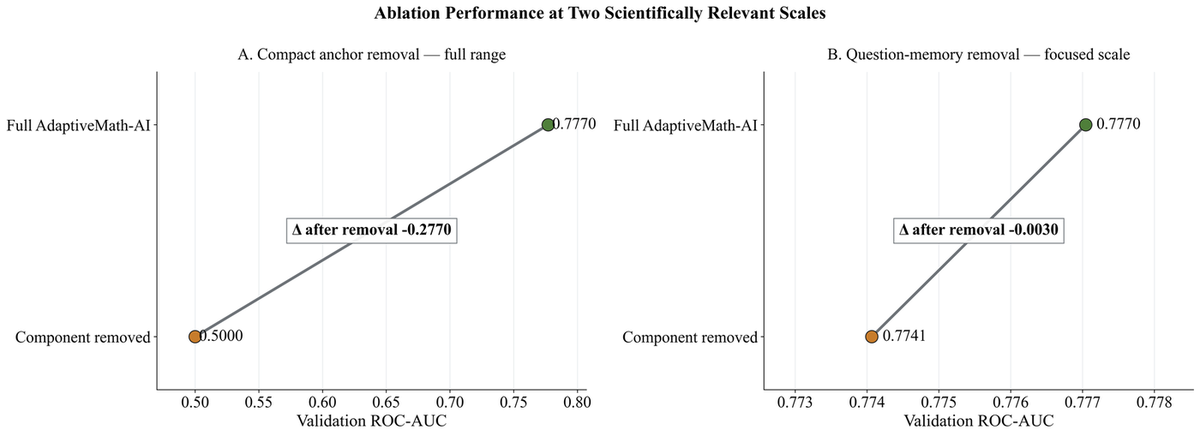

Saved figure: <repository_root>/figures/final_33_ablation_performance.png


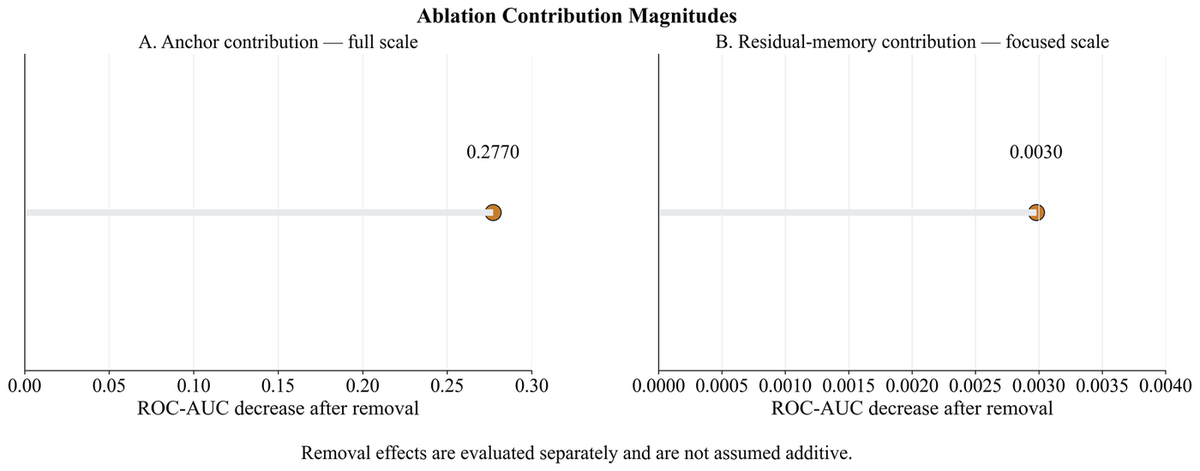

Saved figure: <repository_root>/figures/final_34_component_contribution_summary.png


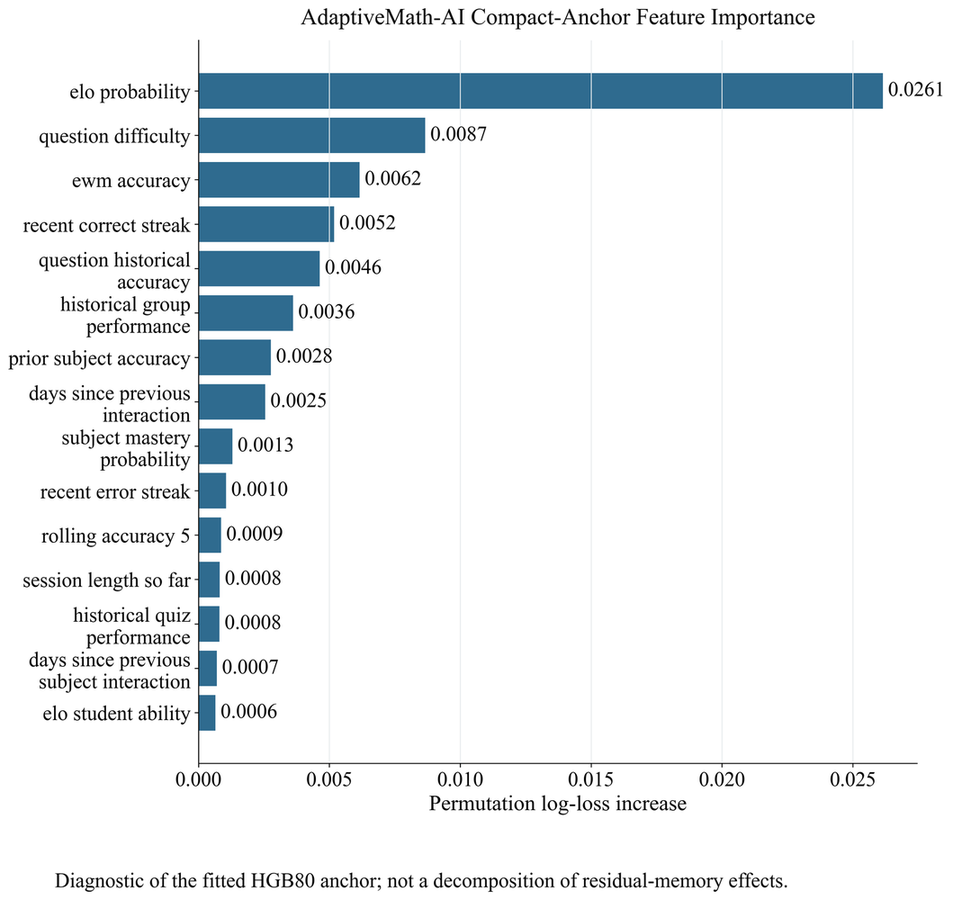

Saved figure: <repository_root>/figures/final_35_feature_importance.png


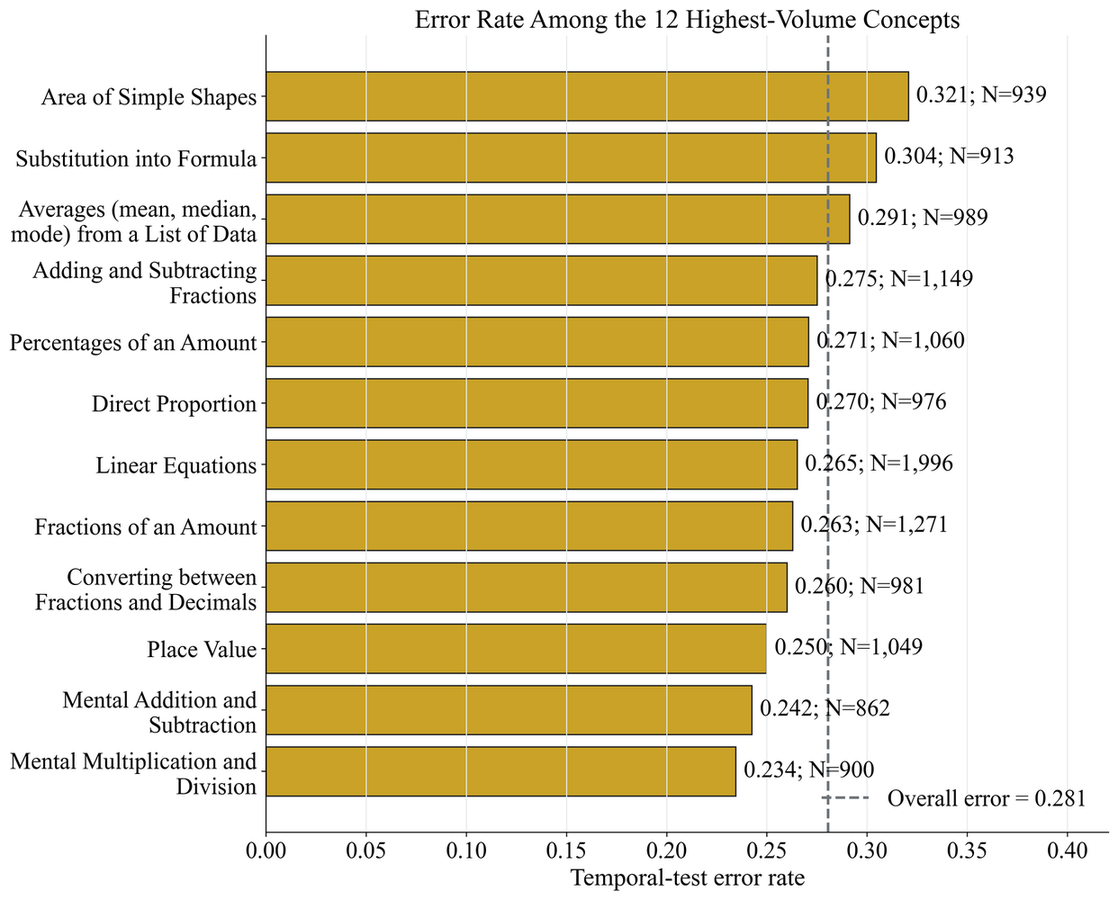

Saved figure: <repository_root>/figures/final_36_concept_importance.png


In [6]:
# 25 Reliability diagram.
def reliability_points(frame,p_column,bins=10,replicates=300):
    y=frame.is_correct.to_numpy(); p=frame[p_column].to_numpy(); ids=np.clip(np.digitize(p,np.linspace(0,1,bins+1))-1,0,bins-1); rows=[]
    for b in range(bins):
        m=ids==b
        if m.any():
            g=frame.loc[m,["user_id","is_correct"]].reset_index(drop=True); users=g.user_id.unique(); idxmap={u:np.flatnonzero(g.user_id.to_numpy()==u) for u in users}; local_rng=np.random.default_rng(SEED+b+len(g)); boot=[]
            for _ in range(replicates):
                idx=np.concatenate([idxmap[u] for u in local_rng.choice(users,size=len(users),replace=True)]); boot.append(g.is_correct.to_numpy()[idx].mean())
            rows.append((b,p[m].mean(),y[m].mean(),int(y[m].sum()),int(m.sum()),np.quantile(boot,.025),np.quantile(boot,.975),len(users)))
    return pd.DataFrame(rows,columns=["Bin","Mean_Prediction","Observed_Frequency","Correct","N","Cluster_CI_Lower","Cluster_CI_Upper","Students"])
fair_pred=pd.read_parquet(TABLES/"fair_label_budget_predictions_test.parquet"); relp=reliability_points(fair_pred,"AdaptiveMath_AI"); relc=reliability_points(fair_pred,"Fair_HGB_Refit"); ece_p=np.average(np.abs(relp.Observed_Frequency-relp.Mean_Prediction),weights=relp.N); ece_c=np.average(np.abs(relc.Observed_Frequency-relc.Mean_Prediction),weights=relc.N)
fig,(ax,axn)=plt.subplots(2,1,figsize=(13,12),gridspec_kw={"height_ratios":[4,1]},sharex=True); ax.plot([0,1],[0,1],"--",color=PALETTE["gray"],linewidth=2,label="Perfect calibration")
for rel,label,color,marker,style in [(relp,f"AdaptiveMath-AI (ECE {ece_p:.3f})",PALETTE["green"],"o","-"),(relc,f"Equal-label HGB100 (ECE {ece_c:.3f})",PALETTE["blue"],"s","--")]:
    yerr=np.vstack([rel.Observed_Frequency-rel.Cluster_CI_Lower,rel.Cluster_CI_Upper-rel.Observed_Frequency]); ax.errorbar(rel.Mean_Prediction,rel.Observed_Frequency,yerr=yerr,fmt=marker+style,color=color,linewidth=2.5,markersize=9,markerfacecolor="white" if marker=="s" else color,capsize=5,label=label)
centers=np.arange(10)/10+.05; width=.038; axn.bar(centers-width/2,relp.set_index("Bin").reindex(range(10)).N.fillna(0),width,color=PALETTE["green"],label="AdaptiveMath-AI"); axn.bar(centers+width/2,relc.set_index("Bin").reindex(range(10)).N.fillna(0),width,color=PALETTE["blue"],fill=False,edgecolor=PALETTE["blue"],linewidth=2,label="Equal-label HGB100")
ax.set_ylabel("Observed correctness frequency"); ax.set_title("Reliability Diagram — Secondary Equal-Label Temporal Diagnostic"); ax.set_xlim(0,1); ax.set_ylim(0,1); ax.grid(color=PALETTE["light_gray"]); ax.legend(loc="upper left",frameon=False,ncol=1); axn.set_xlabel("Mean predicted probability"); axn.set_ylabel("Bin N"); axn.grid(axis="y",color=PALETTE["light_gray"]); fig.text(.5,.01,"95% intervals resample user_id clusters (300 replicates); temporal evidence is non-confirmatory.",ha="center",fontsize=18); fig.subplots_adjust(hspace=.08,bottom=.12); save_and_show_figure(fig,"final_25_reliability_diagram.png"); record(25,"Reliability Diagram — Student-Cluster Temporal Diagnostic","final_25_reliability_diagram.png","fair_label_budget_predictions_test.parquet",annotated=True)
# 26 validation-defined prediction-risk heuristic versus error.
uq=pd.read_csv(TABLES/"uncertainty_quality_summary.csv"); uq=uq[(uq.Split.eq("temporal_test"))&(uq.Analysis.eq("Prediction-risk quintile"))].copy(); fig,ax=plt.subplots(figsize=(11,7)); ax.bar(uq.Level.astype(int).astype(str),uq.Error_Rate,color=PALETTE["red"]); annotate_bars(ax,horizontal=False); ax.set_xlabel("Predictive-entropy risk quintile (low to high)"); ax.set_ylabel("Error rate"); ax.set_title("Prediction-Risk Heuristic vs Error"); ax.grid(axis="y",color=PALETTE["light_gray"]); save_and_show_figure(fig,"final_26_uncertainty_vs_error.png"); record(26,"Prediction-Risk Heuristic vs Error","final_26_uncertainty_vs_error.png","uncertainty_quality_summary.csv")
# 27 risk coverage.
rc=uq=pd.read_csv(TABLES/"uncertainty_quality_summary.csv"); rc=rc[(rc.Split.eq("temporal_test"))&(rc.Analysis.eq("Risk-coverage"))].copy(); fig,ax=plt.subplots(figsize=(12,8)); ax.plot(rc.Coverage,rc.Error_Rate,"o-",color=PALETTE["orange"],linewidth=2.5); [ax.annotate(f"{r.Error_Rate:.3f}",(r.Coverage,r.Error_Rate),xytext=(0,12),textcoords="offset points",ha="center",fontsize=18,clip_on=True) for r in rc.itertuples()]; ax.set_xlabel("Retained coverage"); ax.set_ylabel("Selective error rate"); ax.set_title("Risk–Coverage Curve"); ax.margins(y=.18); ax.grid(color=PALETTE["light_gray"]); save_and_show_figure(fig,"final_27_risk_coverage_curve.png"); record(27,"Risk-Coverage Curve","final_27_risk_coverage_curve.png","uncertainty_quality_summary.csv")
# 28 same-harness end-to-end latency; heterogeneous device/model timing is intentionally excluded.
bench=pd.read_csv(TABLES/"adaptivemath_end_to_end_latency_benchmark.csv").sort_values("Batch_Size"); fig,(ax,axd)=plt.subplots(1,2,figsize=(19,8)); style={"AdaptiveMath-AI":(PALETTE["green"],"o"),"HGB80 anchor":(PALETTE["orange"],"^"),"HGB100 comparator":(PALETTE["blue"],"s")}
for model,g in bench.groupby("Model"):
    color,marker=style[model]; g=g.sort_values("Batch_Size"); ax.plot(g.Batch_Size,g.Median_Latency_Milliseconds,marker=marker,color=color,linewidth=2.5,markersize=9,label=model+" median"); ax.fill_between(g.Batch_Size,g.P25_Latency_Milliseconds,g.P75_Latency_Milliseconds,color=color,alpha=.16); ax.plot(g.Batch_Size,g.P95_Latency_Milliseconds,marker="^",linestyle=":",color=color,linewidth=2,label=model+" p95")
pivot=bench.pivot(index="Batch_Size",columns="Model",values="Median_Latency_Milliseconds"); latency_delta=(pivot["AdaptiveMath-AI"]/pivot["HGB80 anchor"]-1)*100; colors=[PALETTE["orange"] if v>0 else PALETTE["blue"] for v in latency_delta]; bars=axd.bar(np.arange(len(latency_delta)),latency_delta,color=colors,edgecolor=PALETTE["black"]);
for bar,value in zip(bars,latency_delta): axd.text(bar.get_x()+bar.get_width()/2,value+.28 if value>=0 else value+.45,f"{value:+.1f}%",ha="center",va="bottom",fontsize=18)
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlabel("Batch size (log scale)"); ax.set_ylabel("End-to-end latency, ms (log scale)"); ax.set_title("Same-Harness Latency: Median, IQR and p95",pad=14); ax.grid(color=PALETTE["light_gray"]); ax.legend(loc="upper left",frameon=False,ncol=1); axd.axhline(0,color=PALETTE["gray"],linewidth=2); axd.set_ylim(min(-8.5,latency_delta.min()-.8),max(25,latency_delta.max()+2)); axd.set_xticks(np.arange(len(latency_delta)),[f"{int(x):,}" for x in latency_delta.index],rotation=30,ha="right"); axd.set_xlabel("Batch size"); axd.set_ylabel("Residual-memory overhead vs HGB80 (%)"); axd.set_title("Incremental Residual-Layer Cost\nNegative = lower measured latency",pad=14); axd.grid(axis="y",color=PALETTE["light_gray"]); fig.suptitle("End-to-End Inference Efficiency — One CPU Thread, Identical Harness",fontsize=20,fontweight="bold",y=.97); fig.subplots_adjust(top=.80,bottom=.18,wspace=.28); save_and_show_figure(fig,"final_28_latency_throughput_comparison.png"); record(28,"HGB80 / Residual Memory / HGB100 Latency Decomposition","final_28_latency_throughput_comparison.png","adaptivemath_end_to_end_latency_benchmark.csv",annotated=True)
# 29 quality/efficiency trade-off using only fair comparator evidence.
boot=pd.read_csv(TABLES/"proposed_model_cluster_bootstrap.csv"); fair_latency_delta=(pivot["AdaptiveMath-AI"]/pivot["HGB100 comparator"]-1)*100; fig,(axq,axl)=plt.subplots(1,2,figsize=(19,8)); y=np.arange(len(boot)); delta=boot.Delta_ROC_AUC.to_numpy(); lo=delta-boot.AUC_CI_Lower.to_numpy(); hi=boot.AUC_CI_Upper.to_numpy()-delta; axq.errorbar(delta,y,xerr=np.vstack([lo,hi]),fmt="o",color=PALETTE["green"],ecolor=PALETTE["gray"],capsize=7,markersize=11); axq.axvline(0,color=PALETTE["gray"],linestyle="--",linewidth=2); axq.set_yticks(y,["Nested validation","Temporal test"]);
for yi,r in enumerate(boot.itertuples()): axq.text(.97,yi,f"Δ {r.Delta_ROC_AUC:+.4f}\np={r.AUC_Two_Sided_P:.4f}",transform=axq.get_yaxis_transform(),ha="right",va="center",fontsize=18,bbox={"facecolor":"white","edgecolor":"none","alpha":.88,"pad":2})
axq.set_xlim(boot.AUC_CI_Lower.min()-.0003,boot.AUC_CI_Upper.max()+.0010); axq.set_xlabel("Δ ROC-AUC vs equal-label HGB100 (95% student-cluster CI)"); axq.set_title("Predictive Quality",pad=14); axq.grid(axis="x",color=PALETTE["light_gray"]); axl.axhline(0,color=PALETTE["gray"],linewidth=2); axl.plot(fair_latency_delta.index,fair_latency_delta.values,"o-",color=PALETTE["blue"],linewidth=2.5,markersize=9); [axl.annotate(f"{v:+.1f}%",(x,v),xytext=(0,-24 if v>=0 else 12),textcoords="offset points",ha="center",fontsize=18) for x,v in fair_latency_delta.items()]; axl.set_ylim(min(-8.5,fair_latency_delta.min()-.8),max(2.5,fair_latency_delta.max()+1.0)); axl.set_xscale("log"); axl.set_xlabel("Batch size (log scale)"); axl.set_ylabel("Adaptive − HGB100 median latency (%)"); axl.set_title("Deployment Efficiency vs HGB100\nNegative = AdaptiveMath-AI faster",pad=14); axl.grid(color=PALETTE["light_gray"]); fig.suptitle("AdaptiveMath-AI vs Equal-Label HGB100: Quality and Efficiency",fontsize=20,fontweight="bold",y=.97); fig.subplots_adjust(top=.80,bottom=.18,wspace=.36); save_and_show_figure(fig,"final_29_efficiency_quality_tradeoff.png"); record(29,"Fair Quality and Efficiency Trade-off","final_29_efficiency_quality_tradeoff.png","proposed_model_cluster_bootstrap.csv; adaptivemath_end_to_end_latency_benchmark.csv",annotated=True)
# 30–32 paired summaries.
def paired_metric_figure(number,title,proposed_values,comparator_values,comparator,filename,note,evidence):
    metrics=[("ROC-AUC","↑ higher is better"),("Log Loss","↓ lower is better"),("Brier Score","↓ lower is better")]; fig,axes=plt.subplots(1,3,figsize=(20,7))
    for ax,(metric,direction),a,c in zip(axes,metrics,proposed_values,comparator_values):
        values=np.array([a,c]); y=np.array([1,0]); ax.plot(values,y,color=PALETTE["gray"],linewidth=2.5); ax.scatter(values,y,s=170,color=[PALETTE["green"],PALETTE["blue"]],edgecolor=PALETTE["black"],zorder=3); ax.set_yticks(y,["AdaptiveMath-AI","Comparator"] if ax is axes[0] else ["",""]); margin=max(.004,np.ptp(values)*2); ax.set_xlim(values.min()-margin,values.max()+margin*1.6); ax.set_title(metric+"\n"+direction,fontsize=18); ax.grid(axis="x",color=PALETTE["light_gray"]); ax.text(.03,.06,f"Δ {a-c:+.4f}",transform=ax.transAxes,fontsize=18,fontweight="bold"); [ax.text(v+max(np.ptp(values)*.12,.0002),yi,f"{v:.4f}",va="center",fontsize=18) for yi,v in zip(y,values)]
    fig.suptitle(title+f" — comparator: {comparator}",fontsize=20,fontweight="bold",y=1.01); fig.text(.5,.01,note,ha="center",fontsize=18); fig.subplots_adjust(bottom=.16,wspace=.34); save_and_show_figure(fig,filename); record(number,title,filename,evidence,annotated=True)
fair_prop=np.array([fair_temporal.AdaptiveMath_AI_ROC_AUC,fair_temporal.Log_Loss+boot_temporal.Delta_Log_Loss,fair_temporal.Brier_Score+boot_temporal.Delta_Brier]); fair_hgb=np.array([fair_temporal.ROC_AUC,fair_temporal.Log_Loss,fair_temporal.Brier_Score]); paired_metric_figure(30,"AdaptiveMath-AI vs Equal-Label HGB100",fair_prop,fair_hgb,"Equal-label HGB100 refit","final_30_adaptivemath_vs_best_baseline.png","Secondary equal-label temporal diagnostic; each metric has its own focused scale and cannot establish confirmatory superiority.","fair_label_budget_comparison.csv; proposed_model_cluster_bootstrap.csv")
for number,title,comparator,filename in [(31,"AdaptiveMath-AI vs Knowledge-Tracing Comparator",best_kt,"final_31_adaptivemath_vs_best_knowledge_tracing.png"),(32,"AdaptiveMath-AI vs Deep-Tabular Comparator",best_deep,"final_32_adaptivemath_vs_best_deep.png")]:
    dd=final_test[final_test.Model.isin(["AdaptiveMath-AI",comparator])].set_index("Model"); paired_metric_figure(number,title,dd.loc["AdaptiveMath-AI",["ROC_AUC","Log_Loss","Brier_Score"]].to_numpy(float),dd.loc[comparator,["ROC_AUC","Log_Loss","Brier_Score"]].to_numpy(float),comparator,filename,"Exploratory descriptive comparison with unequal label budgets; no confirmatory superiority claim.","final_temporal_test_primary_metrics.csv")
# 33 ablation performance.
av=pd.read_csv(TABLES/"ablation_results_validation.csv"); full=av[av.component_removed.str.contains("Full")].iloc[0]; anchor=av[av.component_removed.str.contains("Anchor")].iloc[0]; memory=av[av.component_removed.str.contains("Question Residual")].iloc[0]; fig,axes=plt.subplots(1,2,figsize=(19,7))
for ax,row,panel,xpad in [(axes[0],anchor,"A. Compact anchor removal — full range",.03),(axes[1],memory,"B. Question-memory removal — focused scale",.0015)]:
    values=np.array([full.ROC_AUC,row.ROC_AUC]); y=np.array([1,0]); ax.plot(values,y,color=PALETTE["gray"],linewidth=3); ax.scatter(values,y,s=190,color=[PALETTE["green"],PALETTE["orange"]],edgecolor=PALETTE["black"],zorder=3); ax.set_yticks(y,["Full AdaptiveMath-AI","Component removed"]); ax.set_xlim(values.min()-xpad,values.max()+xpad); ax.set_ylim(-.25,1.25); ax.set_title(panel,fontsize=18,pad=14); ax.set_xlabel("Validation ROC-AUC"); ax.grid(axis="x",color=PALETTE["light_gray"]); [ax.text(v+xpad*.10,yi,f"{v:.4f}",va="center",fontsize=18) for yi,v in zip(y,values)]; ax.text(.50,.50,f"Δ after removal {row.ROC_AUC-full.ROC_AUC:+.4f}",transform=ax.transAxes,fontsize=18,fontweight="bold",ha="center",va="center",bbox={"facecolor":"white","edgecolor":PALETTE["gray"],"alpha":.92,"pad":6})
fig.suptitle("Ablation Performance at Two Scientifically Relevant Scales",fontsize=20,fontweight="bold"); fig.tight_layout(); save_and_show_figure(fig,"final_33_ablation_performance.png"); record(33,"Ablation Performance at Two Scales","final_33_ablation_performance.png","ablation_results_validation.csv",annotated=True)
# 34 component contributions.
cc=pd.read_csv(TABLES/"ablation_component_contribution_summary.csv"); cc=cc[~cc.component_removed.str.contains("Full")].copy(); cc["ROC_AUC_Decrease"]=-cc.validation_ROC_AUC_change; anchor_c=cc[cc.component_removed.str.contains("Anchor")].iloc[0]; memory_c=cc[cc.component_removed.str.contains("Question Residual")].iloc[0]; fig,axes=plt.subplots(1,2,figsize=(19,6))
for ax,row,panel,xmax in [(axes[0],anchor_c,"A. Anchor contribution — full scale",.30),(axes[1],memory_c,"B. Residual-memory contribution — focused scale",.004)]: ax.hlines(0,0,row.ROC_AUC_Decrease,color=PALETTE["light_gray"],linewidth=6); ax.scatter(row.ROC_AUC_Decrease,0,s=220,color=PALETTE["orange"],edgecolor=PALETTE["black"]); ax.text(row.ROC_AUC_Decrease,0.12,f"{row.ROC_AUC_Decrease:.4f}",ha="center",fontsize=18); ax.set_xlim(0,xmax); ax.set_ylim(-.35,.35); ax.set_yticks([]); ax.set_title(panel,fontsize=18); ax.set_xlabel("ROC-AUC decrease after removal"); ax.grid(axis="x",color=PALETTE["light_gray"])
fig.suptitle("Ablation Contribution Magnitudes",fontsize=20,fontweight="bold"); fig.text(.5,.01,"Removal effects are evaluated separately and are not assumed additive.",ha="center",fontsize=18); fig.subplots_adjust(bottom=.20,wspace=.25); save_and_show_figure(fig,"final_34_component_contribution_summary.png"); record(34,"Ablation Contribution Magnitudes","final_34_component_contribution_summary.png","ablation_component_contribution_summary.csv",annotated=True)
# 35 feature importance.
fi=importance.head(15).sort_values("Permutation_Log_Loss_Increase"); fig,ax=plt.subplots(figsize=(15,12)); ax.barh(wrap_labels(fi.Feature,26),fi.Permutation_Log_Loss_Increase,color=PALETTE["blue"]); annotate_bars(ax,fmt="{:.4f}"); ax.set_xlabel("Permutation log-loss increase"); ax.set_title("AdaptiveMath-AI Compact-Anchor Feature Importance",pad=14); ax.grid(axis="x",color=PALETTE["light_gray"]); fig.text(.5,.025,"Diagnostic of the fitted HGB80 anchor; not a decomposition of residual-memory effects.",ha="center",fontsize=18); fig.subplots_adjust(left=.32,bottom=.15); save_and_show_figure(fig,"final_35_feature_importance.png"); record(35,"Compact-Anchor Feature Importance","final_35_feature_importance.png","permutation_importance.csv; adaptivemath_ai.joblib")
# 36 concept importance.
ci=concept.nlargest(12,"N").sort_values("Error_Rate"); overall_error=prop_test.error.mean(); fig,ax=plt.subplots(figsize=(16,11)); bars=ax.barh(wrap_labels(ci.Subject,26),ci.Error_Rate,color=PALETTE["gold"],edgecolor=PALETTE["black"]); ax.axvline(overall_error,color=PALETTE["gray"],linestyle="--",linewidth=2,label=f"Overall error = {overall_error:.3f}");
for bar,row in zip(bars,ci.itertuples()): ax.text(row.Error_Rate+.004,bar.get_y()+bar.get_height()/2,f"{row.Error_Rate:.3f}; N={row.N:,}",va="center",fontsize=18)
ax.set_xlim(0,ci.Error_Rate.max()+.10); ax.set_xlabel("Temporal-test error rate"); ax.set_title("Error Rate Among the 12 Highest-Volume Concepts"); ax.grid(axis="x",color=PALETTE["light_gray"]); ax.legend(loc="lower right",frameon=False); fig.subplots_adjust(left=.34); save_and_show_figure(fig,"final_36_concept_importance.png"); record(36,"High-Volume Concept Error Profile","final_36_concept_importance.png","concept_importance_summary.csv",annotated=True)

## Final figures 37–44: attention comparator, subgroups, robustness, statistical uncertainty, errors, and decisions

The remaining figures show neural-comparator attention, student-cluster intervals, robustness, paired uncertainty, confusion patterns and offline decision categories.

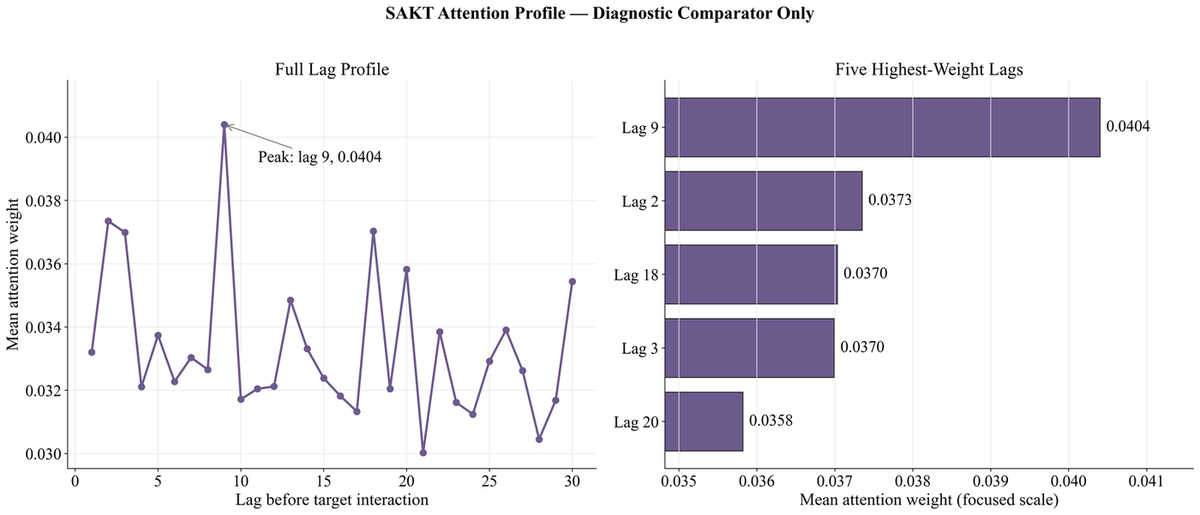

Saved figure: <repository_root>/figures/final_37_attention_analysis.png


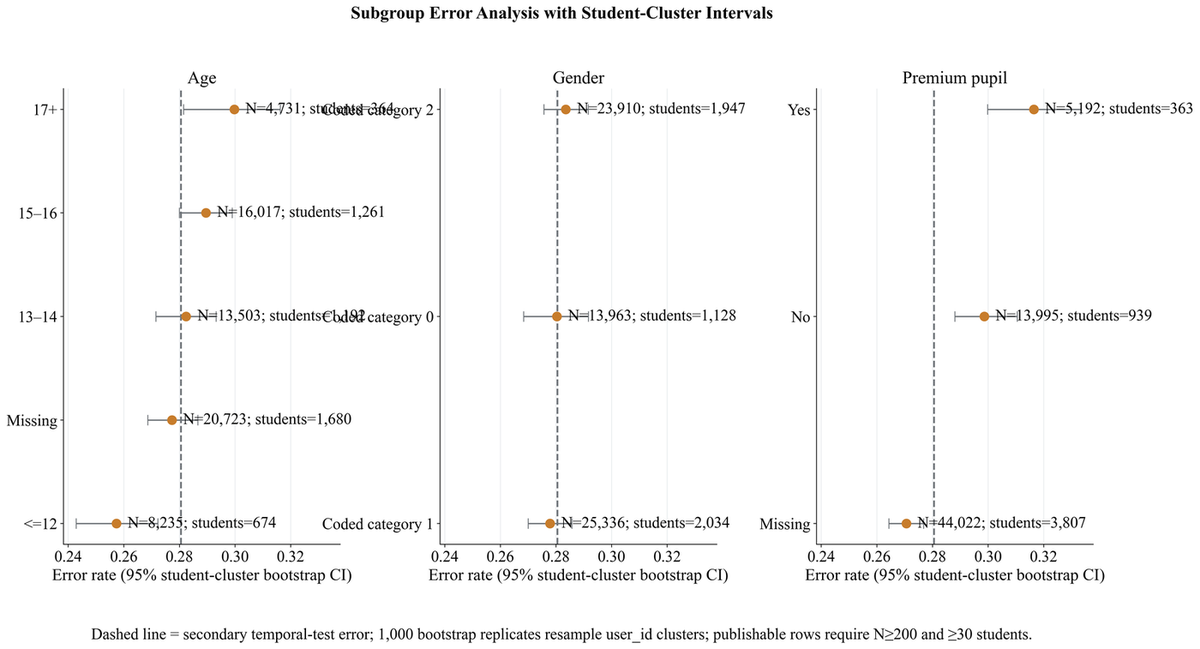

Saved figure: <repository_root>/figures/final_38_subgroup_error_analysis.png


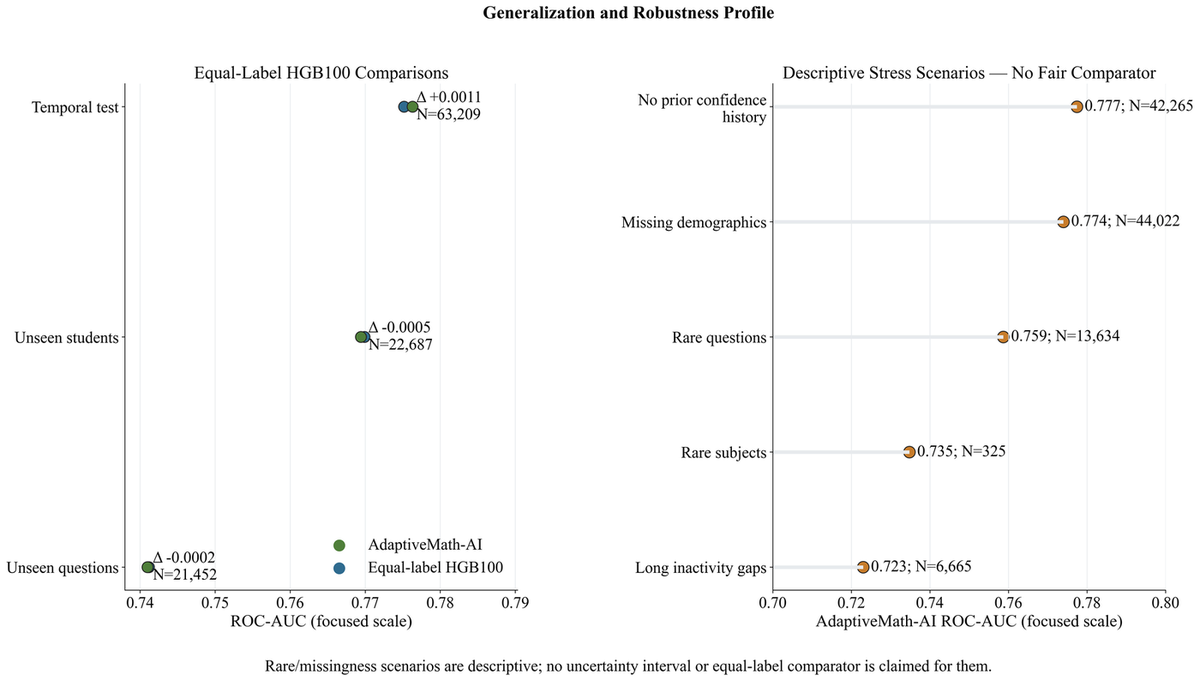

Saved figure: <repository_root>/figures/final_39_robustness_analysis.png


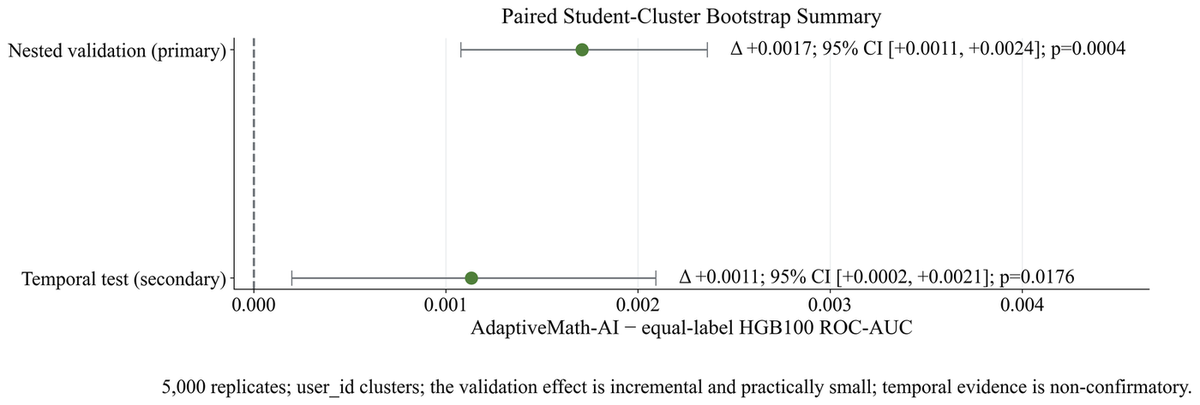

Saved figure: <repository_root>/figures/final_40_statistical_test_summary.png


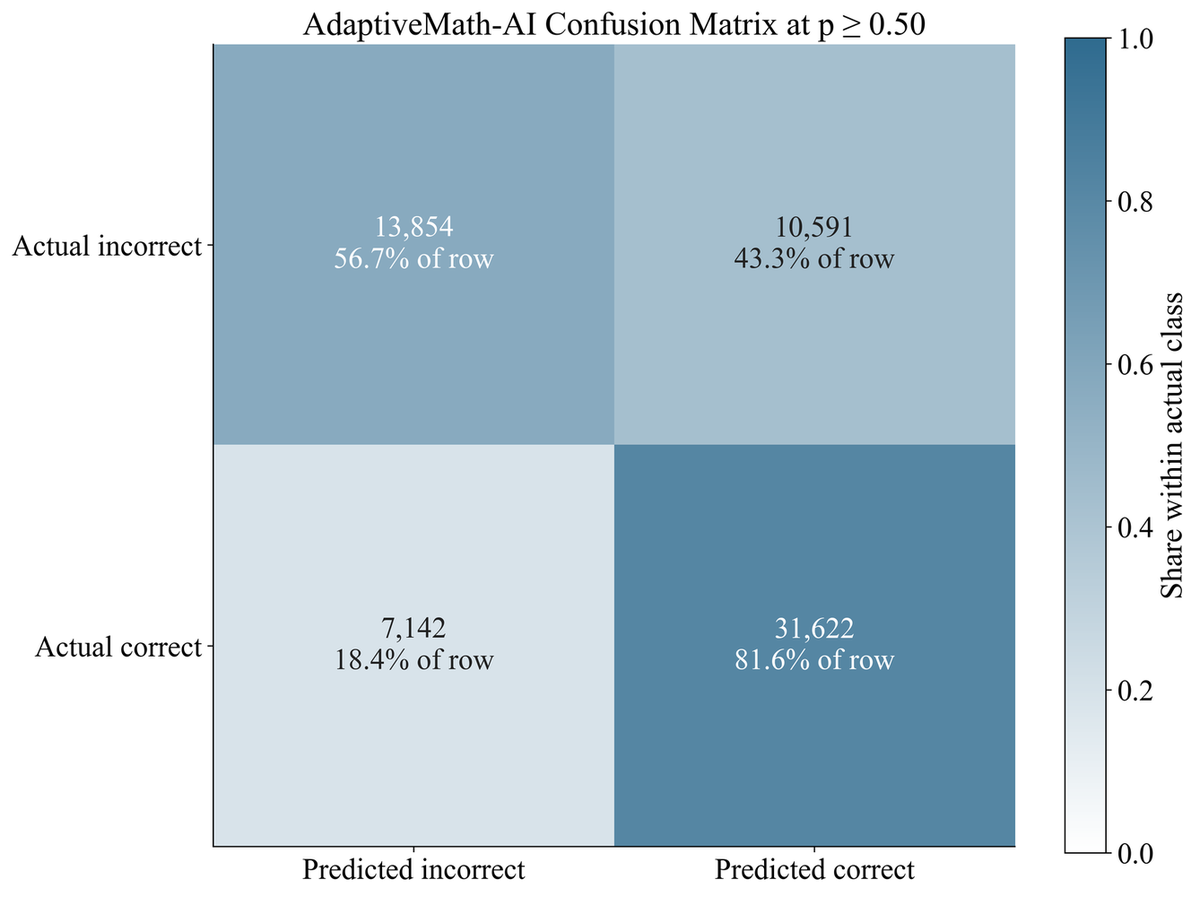

Saved figure: <repository_root>/figures/final_41_confusion_matrix.png


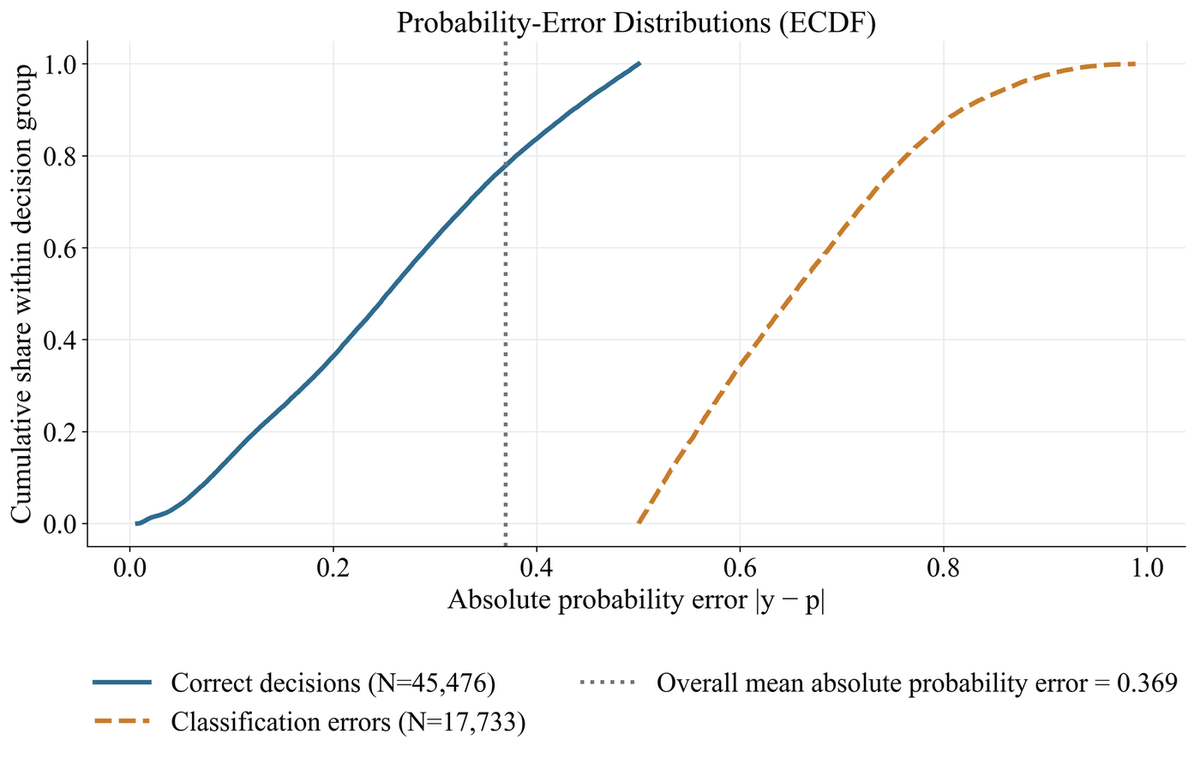

Saved figure: <repository_root>/figures/final_42_error_distribution.png


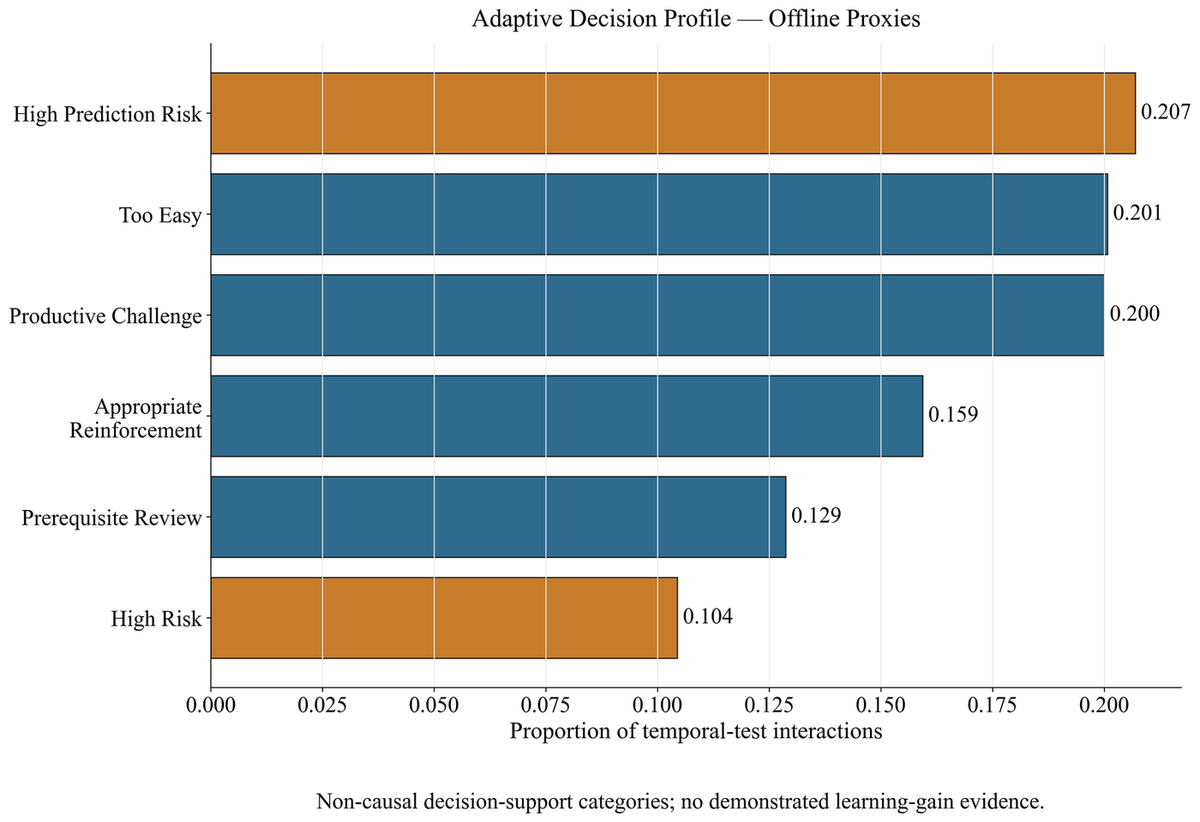

Saved figure: <repository_root>/figures/final_43_adaptive_decision_profile.png


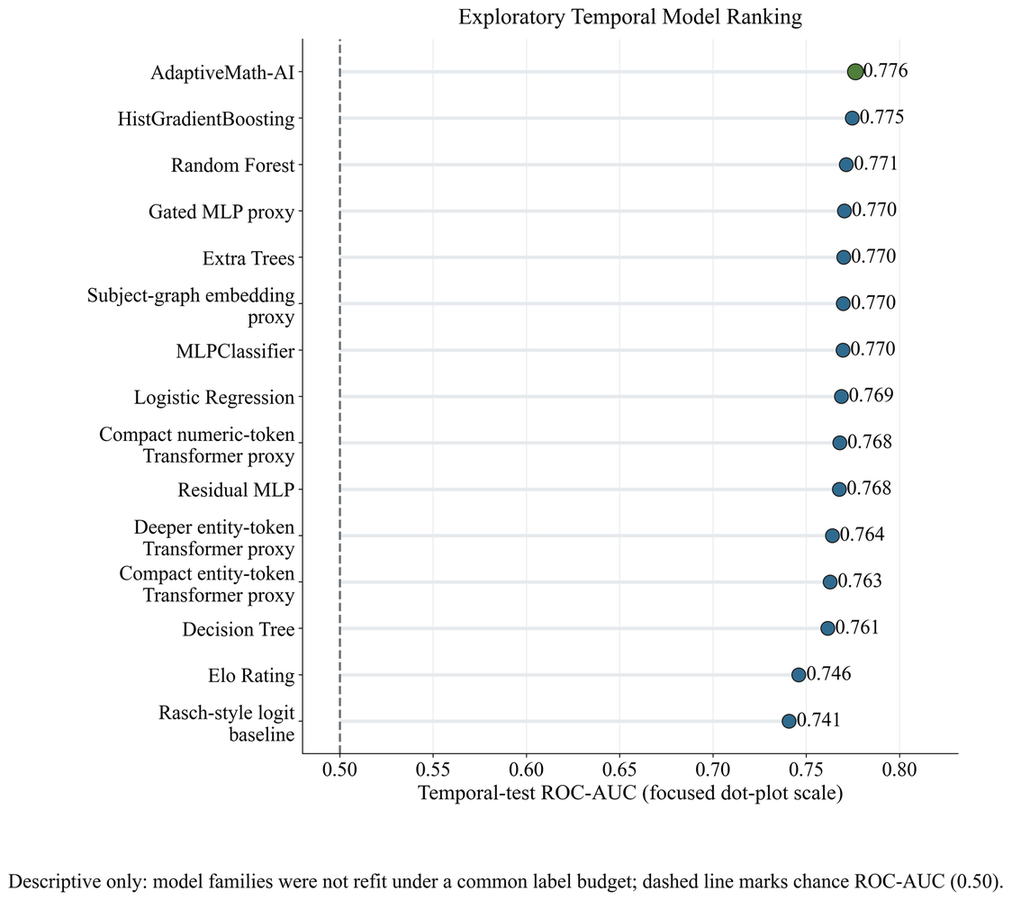

Saved figure: <repository_root>/figures/final_44_final_model_ranking.png


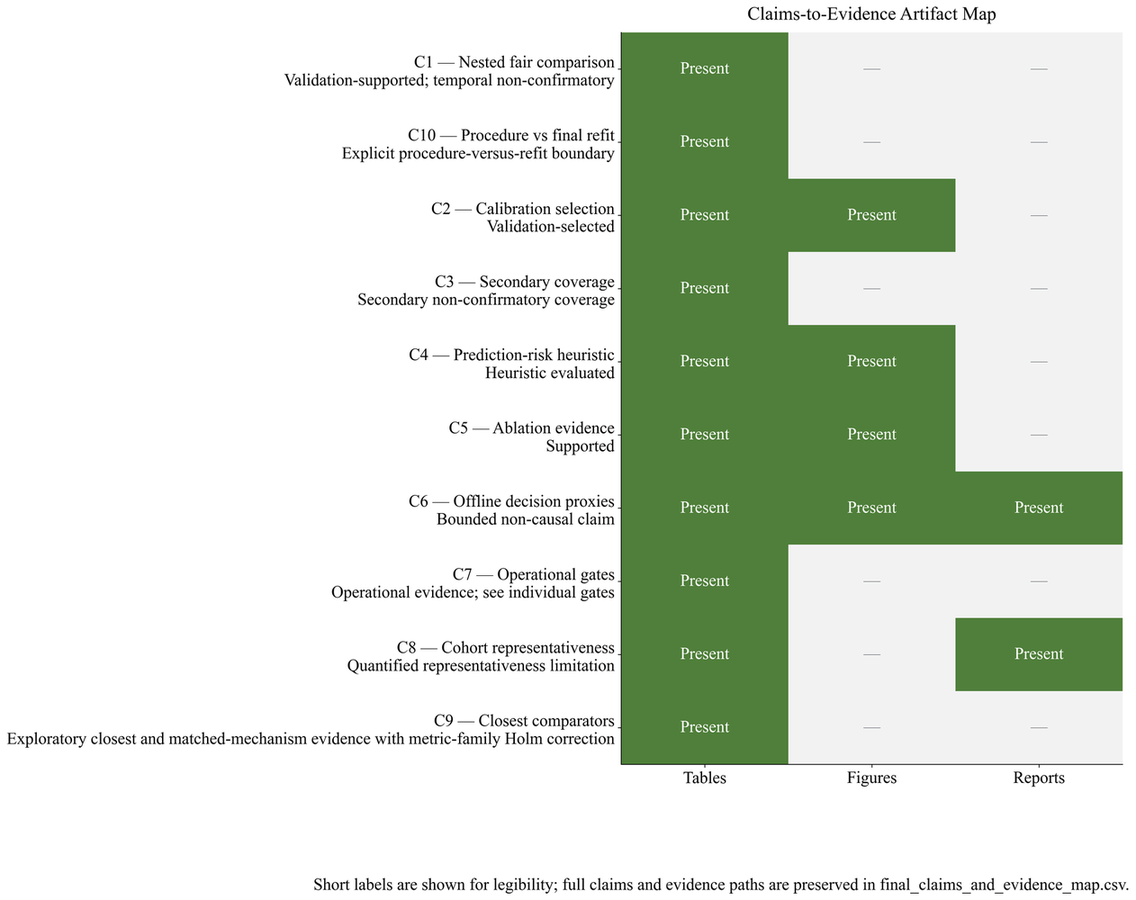

In [7]:
# 37 attention analysis belongs to the SAKT comparator, not AdaptiveMath-AI.
a=attention.sort_values("Lag"); top=a.nlargest(5,"Mean_Attention_Weight").sort_values("Mean_Attention_Weight"); fig,(ax,axb)=plt.subplots(1,2,figsize=(19,8)); ax.plot(a.Lag,a.Mean_Attention_Weight,"o-",color=PALETTE["purple"],linewidth=2.5,markersize=7); peak=a.loc[a.Mean_Attention_Weight.idxmax()]; ax.annotate(f"Peak: lag {int(peak.Lag)}, {peak.Mean_Attention_Weight:.4f}",(peak.Lag,peak.Mean_Attention_Weight),xytext=(38,-42),textcoords="offset points",fontsize=18,arrowprops={"arrowstyle":"->","color":PALETTE["gray"]},clip_on=True); ax.set_ylim(a.Mean_Attention_Weight.min()-.0005,a.Mean_Attention_Weight.max()+.0014); ax.set_xlabel("Lag before target interaction"); ax.set_ylabel("Mean attention weight"); ax.set_title("Full Lag Profile"); ax.grid(color=PALETTE["light_gray"]); bars=axb.barh([f"Lag {int(v)}" for v in top.Lag],top.Mean_Attention_Weight,color=PALETTE["purple"],edgecolor=PALETTE["black"]); [axb.text(v+.00008,b.get_y()+b.get_height()/2,f"{v:.4f}",va="center",fontsize=18) for b,v in zip(bars,top.Mean_Attention_Weight)]; axb.set_xlim(top.Mean_Attention_Weight.min()-.001,top.Mean_Attention_Weight.max()+.0012); axb.set_xlabel("Mean attention weight (focused scale)"); axb.set_title("Five Highest-Weight Lags"); axb.grid(axis="x",color=PALETTE["light_gray"]); fig.suptitle("SAKT Attention Profile — Diagnostic Comparator Only",fontsize=20,fontweight="bold",y=1.01); fig.tight_layout(); save_and_show_figure(fig,"final_37_attention_analysis.png"); record(37,"SAKT Attention Diagnostic Comparator","final_37_attention_analysis.png","sota_attention_diagnostics.csv",annotated=True)
# 38 subgroup error.
sg=subgroups[subgroups.Dimension.isin(["Age","Gender","Premium pupil"])].copy(); fig,axes=plt.subplots(1,3,figsize=(21,10),sharex=True)
for ax,dimension in zip(axes,["Age","Gender","Premium pupil"]):
    g=sg[sg.Dimension.eq(dimension)].copy();
    def readable_level(value):
        s=str(value);
        if s.lower()=="nan": return "Missing"
        if dimension=="Premium pupil": return {"0.0":"No","1.0":"Yes"}.get(s,s)
        if dimension=="Gender" and s.replace(".","",1).isdigit(): return f"Coded category {s}"
        return s
    g["Label"]=g.Subgroup.map(readable_level); g=g.sort_values("Error_Rate"); yloc=np.arange(len(g)); xerr=np.vstack([g.Error_Rate.to_numpy()-g.Error_Rate_Cluster_CI_Lower.to_numpy(),g.Error_Rate_Cluster_CI_Upper.to_numpy()-g.Error_Rate.to_numpy()]); ax.errorbar(g.Error_Rate,yloc,xerr=xerr,fmt="o",color=PALETTE["orange"],ecolor=PALETTE["gray"],capsize=6,markersize=10); ax.axvline(overall_error,color=PALETTE["gray"],linestyle="--",linewidth=2); ax.set_yticks(yloc,wrap_labels(g.Label,18)); ax.set_title(dimension,fontsize=20); ax.set_xlabel("Error rate (95% student-cluster bootstrap CI)"); ax.grid(axis="x",color=PALETTE["light_gray"]); [ax.text(r.Error_Rate+.004,i,f"N={int(r.N):,}; students={int(r.Students):,}",va="center",fontsize=18) for i,r in enumerate(g.itertuples())]
fig.suptitle("Subgroup Error Analysis with Student-Cluster Intervals",fontsize=20,fontweight="bold",y=1.01); fig.text(.5,.01,"Dashed line = secondary temporal-test error; 1,000 bootstrap replicates resample user_id clusters; rows shown require N≥200 and ≥30 students.",ha="center",fontsize=18); fig.subplots_adjust(bottom=.16,wspace=.36); save_and_show_figure(fig,"final_38_subgroup_error_analysis.png"); record(38,"Subgroup Error Analysis with Student-Cluster Intervals","final_38_subgroup_error_analysis.png","subgroup_metrics.csv",annotated=True)
# 39 fair generalization comparisons plus descriptive AdaptiveMath-AI-only stress scenarios.
fig,(axf,axs)=plt.subplots(1,2,figsize=(21,11)); fair_plot=fair.sort_values("ROC_AUC"); yloc=np.arange(len(fair_plot)); split_labels={"temporal_test":"Temporal test","external_unseen_student":"Unseen students","external_unseen_question":"Unseen questions"}
for i,r in enumerate(fair_plot.itertuples()): axf.plot([r.ROC_AUC,r.AdaptiveMath_AI_ROC_AUC],[i,i],color=PALETTE["gray"],linewidth=3); axf.scatter([r.ROC_AUC,r.AdaptiveMath_AI_ROC_AUC],[i,i],s=150,color=[PALETTE["blue"],PALETTE["green"]],edgecolor=PALETTE["black"],zorder=3); axf.text(max(r.ROC_AUC,r.AdaptiveMath_AI_ROC_AUC)+.0005,i,f"Δ {r.Delta_ROC_AUC_AdaptiveMinusFairHGB:+.4f}\nN={int(r.N):,}",va="center",fontsize=18)
axf.set_yticks(yloc,[split_labels[s] for s in fair_plot.Split]); axf.set_xlim(fair_plot[["ROC_AUC","AdaptiveMath_AI_ROC_AUC"]].min().min()-.003,fair_plot[["ROC_AUC","AdaptiveMath_AI_ROC_AUC"]].max().max()+.014); axf.set_xlabel("ROC-AUC (focused scale)"); axf.set_title("Equal-Label HGB100 Comparisons"); axf.grid(axis="x",color=PALETTE["light_gray"]); axf.scatter([],[],s=150,color=PALETTE["green"],label="AdaptiveMath-AI"); axf.scatter([],[],s=150,color=PALETTE["blue"],label="Equal-label HGB100"); axf.legend(loc="lower right",frameon=False)
stress_names=["Rare questions","Rare subjects","Long inactivity gaps","No prior confidence history","Missing demographics"]; stress=robust[(robust.Model.eq("AdaptiveMath-AI"))&robust.Scenario.isin(stress_names)].sort_values("ROC_AUC"); ys=np.arange(len(stress)); axs.hlines(ys,.70,stress.ROC_AUC,color=PALETTE["light_gray"],linewidth=4); axs.scatter(stress.ROC_AUC,ys,s=170,color=PALETTE["orange"],edgecolor=PALETTE["black"]); axs.set_yticks(ys,wrap_labels(stress.Scenario,20)); axs.set_xlim(.70,.80); axs.set_xlabel("AdaptiveMath-AI ROC-AUC (focused scale)"); axs.set_title("Descriptive Stress Scenarios — No Fair Comparator"); axs.grid(axis="x",color=PALETTE["light_gray"]); [axs.text(r.ROC_AUC+.002,i,f"{r.ROC_AUC:.3f}; N={int(r.N):,}",va="center",fontsize=18) for i,r in enumerate(stress.itertuples())]
fig.suptitle("Generalization and Robustness Profile",fontsize=20,fontweight="bold",y=.97); fig.text(.5,.025,"Rare/missingness scenarios are descriptive; no uncertainty interval or equal-label comparator is claimed for them.",ha="center",fontsize=18); fig.subplots_adjust(top=.86,bottom=.14,wspace=.65); save_and_show_figure(fig,"final_39_robustness_analysis.png"); record(39,"Generalization and Robustness Profile","final_39_robustness_analysis.png","fair_label_budget_comparison.csv; robustness_summary.csv",annotated=True)
# 40 statistical test summary.
st=pd.read_csv(TABLES/"proposed_model_cluster_bootstrap.csv").sort_values("Delta_ROC_AUC"); yloc=np.arange(len(st)); lo=st.Delta_ROC_AUC-st.AUC_CI_Lower; hi=st.AUC_CI_Upper-st.Delta_ROC_AUC; fig,ax=plt.subplots(figsize=(15,5.6)); ax.errorbar(st.Delta_ROC_AUC,yloc,xerr=np.vstack([lo,hi]),fmt="o",color=PALETTE["green"],ecolor=PALETTE["gray"],capsize=7,markersize=11); ax.axvline(0,color=PALETTE["gray"],linestyle="--",linewidth=2)
for i,r in enumerate(st.itertuples()): ax.text(r.AUC_CI_Upper+.00012,i,f"Δ {r.Delta_ROC_AUC:+.4f}; 95% CI [{r.AUC_CI_Lower:+.4f}, {r.AUC_CI_Upper:+.4f}]; p={r.AUC_Two_Sided_P:.4f}",va="center",fontsize=18)
ax.set_yticks(yloc,["Nested validation (primary)" if s=="validation" else "Temporal test (secondary)" for s in st.Split]); ax.set_xlabel("AdaptiveMath-AI − equal-label HGB100 ROC-AUC"); ax.set_title("Paired Student-Cluster Bootstrap Summary",pad=14); ax.grid(axis="x",color=PALETTE["light_gray"]); ax.set_xlim(st.AUC_CI_Lower.min()-.0003,st.AUC_CI_Upper.max()+.0023); fig.text(.5,.035,"5,000 replicates; user_id clusters; the validation effect is incremental and practically small; temporal evidence is non-confirmatory.",ha="center",fontsize=18); fig.subplots_adjust(bottom=.27,top=.84); save_and_show_figure(fig,"final_40_statistical_test_summary.png"); record(40,"Authoritative Cluster-Bootstrap Summary","final_40_statistical_test_summary.png","proposed_model_cluster_bootstrap.csv",annotated=True)
# 41 row-normalized confusion matrix with raw counts.
pt=prediction_for("temporal_test","AdaptiveMath-AI"); y=pt.is_correct.to_numpy(); pred=(pt.p.to_numpy()>=.5).astype(int); cm=confusion_matrix(y,pred); cm_share=cm/cm.sum(axis=1,keepdims=True); fig,ax=plt.subplots(figsize=(11,9)); im=ax.imshow(cm_share,vmin=0,vmax=1,cmap=mpl.colors.LinearSegmentedColormap.from_list("cm",[PALETTE["white"],PALETTE["blue"]])); ax.set_xticks([0,1],["Predicted incorrect","Predicted correct"]); ax.set_yticks([0,1],["Actual incorrect","Actual correct"]);
for i in range(2):
    for j in range(2): ax.text(j,i,f"{cm[i,j]:,}\n{cm_share[i,j]:.1%} of row",ha="center",va="center",fontsize=18,color=PALETTE["white"] if cm_share[i,j]>.55 else PALETTE["black"])
cb=fig.colorbar(im,ax=ax); cb.set_label("Share within actual class",fontsize=19); cb.ax.tick_params(labelsize=18); ax.set_title("AdaptiveMath-AI Confusion Matrix at p ≥ 0.50"); save_and_show_figure(fig,"final_41_confusion_matrix.png"); record(41,"Row-Normalized Confusion Matrix","final_41_confusion_matrix.png","proposed_model_predictions_test.parquet",annotated=True)
# 42 error distribution.
abs_error=np.abs(y-pt.p.to_numpy()); correct=pred==y; fig,ax=plt.subplots(figsize=(13,8))
for values,label,color,style in [(abs_error[correct],f"Correct decisions (N={correct.sum():,})",PALETTE["blue"],"-"),(abs_error[~correct],f"Classification errors (N={(~correct).sum():,})",PALETTE["orange"],"--")]: sorted_values=np.sort(values); ecdf=np.arange(1,len(values)+1)/len(values); ax.plot(sorted_values,ecdf,linestyle=style,color=color,linewidth=3,label=label)
ax.axvline(abs_error.mean(),color=PALETTE["gray"],linestyle=":",linewidth=2.5,label=f"Overall mean absolute probability error = {abs_error.mean():.3f}"); ax.set_xlabel("Absolute probability error |y − p|"); ax.set_ylabel("Cumulative share within decision group"); ax.set_title("Probability-Error Distributions (ECDF)"); ax.grid(color=PALETTE["light_gray"]); ax.legend(loc="upper center",bbox_to_anchor=(.5,-.20),frameon=False,ncol=2); fig.subplots_adjust(bottom=.30); save_and_show_figure(fig,"final_42_error_distribution.png"); record(42,"Probability-Error ECDF","final_42_error_distribution.png","proposed_model_predictions_test.parquet",annotated=True)
# 43 adaptive decision profile.
ad=pd.read_csv(TABLES/"adaptive_decision_summary.csv"); ad=ad[ad.split_id.eq("temporal_test")].groupby("Risk_Category",as_index=False).N.sum(); ad["Proportion"]=ad.N/ad.N.sum(); ad=ad.sort_values("Proportion"); fig,ax=plt.subplots(figsize=(14,10)); colors=[PALETTE["orange"] if "Risk" in c or "Uncertainty" in c else PALETTE["blue"] for c in ad.Risk_Category]; ax.barh(wrap_labels(ad.Risk_Category),ad.Proportion,color=colors,edgecolor=PALETTE["black"]); annotate_bars(ax); ax.set_xlabel("Proportion of temporal-test interactions"); ax.set_title("Adaptive Decision Profile — Offline Proxies",pad=14); ax.grid(axis="x",color=PALETTE["light_gray"]); fig.text(.5,.025,"Non-causal decision-support categories; no demonstrated learning-gain evidence.",ha="center",fontsize=18); fig.subplots_adjust(bottom=.16); save_and_show_figure(fig,"final_43_adaptive_decision_profile.png"); record(43,"Adaptive Decision Profile — Offline Non-Causal Proxies","final_43_adaptive_decision_profile.png","adaptive_decision_summary.csv; adaptive_decision_support_description.md",annotated=True)
# 44 final ranking.
fr=final_test.head(15).sort_values("ROC_AUC"); fig,ax=plot_horizontal_metric_ranking(fr,"Model","ROC_AUC",PALETTE["blue"],"Exploratory Temporal Model Ranking","Temporal-test ROC-AUC"); adaptive_y=fr.Model.tolist().index("AdaptiveMath-AI"); adaptive_auc=fr.set_index("Model").loc["AdaptiveMath-AI","ROC_AUC"]; ax.scatter([adaptive_auc],[adaptive_y],s=200,color=PALETTE["green"],edgecolor=PALETTE["black"],zorder=5); ax.set_title("Exploratory Temporal Model Ranking",pad=14); [txt.remove() for txt in list(fig.texts) if "chance ROC-AUC" in txt.get_text()]; fig.text(.5,.025,"Descriptive only: model families were not refit under a common label budget; dashed line marks chance ROC-AUC (0.50).",ha="center",fontsize=18); fig.subplots_adjust(bottom=.16); save_and_show_figure(fig,"final_44_final_model_ranking.png"); record(44,"Exploratory Temporal Ranking","final_44_final_model_ranking.png","final_temporal_test_primary_metrics.csv",annotated=True)